# ЛЦТ 2026. Итоговая подготовка данных и EDA

Мы проверяем журналы 2019-2026 годов, создаём признаки из прошлого и готовим таблицы для первых моделей.
Одна строка журнала означает сообщение канала. Одна строка для ML означает канал в момент ежедневного прогноза.

**Рабочий таргет:** новое зарегистрированное начало «Неисправен» в интервале от +24 до +48 часов.
Это сигнал контролируемого оборудования, а не подтверждённый актом физический отказ датчика.

Pandas используется для понятных таблиц и графиков. DuckDB и Polars обрабатывают полную историю без загрузки всех событий в память.

## Порядок запуска

1. Положим ноутбук в папку с `ext-journal-2019.csv` ... `ext-journal-2026.csv` и тремя справочниками CSV.
2. При наличии сохраним рядом `processed` и `data_handoff` от предыдущего расчёта. Это ускорит запуск, но не является обязательным.
3. Выполним **Restart Kernel and Run All**. Для другой папки изменим `DATA_DIR` ниже.
4. После выполнения передаём команде `data_handoff/ml_ready`, `feature_list.json`, `feature_dictionary.csv`, `README_DATA.md` и этот ноутбук.

Данные до июня 2026 года не дополняем августовским демонстрационным CSV.
Весь расчёт может занимать продолжительное время; нужны десятки гигабайт свободного места для источников, результата и временных файлов.
Результат предназначен для исследования модели. Семантика физического отказа и фактическое выполнение обслуживания остаются неподтверждёнными.

При необходимости один раз установим зависимости в окружение Jupyter. Установка не выполняется автоматически при Run All.

In [ ]:
# %pip install -r requirements.txt

In [1]:
from pathlib import Path
import os, sys, json, hashlib, platform, gc, time
from datetime import datetime, timedelta, date, timezone
os.environ.setdefault('POLARS_MAX_THREADS', '4')
import polars as pl
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import duckdb
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
DATA_DIR = Path(os.environ.get('LCT_DATA_DIR', '.'))
OUT = Path(os.environ.get('LCT_OUTPUT_DIR', 'data_handoff')).resolve()
YEARS = list(range(2019, 2027))
PIPELINE_VERSION = '3.0.0'
FORCE = False
RECENT_DAYS = 30
LOOKBACK_DAYS = 30
VAL_START = datetime(2025, 1, 1)
TEST_START = datetime(2026, 1, 1)
MIN_LEAD_HOURS = 24
TARGET_WINDOW_HOURS = 24


def journal_csv_path(year):
    flat_path = DATA_DIR / f'ext-journal-{year}.csv'
    nested_path = DATA_DIR / f'ext-journal-{year}' / flat_path.name
    return flat_path if flat_path.exists() else nested_path


In [2]:
for folder in ['audit','daily','episodes','ml','ml_ready','figures','cache','tmp','repaired','maintenance']:
    (OUT/folder).mkdir(parents=True, exist_ok=True)
pl.Config.set_tbl_rows(16)
pl.Config.set_tbl_cols(12)
plt.rcParams.update({'figure.figsize': (12,4), 'axes.grid': True, 'grid.alpha': .2})
def save_table(df, name):
    df.write_csv(OUT/'audit'/f'{name}.csv')
    return df
def show(df, n=15):
    display(df.head(n).to_pandas())
def qpath(p): return "'"+str(p).replace('\\','/').replace("'","''")+"'"
con=duckdb.connect()
con.execute("SET memory_limit='1200MB'")
con.execute('SET threads=4')
con.execute('SET preserve_insertion_order=false')
con.execute(f"SET temp_directory={qpath(OUT/'tmp')}")
def sql(s): return pl.from_arrow(con.execute(s).to_arrow_table())
print('Output:', OUT)
print({'python':platform.python_version(), 'polars':pl.__version__, 'duckdb':duckdb.__version__})

Output: C:\Users\Admin\Desktop\itmo ml\hakaton\data_handoff
{'python': '3.13.15', 'polars': '1.44.2', 'duckdb': '1.5.6'}


In [4]:
FINAL_VERSION = '4.0.0'
# PIPELINE_VERSION относится к неизменным суточным агрегатам и панели.
# FINAL_VERSION относится к новой политике экспорта и итоговому отчёту.
FINAL_DIR = OUT / 'ml_ready'
print('Источники:', DATA_DIR.resolve())
print('Таблицы для моделей:', FINAL_DIR)

Источники: C:\Users\Redmi\OneDrive\Desktop\work\itmo\хакатоны\жкх\dataset
Таблицы для моделей: C:\Users\Redmi\OneDrive\Desktop\work\itmo\хакатоны\жкх\dataset\data_handoff\ml_ready


In [5]:
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_colwidth', 65)

def read_small(query, file):
    return con.execute(query, [str(file)]).fetchdf()

def report(name):
    return pd.read_csv(OUT / 'audit' / f'{name}.csv')

## 1. Источники и структура данных

Журнал содержит события, а не регулярные измерения каждого датчика. Строка = сообщение канала в указанное время.
Канал связывается со справочником по `ид_канала_данных`, затем с объектом по `ид_объект`.
Идентификатор набора состояний **не указан у канала**: нельзя безопасно присоединить справочник состояний только по типу датчика.
Текущий справочник также не доказывает, что канал имел тот же тип и объект восемь лет назад.

Ниже проверяем наличие источников, размеры, фактические схемы и количество строк из метаданных Parquet.
Fingerprint включает путь, размер и mtime; для маленьких справочников дополнительно SHA-256.
Это контроль повторного запуска, не криптографическое доказательство равенства всех больших файлов.

In [3]:
REF_NAMES=['справочник_каналов_датчиков.csv','справочник_объектов_диспетчер.csv','справочник_состояний.csv']
FILES={y:DATA_DIR/'processed'/f'events_{y}.parquet' for y in YEARS}
FILES={y: p if p.exists() else journal_csv_path(y) for y,p in FILES.items()}
assert all(p.exists() for p in FILES.values()), 'Нужны исходные ext-journal-YYYY.csv или processed/events_YYYY.parquet для каждого года'
assert all((DATA_DIR/n).exists() for n in REF_NAMES)
assert all(journal_csv_path(y).exists() for y in YEARS), 'Нужны исходные CSV для сверки полной истории'
inventory=[]
for p in [*FILES.values(), *[DATA_DIR/n for n in REF_NAMES], *[journal_csv_path(y) for y in YEARS]]:
    if p.exists():
        st=p.stat()
        inventory.append({'file':str(p),'bytes':st.st_size,'mtime_ns':st.st_mtime_ns,
                          'rows':pq.ParquetFile(p).metadata.num_rows if p.suffix=='.parquet' else None,
                          'sha256':hashlib.sha256(p.read_bytes()).hexdigest() if p.name in REF_NAMES else None})
fingerprint=hashlib.sha256(json.dumps([PIPELINE_VERSION,inventory],sort_keys=True).encode()).hexdigest()
manifest_path=OUT/'cache'/'input_manifest.json'
if manifest_path.exists() and json.loads(manifest_path.read_text())['fingerprint']!=fingerprint:
    FORCE=True
manifest_path.write_text(json.dumps({'fingerprint':fingerprint,'files':inventory,'version':PIPELINE_VERSION},ensure_ascii=False,indent=2),encoding='utf-8')
show(save_table(pl.DataFrame(inventory),'source_inventory'),30)
schema_rows=[]

,file,bytes,mtime_ns,rows,sha256
0,ext-journal-2019\ext-journal-2019.csv,1185619451,1788948851688697000,None,NaN
1,ext-journal-2020\ext-journal-2020.csv,1576579151,1788898980454988400,None,NaN
2,ext-journal-2021\ext-journal-2021.csv,2735726977,1788864133759947200,None,NaN
3,ext-journal-2022\ext-journal-2022.csv,2161818822,1788861098722692300,None,NaN
4,ext-journal-2023\ext-journal-2023.csv,1630553963,1788944563443438900,None,NaN
5,ext-journal-2024\ext-journal-2024.csv,2419404373,1788813994334049300,None,NaN
6,ext-journal-2025\ext-journal-2025.csv,2710263516,1788944896804523100,None,NaN
7,ext-journal-2026\ext-journal-2026.csv,1497523553,1788945133204404000,None,NaN
8,справочник_каналов_датчиков.csv,1321317,1790630815003499500,None,87b3230e93ae00e3f03d915336acde6b3990c8b58d7378...
9,справочник_объектов_диспетчер.csv,5266,1790630815007263100,None,219b4dbe34a78581640d839837649d3ef481c62c089fef...


In [7]:
for y,p in FILES.items():
    for name,dtype in (pl.scan_parquet(p).collect_schema() if p.suffix=='.parquet' else {n:pl.String for n in pd.read_csv(p,nrows=0).columns}).items():
        schema_rows.append({'year':y,'column':name,'dtype':str(dtype)})
save_table(pl.DataFrame(schema_rows),'source_schema')
print('Всего событий в исходных Parquet:',sum(r['rows'] or 0 for r in inventory))

Всего событий в исходных Parquet: 313220695


### Что является одной строкой?

Здесь две разные таблицы. **В журнале строка - сообщение канала. В ML-таблице строка - канал в момент ежедневного прогноза.**
Прежде чем считать статистики, важно не путать эти единицы наблюдения.

In [8]:
eda_tables = pd.DataFrame([
    ['Журнал', 'Одно сообщение', 'ID, канал, дата, время, тревога, значение'],
    ['Каналы', 'Один канал', 'Тип датчика, система, объект'],
    ['Объекты', 'Один объект', 'Название и иерархия'],
    ['Состояния', 'Описание состояния', 'Тип, набор, текст, флаг тревоги'],
    ['ML-таблица', 'Канал × дата прогноза', 'Исторические признаки + будущий target'],
], columns=['Таблица', 'Одна строка', 'Содержание'])
eda_tables

,Таблица,Одна строка,Содержание
0,Журнал,Одно сообщение,"ID, канал, дата, время, тревога, значение"
1,Каналы,Один канал,"Тип датчика, система, объект"
2,Объекты,Один объект,Название и иерархия
3,Состояния,Описание состояния,"Тип, набор, текст, флаг тревоги"
4,ML-таблица,Канал × дата прогноза,Исторические признаки + будущий target


Посмотрим небольшой фрагмент исходного журнала 2026 года. Этот фрагмент нужен для знакомства со структурой, не для оценки частот.

In [4]:
raw_example = pd.read_csv(journal_csv_path(2026), dtype=str, nrows=10)
display(raw_example)

,ид_события,ид_канала_данных,дата,время,тревожное,значение_датчика
0,4224123461,196736,2026-01-01,00:00:00,f,0.01
1,4224123463,196780,2026-01-01,00:00:00,f,0.02
2,4224123480,196753,2026-01-01,00:00:01,f,0.00
3,4224123486,213783,2026-01-01,00:00:02,f,0.12
4,4224123513,196729,2026-01-01,00:00:04,f,0.00
5,4224123514,196733,2026-01-01,00:00:04,f,0.01
6,4224123502,158949,2026-01-01,00:00:04,f,0.01
7,4224123537,196733,2026-01-01,00:00:06,f,0.02
8,4224123541,196756,2026-01-01,00:00:06,f,0.00
9,4224123573,268298,2026-01-01,00:00:07,f,0.06


**Вывод:** `значение_raw` нельзя считать одной обычной числовой переменной. В ней встречаются числа и текстовые состояния.
ID - идентификаторы, а не количественные характеристики. Состояние «Неисправен» ещё не отвечает на вопрос, что именно сломалось.

## 2. Справочники, ключи и пропуски в описаниях

Для join «много событий → один канал» ключ справа должен быть уникальным.
Полные дубли в состояниях можно убрать; конфликтующие строки сохраняем в отдельном отчёте.
Ни одно спорное состояние автоматически не заменяет флаг тревоги журнала.

In [6]:
channels=pl.read_csv(DATA_DIR/REF_NAMES[0],infer_schema_length=10000)
objects=pl.read_csv(DATA_DIR/REF_NAMES[1],infer_schema_length=10000)
states_raw=pl.read_csv(DATA_DIR/REF_NAMES[2],infer_schema_length=10000)
ref_audit=[]
for name,df,key in [('channels',channels,'ид_канала_данных'),('objects',objects,'ид_объект')]:
    ref_audit.append({'table':name,'rows':df.height,'extra_duplicate_keys':df.height-df[key].n_unique(),
                      'missing_keys':df[key].null_count(),'extra_exact_duplicates':df.height-df.unique().height})
    assert df[key].null_count()==0 and df[key].n_unique()==df.height, f'Неуникальный ключ {name}'
states=states_raw.unique().with_columns(pl.col('название_состояния').str.strip_chars().str.to_lowercase().alias('state'))
state_conflicts=states.group_by('тип_датчика','ид_набор_состояний','state').agg(pl.col('тревожное').n_unique().alias('alarm_variants')).filter(pl.col('alarm_variants')>1)
state_lookup=states.group_by('тип_датчика','state').agg(pl.col('тревожное').n_unique().alias('alarm_variants'),pl.col('тревожное').first().alias('dict_alarm'),pl.col('ид_набор_состояний').n_unique().alias('n_sets'))
save_table(state_conflicts,'state_conflicts')
show(save_table(pl.DataFrame(ref_audit),'reference_keys'))
print('Лишних полных дублей состояний:',states_raw.height-states_raw.unique().height)
show(state_conflicts)
missing_objects=channels.join(objects,on='ид_объект',how='anti')
save_table(missing_objects,'channels_without_objects')
assert missing_objects.is_empty(), 'В справочнике есть каналы с отсутствующим объектом'
channels.write_parquet(OUT/'channels_current.parquet')
objects.write_parquet(OUT/'objects_current.parquet')
states.write_parquet(OUT/'states_deduplicated.parquet')

,table,rows,extra_duplicate_keys,missing_keys,extra_exact_duplicates
0,channels,11485,0,0,0
1,objects,95,0,0,0


Лишних полных дублей состояний: 3


,тип_датчика,ид_набор_состояний,state,alarm_variants
0,Газовый датчик,13,температура ниже 3ºc1,2


In [11]:
eda_channels = pd.read_parquet(OUT / 'channels_current.parquet')
eda_channels.head(5)

,ид_канала_данных,тип_инж_системы,тип_датчика,тег_инженерной_системы,название_датчика,ид_объект
0,120578,Охранная подсистема,КД АВ,15-11.1.131.2.,КД АВ ПК28,20
1,120504,Пожарная охрана,Тепловой датчик,15-11.1.104.2.,ТД ПК86-85,20
2,120298,Температурная подсистема,Датчик температуры,15-11.1.4.1.,"Темп. ВШ ПК88,5",20
3,120577,Пожарная охрана,Тепловой датчик,15-11.1.131.1.,ТД ПК29,20
4,120494,Температурная подсистема,Датчик температуры,15-11.1.99.255.,Темп. ПК87,20


In [12]:
eda_channels.shape

(11485, 6)

In [13]:
eda_channels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11485 entries, 0 to 11484
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ид_канала_данных        11485 non-null  int64 
 1   тип_инж_системы         11485 non-null  object
 2   тип_датчика             11485 non-null  object
 3   тег_инженерной_системы  11485 non-null  object
 4   название_датчика        11485 non-null  object
 5   ид_объект               11485 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 538.5+ KB


In [14]:
eda_channels['тип_датчика'].value_counts(dropna=False).to_frame('Количество каналов')

,Количество каналов
тип_датчика,
Датчик дыма,4337
Состояние фазы,957
КД Дверь,917
Датчик движения,804
Переключатель,801
Состояние УИР-Р,762
Датчик температуры,600
Газовый датчик,529
Тепловой датчик,472


**Вывод:** в справочнике есть и датчики, и «Состояние насоса», «Состояние вентилятора», «Состояние фазы».
Поэтому общий target по всем каналам нельзя без дополнительных доказательств называть исключительно «отказом датчика».

In [15]:
display(pd.read_csv(DATA_DIR / REF_NAMES[1]).head())
display(pd.read_csv(DATA_DIR / REF_NAMES[2]).head(10))

,ид_объект,иерархия_уровень,родитель,вид_объекта,диспетчерское_название_объекта
0,5122,3,5,controlHouse,ДУ объект Альфа
1,5123,3,5,controlHouse,ДП объект Альфа
2,5124,3,5,controlHouse,ДП объект Альфа 2 этаж
3,5339,3,5,guardObject,объект Пси
4,5340,3,5,controlHouse,объект Пси шкаф ОПС


,тип_датчика,ид_набор_состояний,название_состояния,тревожное
0,КД Дверь,1,Норма,False
1,КД Дверь,1,Выключен,False
2,КД Дверь,1,Отключено устройство,True
3,КД Дверь,2,Норма,False
4,КД Дверь,2,Замкнут,True
5,КД Люк,3,Не замкнут,True
6,КД Люк,3,Норма,False
7,КД Люк,4,Включен,False
8,КД Люк,4,Выключен,False
9,КД АВ,5,Дыма нет,False


## 3. Полная история: сверка, дубли и суточные агрегаты

Читаем нужные колонки, год за годом; DuckDB ограничен по памяти и может использовать временный диск.
Идентификаторы сохраняем **строками**: нечисловой ID не равен отсутствующему ID.
Проверяем исходные строковые ID, даты, пропуски, долю неизвестных каналов, конечность числовых значений.

Точные дубли определяем по всем шести исходным полям. Удаляем только одинаковые строки.
Одинаковое состояние в разные моменты остаётся: это может быть полезным повторным сообщением.
Повторно использованный event ID (один ID, разные строки) не исправляем выбором первой строки: сохраняем оба события и отчёт.
Проверка реальных данных показала переиспользование ID между разными датами и каналами внутри года.
Поэтому `event_id` не является ключом; идентичность записи определяется всеми шестью исходными полями.
Дубли между годами исключаются логически только после проверки, что timestamp каждой строки относится к своему году;
при нарушении этого условия pipeline останавливается.

Числовые выбросы не обрезаем глобальным IQR: единицы измерения неизвестны, а экстремум может быть сигналом.
`NaN/Inf` сохраняются в исходной истории, в числовых агрегатах становятся пропуском с отдельным счётчиком.

In [7]:
def raw_csv_query(path):
    return f"""WITH parsed AS (
      SELECT trim(ид_события) AS event_id, trim(ид_канала_данных) AS channel_id,
        дата AS raw_date, время AS raw_time, тревожное AS alarm_raw, значение_датчика AS value_raw,
        try_strptime(дата||' '||время,'%Y-%m-%d %H:%M:%S') AS ts,
        CASE WHEN lower(trim(тревожное)) IN ('t','true','1','да') THEN true
             WHEN lower(trim(тревожное)) IN ('f','false','0','нет') THEN false END AS alarm,
        try_cast(replace(trim(значение_датчика),',','.') AS DOUBLE) AS num_raw
      FROM read_csv({qpath(path)},header=true,all_varchar=true)
    ) SELECT p.* EXCLUDE(num_raw), CASE WHEN isfinite(num_raw) THEN num_raw END AS num,
       num_raw IS NOT NULL AND NOT isfinite(num_raw) AS nonfinite,
       CASE WHEN num_raw IS NULL THEN lower(trim(value_raw)) END AS state,
       c.тип_датчика AS sensor_type,c.ид_объект AS object_id,c.тип_инж_системы AS system_type
       FROM parsed p LEFT JOIN read_parquet({qpath(OUT/'channels_current.parquet')}) c
       ON try_cast(p.channel_id AS BIGINT)=c.ид_канала_данных"""

In [8]:
FAULT=['неисправен']
RECOVERY=['норма']
HAZARDS={'smoke':['обнаружен дым'], 'gas':['обнаружен газ'], 'flood':['затоплен']}
def str_list(xs): return '('+','.join("'"+x.replace("'","''")+"'" for x in xs)+')'
def base_query(path):
    if path.suffix == '.csv':
        return raw_csv_query(path)
    schema=pl.scan_parquet(path).collect_schema()
    event_expr='ид_события_raw' if 'ид_события_raw' in schema else 'CAST(ид_события AS VARCHAR)'
    channel_expr='ид_канала_данных_raw' if 'ид_канала_данных_raw' in schema else 'CAST(ид_канала_данных AS VARCHAR)'
    return f"""SELECT
      trim({event_expr}) AS event_id,
      trim({channel_expr}) AS channel_id,
      дата AS raw_date, время AS raw_time, тревожное_raw AS alarm_raw, значение_raw AS value_raw,
      datetime AS ts, тревожное AS alarm,
      CASE WHEN isfinite(значение_num) THEN значение_num ELSE NULL END AS num,
      значение_num IS NOT NULL AND NOT isfinite(значение_num) AS nonfinite,
      lower(trim(состояние_text)) AS state,
      тип_датчика AS sensor_type, ид_объект AS object_id,
      тип_инж_системы AS system_type
      FROM read_parquet({qpath(path)})"""
year_reports=[]

Технический расчёт ниже выполняет один этап обработки больших файлов. Ячейка свёрнута для чтения отчёта; её можно раскрыть. Результат проверяем в следующих таблицах.

In [9]:
for y,p in FILES.items():
    marker=OUT/'cache'/f'year_{y}.json'
    cached_products=[OUT/'daily'/f'daily_{y}.parquet',OUT/'episodes'/f'state_events_{y}.parquet',
        OUT/'episodes'/f'hazard_events_{y}.parquet',*[OUT/'audit'/f'{name}_{y}.csv' for name in ['year','coverage_day','observed_states','channel_year','source_parity']]]
    if marker.exists() and all(x.exists() for x in cached_products) and not FORCE and json.loads(marker.read_text())['fingerprint']==fingerprint:
        print(y,'из проверенного кэша'); continue
    started=time.time()
    con.execute('CREATE OR REPLACE VIEW raw AS '+base_query(p))
    csv_path=journal_csv_path(y)
    if csv_path.exists():
        source_check=sql(f"""SELECT count(*) AS rows,
           sum(CAST(hash(trim(ид_события),trim(ид_канала_данных),дата,время,тревожное,значение_датчика) AS HUGEINT)) AS signature
           FROM read_csv({qpath(csv_path)},header=true,all_varchar=true)""")
        parquet_check=sql("""SELECT count(*) AS rows,
           sum(CAST(hash(event_id,channel_id,raw_date,raw_time,alarm_raw,value_raw) AS HUGEINT)) AS signature FROM raw""")
        matched=source_check.to_dicts()==parquet_check.to_dicts()
        if not matched:
            print(y,'CSV и Parquet расходятся: восстанавливаем CSV в отдельный файл',flush=True)
            repair=OUT/'repaired'/f'canonical_{y}.parquet'
            repair_sql=f"""WITH parsed AS (
              SELECT trim(ид_события) AS event_id,trim(ид_канала_данных) AS channel_id,
                дата AS raw_date,время AS raw_time,тревожное AS alarm_raw,значение_датчика AS value_raw,
                try_strptime(дата||' '||время,'%Y-%m-%d %H:%M:%S') AS ts,
                CASE WHEN lower(trim(тревожное)) IN ('t','true','1','да') THEN true
                     WHEN lower(trim(тревожное)) IN ('f','false','0','нет') THEN false END AS alarm,
                try_cast(replace(trim(значение_датчика),',','.') AS DOUBLE) AS num_raw
              FROM read_csv({qpath(csv_path)},header=true,all_varchar=true)
            ) SELECT p.* EXCLUDE(num_raw),
               CASE WHEN isfinite(num_raw) THEN num_raw END AS num,
               num_raw IS NOT NULL AND NOT isfinite(num_raw) AS nonfinite,
               CASE WHEN num_raw IS NULL THEN lower(trim(value_raw)) END AS state,
               c.тип_датчика AS sensor_type,c.ид_объект AS object_id,c.тип_инж_системы AS system_type
               FROM parsed p LEFT JOIN read_parquet({qpath(OUT/'channels_current.parquet')}) c
               ON try_cast(p.channel_id AS BIGINT)=c.ид_канала_данных"""
            con.execute(f'COPY ({repair_sql}) TO {qpath(repair)} (FORMAT PARQUET, COMPRESSION ZSTD)')
            con.execute(f'CREATE OR REPLACE VIEW raw AS SELECT * FROM read_parquet({qpath(repair)})')
            repaired_check=sql("""SELECT count(*) AS rows,sum(CAST(hash(event_id,channel_id,raw_date,raw_time,alarm_raw,value_raw) AS HUGEINT)) AS signature FROM raw""")
            assert source_check.to_dicts()==repaired_check.to_dicts(), 'Восстановление не прошло сверку'
        save_table(source_check.with_columns(pl.lit(y).alias('year'),pl.lit(matched).alias('original_parquet_matches'),pl.lit(parquet_check['rows'][0]).alias('original_parquet_rows')),'source_parity_'+str(y))
    audit=sql(f"""SELECT {y} AS year,count(*) AS rows,min(ts) AS min_ts,max(ts) AS max_ts,
      count(DISTINCT channel_id) AS channels,
      sum(CASE WHEN alarm THEN 1 ELSE 0 END) AS alarms,
      count(*) FILTER (WHERE ts IS NULL) AS bad_ts,
      count(*) FILTER (WHERE year(ts)<>{y}) AS wrong_year,
      count(*) FILTER (WHERE alarm IS NULL) AS bad_alarm,
      count(*) FILTER (WHERE event_id IS NULL OR event_id='') AS missing_event_id,
      count(*) FILTER (WHERE channel_id IS NULL OR channel_id='') AS missing_channel_id,
      count(*) FILTER (WHERE try_cast(channel_id AS BIGINT) IS NULL AND channel_id IS NOT NULL) AS noninteger_channel_id,
      count(*) FILTER (WHERE sensor_type IS NULL) AS unknown_channel_rows,
      count(*) FILTER (WHERE object_id IS NULL) AS missing_object_rows,
      count(*) FILTER (WHERE nonfinite) AS nonfinite_rows,
      count(*) FILTER (WHERE value_raw IS NULL OR trim(value_raw)='') AS missing_value_rows,
      count(*)-count(DISTINCT event_id) AS repeated_or_null_event_ids
      FROM raw""")
    assert audit['wrong_year'][0]==0, 'События вне года файла: требуется глобальная дедупликация'
    # Большинство файлов не имеют повторных ID. При наличии считаем точные дубли отдельно.
    repeated=audit['repeated_or_null_event_ids'][0]
    extra_exact=0
    if repeated:
        du=sql("""SELECT event_id,channel_id,raw_date,raw_time,alarm_raw,value_raw,count(*) AS copies
                  FROM raw GROUP BY ALL HAVING count(*)>1""")
        save_table(du,f'exact_duplicates_{y}')
        extra_exact=int((du['copies']-1).sum() or 0)
    audit=audit.with_columns(pl.lit(extra_exact).alias('extra_exact_duplicates'))
    con.execute('CREATE OR REPLACE VIEW clean AS SELECT '+('DISTINCT ' if extra_exact else '')+'* FROM raw')
    conflicts=sql("""SELECT event_id,count(*) AS variants FROM clean
                     WHERE event_id IS NOT NULL AND event_id<>'' GROUP BY event_id HAVING count(*)>1""") if repeated else pl.DataFrame(schema={'event_id':pl.String,'variants':pl.Int64})
    save_table(conflicts,f'conflicting_event_ids_{y}')
    audit=audit.with_columns(pl.lit(conflicts.height).alias('conflicting_event_ids'))
    save_table(audit,f'year_{y}')
    invalid=sql("""SELECT * FROM clean WHERE ts IS NULL OR channel_id IS NULL OR channel_id=''
                  OR alarm IS NULL LIMIT 200""")
    save_table(invalid,f'invalid_examples_{y}')
    con.execute("CREATE OR REPLACE VIEW valid AS SELECT * FROM clean WHERE ts IS NOT NULL AND channel_id IS NOT NULL AND channel_id<>''")
    def copy_query(query,path):
        temp=path.with_suffix('.partial.parquet')
        con.execute(f'COPY ({query}) TO {qpath(temp)} (FORMAT PARQUET, COMPRESSION ZSTD)')
        temp.replace(path)
    copy_query(f"""SELECT channel_id,CAST(ts AS DATE) AS day,
      count(*) AS events, count(*) FILTER(WHERE alarm) AS alarms,
      count(*) FILTER(WHERE alarm IS NULL) AS unknown_alarm,
      count(num) AS numeric_n,sum(num) AS numeric_sum,sum(num*num) AS numeric_sumsq,
      min(num) AS numeric_min,max(num) AS numeric_max,
      count(*) FILTER(WHERE state IS NOT NULL) AS text_n,
      count(*) FILTER(WHERE state IN {str_list(FAULT)}) AS fault_messages,
      count(*) FILTER(WHERE state='обесточен') AS power_messages,
      count(*) FILTER(WHERE state IN ('неопределен','не определено')) AS undefined_messages,
      count(*) FILTER(WHERE state='отключено устройство') AS disabled_messages,
      count(*) FILTER(WHERE state='обнаружен дым') AS smoke_messages,
      count(*) FILTER(WHERE state='обнаружен газ') AS gas_messages,
      count(*) FILTER(WHERE state='затоплен') AS flood_messages,
      count(*) FILTER(WHERE extract(hour FROM ts)<6) AS night_events,
      count(*) FILTER(WHERE nonfinite) AS nonfinite_n,
      min(ts) AS first_ts,max(ts) AS last_ts
      FROM valid GROUP BY channel_id,CAST(ts AS DATE)""",OUT/'daily'/f'daily_{y}.parquet')
    copy_query("""SELECT channel_id,ts,state,alarm,event_id FROM valid
                  WHERE state IN ('неисправен','норма')""",OUT/'episodes'/f'state_events_{y}.parquet')
    copy_query("""SELECT channel_id,ts,state,alarm,event_id FROM valid
                  WHERE state IN ('обнаружен дым','обнаружен газ','затоплен')""",OUT/'episodes'/f'hazard_events_{y}.parquet')
    save_table(sql("""SELECT CAST(ts AS DATE) AS day,count(*) AS events,
      count(DISTINCT extract(hour FROM ts)) AS observed_hours,count(DISTINCT channel_id) AS channels
      FROM valid GROUP BY CAST(ts AS DATE)"""),f'coverage_day_{y}')
    text_summary=sql(f"""SELECT {y} AS year,sensor_type,state,alarm,count(*) AS events,
                        count(DISTINCT channel_id) AS channels FROM valid
                        WHERE state IS NOT NULL GROUP BY sensor_type,state,alarm""")
    save_table(text_summary,f'observed_states_{y}')
    channel_year=sql(f"""SELECT {y} AS year,channel_id,min(ts) AS first_ts,max(ts) AS last_ts,
       count(*) AS events,sum(CASE WHEN alarm THEN 1 ELSE 0 END) AS alarms,
       first(sensor_type) AS sensor_type,first(object_id) AS object_id,
       count(num) AS numeric_n,min(num) AS numeric_min,max(num) AS numeric_max,
       count(DISTINCT num) AS numeric_distinct FROM valid GROUP BY channel_id""")
    save_table(channel_year,f'channel_year_{y}')
    marker.write_text(json.dumps({'fingerprint':fingerprint,'seconds':time.time()-started}))
    print(y, 'готов:',audit['rows'][0], 'строк;',round(time.time()-started,1),'сек.',flush=True)
    gc.collect()

2019 готов: 20993328 строк; 215.4 сек.
2020 готов: 28172398 строк; 111.2 сек.
2021 готов: 53698948 строк; 248.8 сек.
2022 готов: 43483149 строк; 192.2 сек.
2023 готов: 31937125 строк; 351.5 сек.
2024 готов: 49023883 строк; 158.9 сек.
2025 готов: 55541797 строк; 292.5 сек.
2026 готов: 30695389 строк; 75.7 сек.


In [19]:
year_audit=pl.concat([pl.read_csv(OUT/'audit'/f'year_{y}.csv',try_parse_dates=True) for y in YEARS])
show(save_table(year_audit,'year_audit'),8)
print('Повторно использованных ID с разными событиями:',year_audit['conflicting_event_ids'].sum())
print('Это диагностическая колонка, не основание удаления разных событий.')

,year,rows,min_ts,max_ts,channels,alarms,bad_ts,...,unknown_channel_rows,missing_object_rows,nonfinite_rows,missing_value_rows,repeated_or_null_event_ids,extra_exact_duplicates,conflicting_event_ids
0,2019,20993328,2019-01-01 00:00:21,2019-12-31 23:59:52,5622,134199,0,...,2481645,2481645,0,0,1491,1491,0
1,2020,28172398,2020-01-01 00:00:04,2020-12-31 23:59:59,7250,325662,0,...,3278453,3278453,0,0,0,0,0
2,2021,53698948,2021-01-01 00:00:01,2021-12-31 23:59:59,8625,1199639,0,...,3323693,3323693,0,0,775099,0,775099
3,2022,43483149,2022-01-01 00:00:00,2022-12-31 23:59:56,10722,133504,0,...,328990,328990,0,0,667317,0,667317
4,2023,31937125,2023-01-01 00:00:02,2023-12-31 23:59:58,10400,107712,0,...,21164,21164,0,0,789301,562449,226852
5,2024,49023883,2024-01-01 00:00:00,2024-12-31 23:59:59,10348,115203,0,...,5257,5257,0,0,0,0,0
6,2025,55541797,2025-01-01 00:00:05,2025-12-31 23:59:59,11484,256471,1,...,531,531,0,0,0,0,0
7,2026,30695389,2026-01-01 00:00:00,2026-06-30 23:59:59,11447,195422,0,...,122,122,0,0,0,0,0


Повторно использованных ID с разными событиями: 1669268
Это диагностическая колонка, не основание удаления разных событий.


### Сколько данных и что исправляли?
Берём полную годовую статистику полного расчёта

In [20]:
eda_year_audit = report('year_audit')
eda_year_audit[['year', 'rows', 'channels', 'min_ts', 'max_ts']]

,year,rows,channels,min_ts,max_ts
0,2019,20993328,5622,2019-01-01T00:00:21.000000,2019-12-31T23:59:52.000000
1,2020,28172398,7250,2020-01-01T00:00:04.000000,2020-12-31T23:59:59.000000
2,2021,53698948,8625,2021-01-01T00:00:01.000000,2021-12-31T23:59:59.000000
3,2022,43483149,10722,2022-01-01T00:00:00.000000,2022-12-31T23:59:56.000000
4,2023,31937125,10400,2023-01-01T00:00:02.000000,2023-12-31T23:59:58.000000
5,2024,49023883,10348,2024-01-01T00:00:00.000000,2024-12-31T23:59:59.000000
6,2025,55541797,11484,2025-01-01T00:00:05.000000,2025-12-31T23:59:59.000000
7,2026,30695389,11447,2026-01-01T00:00:00.000000,2026-06-30T23:59:59.000000


In [21]:
eda_quality = eda_year_audit[['year', 'extra_exact_duplicates', 'bad_ts', 'bad_alarm', 'conflicting_event_ids']]
eda_quality

,year,extra_exact_duplicates,bad_ts,bad_alarm,conflicting_event_ids
0,2019,1491,0,0,0
1,2020,0,0,0,0
2,2021,0,0,0,775099
3,2022,0,0,0,667317
4,2023,562449,0,0,226852
5,2024,0,0,0,0
6,2025,0,1,1,0
7,2026,0,0,0,0


**Как читать:** `extra_exact_duplicates` - лишние полные копии. `bad_ts` - нераспознанное время.
Название `conflicting_event_ids` в техническом отчёте означает переиспользованный ID с разными событиями;
это не доказательство, что такие события надо удалить.

In [22]:
eda_balance = pd.Series({
    'Исходных строк после восстановления': eda_year_audit['rows'].sum(),
    'Удалено точных копий': eda_year_audit['extra_exact_duplicates'].sum(),
    'Исключено строк без корректного времени': eda_year_audit['bad_ts'].sum(),
})
eda_balance['Осталось событий'] = eda_balance.iloc[0] - eda_balance.iloc[1] - eda_balance.iloc[2]
eda_balance.to_frame('Количество')

,Количество
Исходных строк после восстановления,313546017
Удалено точных копий,563940
Исключено строк без корректного времени,1
Осталось событий,312982076


**Решение:** удалены только точные копии всех исходных полей и повторный заголовок внутри CSV.
Повторные сообщения в разные моменты времени сохраняются. Для 2025 восстановлен неполный Parquet из исходного CSV.
Изменения не вносятся в исходные файлы пользователя.

In [23]:
eda_repair = pd.read_csv(OUT / 'audit/source_parity_2025.csv')
eda_repair[['year', 'rows', 'original_parquet_rows', 'original_parquet_matches']]

,year,rows,original_parquet_rows,original_parquet_matches
0,2025,55541797,55216475,False


Сверяем число строк и сигнатуру исходного CSV с Parquet. Если они расходятся, используем восстановленный файл. При чтении напрямую из CSV отдельное восстановление не требуется.

### Пропуски: какие именно?
Пропуск значения в строке, отсутствующий канал в справочнике и целый день без сообщений - разные проблемы.
Не исправляем их одной командой `fillna(0)`.

In [24]:
eda_missing = eda_year_audit[['year', 'missing_event_id', 'missing_channel_id', 'missing_value_rows', 'unknown_channel_rows']].copy()
eda_missing['unknown_channel_percent'] = 100 * eda_year_audit['unknown_channel_rows'] / eda_year_audit['rows']
eda_missing

,year,missing_event_id,missing_channel_id,missing_value_rows,unknown_channel_rows,unknown_channel_percent
0,2019,0,0,0,2481645,11.821113
1,2020,0,0,0,3278453,11.637110
2,2021,0,0,0,3323693,6.189494
3,2022,0,0,0,328990,0.756592
4,2023,0,0,0,21164,0.066268
5,2024,0,0,0,5257,0.010723
6,2025,0,0,0,531,0.000956
7,2026,0,0,0,122,0.000397


**Решение:** события неизвестных каналов сохраняются. Отсутствие описания канала в сегодняшнем справочнике не делает старую запись ошибочной.
Текущий справочник не содержит истории замен и переназначений оборудования.

## 4. Покрытие времени и изменение состава каналов

Показываем не только количество сообщений, но и количество каналов: один шумный канал способен создать большую часть событий.
Неполный 2026 нельзя сравнивать с полным годом по абсолютному числу сообщений.
Пустой день - пробел выгрузки или отсутствие сообщений, а не автоматически «всё исправно».
Наличие сообщений в каждом часе - лишь проверка глобального потока, не доказательство полноты каждого канала.

In [12]:
channel_year=pl.concat([pl.read_csv(OUT/'audit'/f'channel_year_{y}.csv',schema_overrides={'channel_id':pl.String},try_parse_dates=True) for y in YEARS],how='diagonal_relaxed')
observed=pl.concat([pl.read_csv(OUT/'audit'/f'observed_states_{y}.csv',schema_overrides={'state':pl.String,'sensor_type':pl.String,'alarm':pl.Boolean}) for y in YEARS],how='diagonal_relaxed')
coverage=pl.concat([pl.read_csv(OUT/'audit'/f'coverage_day_{y}.csv',try_parse_dates=True) for y in YEARS]).sort('day')
calendar=pl.DataFrame({'day':pl.date_range(coverage['day'].min(),coverage['day'].max(),interval='1d',eager=True)})
coverage=calendar.join(coverage,on='day',how='left').with_columns(pl.col('events','observed_hours','channels').fill_null(0))
save_table(coverage,'calendar_coverage')
show(save_table(coverage.filter(pl.col('observed_hours')<24),'incomplete_days'),30)
type_year=channel_year.group_by('year','sensor_type').agg(pl.col('events').sum(),pl.col('alarms').sum(),pl.len().alias('channels')).sort('year','events',descending=[False,True])
save_table(type_year,'type_year')
composition=[]
previous=set()
for y in YEARS:
    cy=channel_year.filter(pl.col('year')==y)
    current=set(cy['channel_id'])
    top=cy.sort('events',descending=True)
    composition.append({'year':y,'channels':len(current),'new_vs_previous_year':len(current-previous) if previous else None,
        'disappeared_vs_previous_year':len(previous-current) if previous else None,
        'top1_event_share':top['events'][0]/top['events'].sum(),
        'top10_event_share':top['events'].head(10).sum()/top['events'].sum()})
    previous=current
show(save_table(pl.DataFrame(composition),'channel_composition'),8)
unknown=channel_year.filter(pl.col('sensor_type').is_null())

,day,events,observed_hours,channels
0,2024-04-06,4412,2,153
1,2024-04-07,0,0,0
2,2024-04-08,0,0,0
3,2024-04-09,799,17,103
4,2026-06-01,0,0,0


,year,channels,new_vs_previous_year,disappeared_vs_previous_year,top1_event_share,top10_event_share
0,2019,5622,NaN,NaN,0.031458,0.163833
1,2020,7250,1784.0,156.0,0.029375,0.161974
2,2021,8625,1570.0,195.0,0.021308,0.178257
3,2022,10722,2461.0,364.0,0.023350,0.188353
4,2023,10400,155.0,477.0,0.032088,0.225666
5,2024,10348,44.0,96.0,0.027565,0.195614
6,2025,11483,1164.0,29.0,0.026031,0.194479
7,2026,11447,10.0,46.0,0.056479,0.237308


In [26]:
save_table(unknown,'unknown_channels_by_year')

year,channel_id,first_ts,last_ts,events,alarms,sensor_type,object_id,numeric_n,numeric_min,numeric_max,numeric_distinct
i64,str,datetime[μs],datetime[μs],i64,i64,str,i64,i64,f64,f64,i64
2019,"""50950""",2019-01-05 14:08:40,2019-08-12 13:20:44,28,8,null,null,0,null,null,0
2019,"""50868""",2019-01-04 10:28:43,2019-12-30 09:43:25,476,3,null,null,0,null,null,0
2019,"""50700""",2019-01-04 10:36:30,2019-12-30 09:54:16,7660,37,null,null,0,null,null,0
2019,"""50844""",2019-01-04 10:49:15,2019-12-30 10:14:23,557,2,null,null,0,null,null,0
2019,"""50679""",2019-01-01 08:02:01,2019-12-30 08:03:54,260,3,null,null,224,-127.0,33.0,17
2019,"""50880""",2019-01-05 14:08:40,2019-12-13 12:49:27,50,10,null,null,0,null,null,0
2019,"""2970""",2019-01-02 10:52:32,2019-12-30 11:00:46,35562,28,null,null,0,null,null,0
2019,"""120167""",2019-01-02 10:20:37,2019-12-30 09:32:08,6642,51,null,null,0,null,null,0
…,…,…,…,…,…,…,…,…,…,…,…


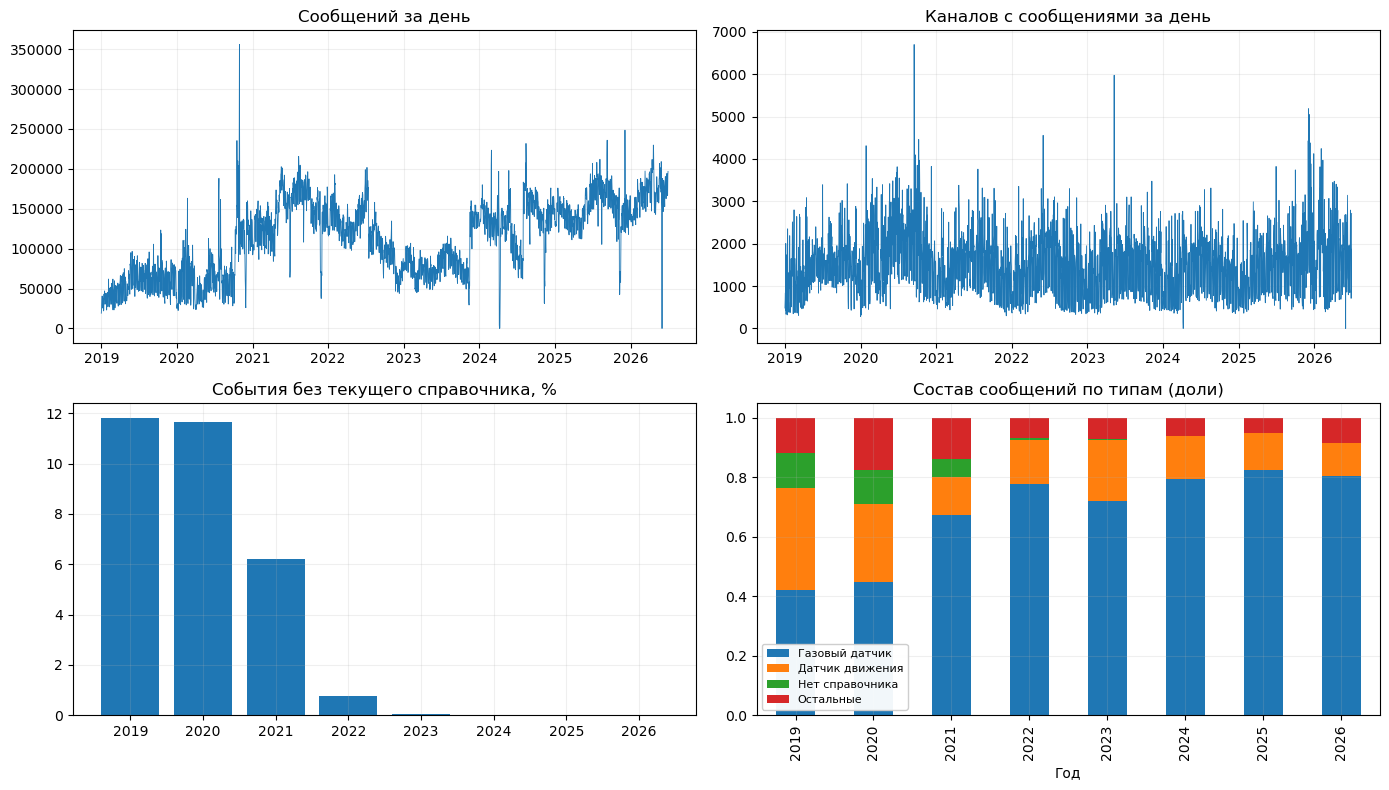

In [27]:
fig,axes=plt.subplots(2,2,figsize=(14,8))
cv=coverage.to_pandas()
axes[0,0].plot(cv.day,cv.events,linewidth=.6)
axes[0,0].set_title('Сообщений за день')
axes[0,1].plot(cv.day,cv.channels,linewidth=.6)
axes[0,1].set_title('Каналов с сообщениями за день')
ya=year_audit.to_pandas()
axes[1,0].bar(ya.year,100*ya.unknown_channel_rows/ya.rows)
axes[1,0].set_title('События без текущего справочника, %')
ty=type_year.to_pandas()
ty['sensor_type']=ty['sensor_type'].fillna('Нет справочника')
pivot=ty.pivot(index='year',columns='sensor_type',values='events').fillna(0)
top_types=pivot.sum().nlargest(3).index
compact=pivot[list(top_types)].copy()
compact['Остальные']=pivot.drop(columns=list(top_types)).sum(axis=1)
compact.div(compact.sum(axis=1),axis=0).plot.bar(stacked=True,ax=axes[1,1],legend=True)
axes[1,1].legend(loc='lower left',fontsize=8,framealpha=.95)
axes[1,1].set_xlabel('Год')
axes[1,1].set_title('Состав сообщений по типам (доли)')
fig.tight_layout()
fig.savefig(OUT/'figures'/'history_overview.png',dpi=140)
plt.show()

In [28]:
print('Типы для расшифровки состава:')
show(type_year.filter(pl.col('year')==2026),30)

Типы для расшифровки состава:


,year,sensor_type,events,alarms,channels
0,2026,Газовый датчик,24709612,1640,511
1,2026,Датчик движения,3404436,9787,804
2,2026,Состояние УИР-Р,451039,2591,762
3,2026,Состояние фазы,380732,3692,948
4,2026,Датчик дыма,354480,77925,4337
5,2026,Переключатель,316232,454,792
6,2026,КД Дверь,307730,2623,917
7,2026,Состояние насоса,282836,31168,180
8,2026,Состояние вентилятора,213106,18659,354
9,2026,Датчик температуры,130373,19343,598


In [29]:
eda_coverage = report('calendar_coverage')
eda_coverage['day'] = pd.to_datetime(eda_coverage['day'])
eda_coverage.loc[eda_coverage['observed_hours'] < 24, ['day', 'events', 'observed_hours', 'channels']]

,day,events,observed_hours,channels
1922,2024-04-06,4412,2,153
1923,2024-04-07,0,0,0
1924,2024-04-08,0,0,0
1925,2024-04-09,799,17,103
2708,2026-06-01,0,0,0


**Вывод:** есть разрыв 6-9 апреля 2024 года (два дня полностью, два частично) и 1 июня 2026 года полностью.
Ноль сообщений в такие дни не означает отсутствие неисправностей. Для признаков сохраняются показатели покрытия;
будущая неполнота учитывается при разметке и оценке.

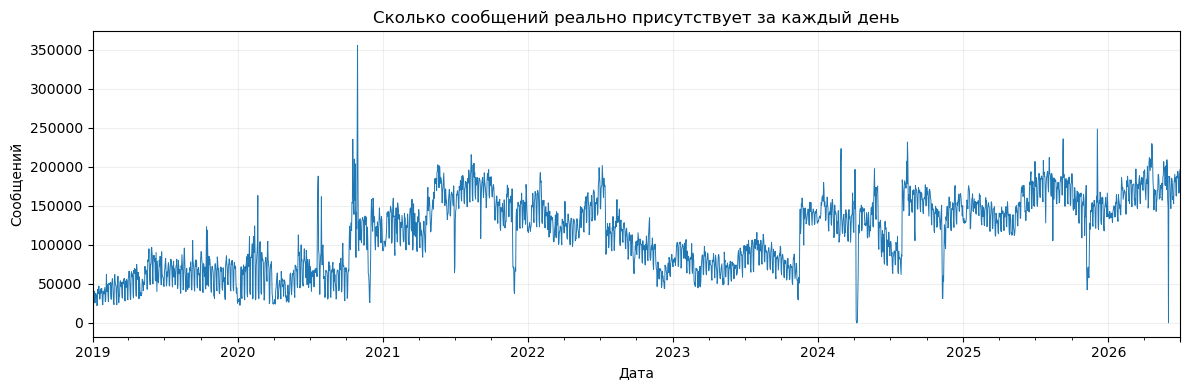

In [30]:
eda_coverage.plot(x='day', y='events', legend=False, linewidth=0.7)
plt.title('Сколько сообщений реально присутствует за каждый день')
plt.xlabel('Дата'); plt.ylabel('Сообщений'); plt.tight_layout(); plt.show()

## 5. Числовые значения по каналам

Числовое поле смешивает разные каналы. Градусы, концентрации и коды состояний нельзя объединять в одну шкалу.
Таблица ниже ищет константные каналы и показывает диапазоны по каналам/годам.
Константа не доказывает поломку: это может быть дискретный канал или округление.
Для ML сохраняем исходную шкалу; производные считаются отдельно внутри каждого канала.
Imputer/scaler/категориальные словари модель обучает только на train.

In [31]:
numeric_audit=channel_year.filter(pl.col('numeric_n')>0).with_columns(
    (pl.col('numeric_distinct')==1).alias('constant_in_observed_year'),
    (pl.col('numeric_max')-pl.col('numeric_min')).alias('observed_range'))
save_table(numeric_audit,'numeric_channel_year')
show(numeric_audit.sort('observed_range',descending=True),20)
numeric_by_type=numeric_audit.group_by('year','sensor_type').agg(pl.len().alias('numeric_channels'),pl.col('constant_in_observed_year').sum().alias('constant_channels'),pl.col('numeric_n').sum())
save_table(numeric_by_type,'numeric_types')
print('Нет достоверных единиц измерения и паспортных границ - физические пороги не придуманы.')

,year,channel_id,first_ts,last_ts,events,alarms,sensor_type,object_id,numeric_n,numeric_min,numeric_max,numeric_distinct,constant_in_observed_year,observed_range
0,2023,228247,2023-01-06 15:53:45,2023-12-15 22:10:32,146,4,Датчик температуры,5332,115,-3260.0,957.0,21,False,4217.0
1,2023,286903,2023-01-01 00:09:42,2023-12-31 18:58:50,658,36,Датчик температуры,5676,578,-3267.0,457.0,35,False,3724.0
2,2019,115219,2019-01-04 05:15:40,2019-12-28 22:02:22,867,46,Датчик температуры,3905,772,-3276.0,128.0,75,False,3404.0
3,2021,212144,2021-01-17 01:04:57,2021-12-22 07:51:08,1048,259,Датчик температуры,5113,616,-3276.0,128.0,139,False,3404.0
4,2021,115264,2021-01-06 08:29:41,2021-12-29 02:23:56,298,21,Датчик температуры,3905,208,-3276.0,128.0,21,False,3404.0
5,2023,287002,2023-01-02 08:47:54,2023-12-31 22:30:56,515,140,Датчик температуры,5676,235,-3276.0,128.0,40,False,3404.0
6,2023,268813,2023-01-01 20:27:08,2023-12-31 20:12:01,1600,266,Датчик температуры,5582,859,-3276.0,128.0,74,False,3404.0
7,2025,228193,2025-01-02 16:51:53,2025-12-29 15:05:21,507,41,Датчик температуры,5332,134,-3276.0,128.0,27,False,3404.0
8,2024,266676,2024-01-01 05:23:14,2024-12-31 06:23:05,873,12,Датчик температуры,42,842,-3276.0,93.0,25,False,3369.0
9,2024,266679,2024-01-08 00:59:30,2024-12-23 09:16:10,589,19,Датчик температуры,42,545,-3276.0,93.0,19,False,3369.0


Нет достоверных единиц измерения и паспортных границ - физические пороги не придуманы.


### Числовые показания и выбросы
Сначала проверим диапазоны **отдельных каналов**. Общий диапазон всех датчиков не имеет единого физического смысла.

In [32]:
eda_numeric_audit = report('numeric_channel_year')
eda_numeric_audit[['year', 'channel_id', 'sensor_type', 'numeric_n', 'numeric_min', 'numeric_max', 'constant_in_observed_year']].head(12)

,year,channel_id,sensor_type,numeric_n,numeric_min,numeric_max,constant_in_observed_year
0,2019,116132,Газовый датчик,45432,0.0,1.69,False
1,2019,147192,Газовый датчик,2601,0.0,1.91,False
2,2019,196759,Газовый датчик,52585,0.0,1.59,False
3,2019,196771,Газовый датчик,48160,0.0,1.15,False
4,2019,213363,Газовый датчик,159910,0.0,1.64,False
5,2019,50679,NaN,224,-127.0,33.00,False
6,2019,196737,Газовый датчик,31688,0.0,1.27,False
7,2019,50733,Датчик температуры,549,-127.0,38.00,False
8,2019,104038,Газовый датчик,65345,0.0,1.53,False
9,2019,116126,Газовый датчик,25543,0.0,1.61,False


In [33]:
eda_numeric_audit.groupby('sensor_type', dropna=False).agg(
    channel_years=('channel_id', 'size'),
    constant_channel_years=('constant_in_observed_year', 'sum'),
    min_observed=('numeric_min', 'min'),
    max_observed=('numeric_max', 'max'),
)

,channel_years,constant_channel_years,min_observed,max_observed
sensor_type,,,,
Газовый датчик,3020,7,-10.23,327.68
Датчик движения,5,5,4.90,10.00
Датчик температуры,4331,3,-3276.00,999.00
ИБП,214,11,0.00,100.00
КД АВ,1,1,0.00,0.00
КД Дверь,5,5,0.00,995.00
Состояние фазы,2,1,0.00,35.30
NaN,553,3,-3276.00,124.00


**Решение:** постоянные значения и большие экстремумы пока отмечены, но не удалены.
Здесь без единиц и паспортных порогов нельзя уверенно объявить число физически невозможным.
Обозначение типа из текущего справочника тоже недостаточно для доказательства единиц измерения.

## 6. Состояния и границы применимости справочника

Анализируем реальные значения во всей истории, сравниваем с таблицей состояний по паре `(тип, текст)` только для аудита.
Несовпадение не удаляет событие. Поле `тревожное` само по себе не используется как метка физической аварии.

* `Неисправен` - основной узкий proxy состояния неисправности канала/контролируемого оборудования.
* `Обесточен`, `Отключено устройство` - отдельные признаки; могут означать плановые действия.
* `Неопределен` - неизвестность, не подтверждение отказа.
* `Обнаружен дым/газ`, `Затоплен` - кандидаты второго модуля, требующие подтверждений.
* Движение и открытие дверей без журналов допусков нельзя назвать несанкционированным доступом.

In [34]:
state_total=observed.group_by('sensor_type','state').agg(pl.col('events').sum(),pl.col('events').filter(pl.col('alarm')==True).sum().alias('alarm_events'))
state_total=state_total.join(state_lookup.rename({'тип_датчика':'sensor_type'}),on=['sensor_type','state'],how='left',validate='m:1').with_columns(
    (pl.col('alarm_events')/pl.col('events')).alias('observed_alarm_rate'),
    pl.col('n_sets').is_null().alias('not_in_dictionary'))
show(save_table(state_total.sort('events',descending=True),'state_semantics'),35)
candidate=observed.filter(pl.col('state').is_in(['неисправен','обесточен','отключено устройство','обнаружен дым','обнаружен газ','затоплен'])).group_by('year','state').agg(pl.col('events').sum()).sort('state','year')
show(save_table(candidate,'target_candidates'),40)

,sensor_type,state,events,alarm_events,alarm_variants,dict_alarm,n_sets,observed_alarm_rate,not_in_dictionary
0,Датчик движения,движения нет,25468145,0,NaN,None,NaN,0.000000,True
1,Датчик движения,обнаружено движение,25468123,202943,NaN,None,NaN,0.007969,True
2,Состояние УИР-Р,норма,2753571,0,NaN,None,NaN,0.000000,True
3,None,обнаружено движение,2728305,4442,NaN,None,NaN,0.001628,True
4,None,движения нет,2728304,0,NaN,None,NaN,0.000000,True
5,Состояние УИР-Р,неопределен,2642992,0,NaN,None,NaN,0.000000,True
6,КД Дверь,норма,2363653,0,1.0,False,2.0,0.000000,False
7,КД Дверь,не замкнут,2210944,37193,NaN,None,NaN,0.016822,True
8,Датчик дыма,норма,1807913,0,NaN,None,NaN,0.000000,True
9,None,норма,1322515,0,NaN,None,NaN,0.000000,True


,year,state,events
0,2019,затоплен,13017
1,2020,затоплен,9777
2,2021,затоплен,11774
3,2022,затоплен,7201
4,2023,затоплен,5964
5,2024,затоплен,6351
6,2025,затоплен,6103
7,2026,затоплен,4227
8,2019,неисправен,23859
9,2020,неисправен,55142


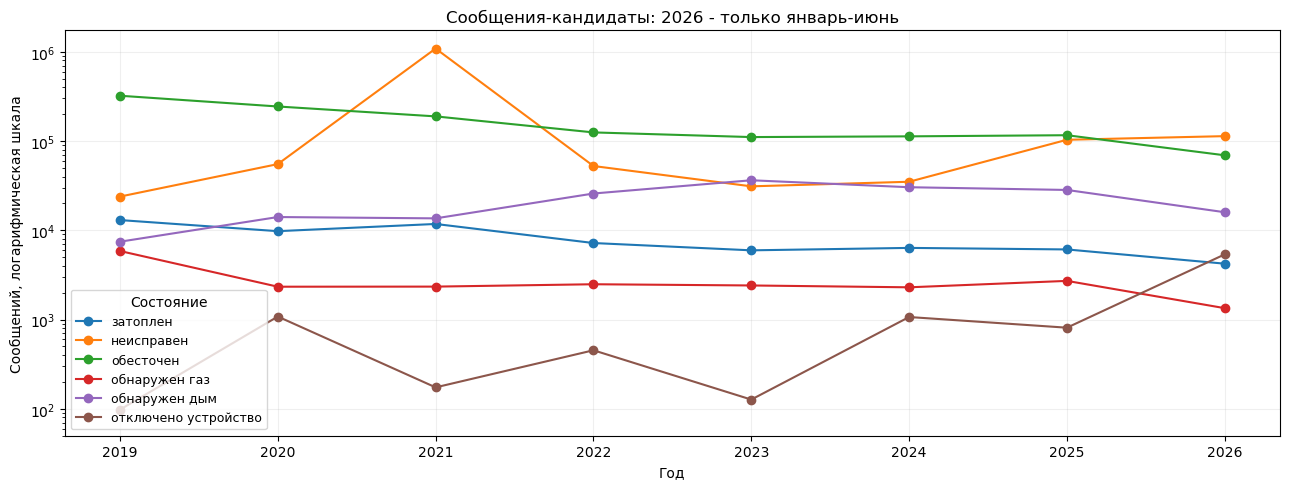

In [35]:
fig,ax=plt.subplots(figsize=(13,5))
cand=candidate.to_pandas().pivot(index='year',columns='state',values='events').fillna(0)
cand.plot(ax=ax,marker='o')
ax.set_yscale('log')
ax.set_ylim(bottom=50)
ax.set_title('Сообщения-кандидаты: 2026 - только январь-июнь')
ax.set_ylabel('Сообщений, логарифмическая шкала')
ax.set_xlabel('Год')
ax.legend(title='Состояние',fontsize=9)
fig.tight_layout()
fig.savefig(OUT/'figures'/'target_candidates.png',dpi=140)
plt.show()

In [36]:
eda_semantics = report('state_semantics')
eda_semantics[['sensor_type', 'state', 'events', 'observed_alarm_rate', 'not_in_dictionary']].sort_values('events', ascending=False).head(15)

,sensor_type,state,events,observed_alarm_rate,not_in_dictionary
0,Датчик движения,движения нет,25468145,0.000000,True
1,Датчик движения,обнаружено движение,25468123,0.007969,True
2,Состояние УИР-Р,норма,2753571,0.000000,True
3,NaN,обнаружено движение,2728305,0.001628,True
4,NaN,движения нет,2728304,0.000000,True
5,Состояние УИР-Р,неопределен,2642992,0.000000,True
6,КД Дверь,норма,2363653,0.000000,False
7,КД Дверь,не замкнут,2210944,0.016822,True
8,Датчик дыма,норма,1807913,0.000000,True
9,NaN,норма,1322515,0.000000,True


In [37]:
eda_unmatched_share = eda_semantics.loc[eda_semantics['not_in_dictionary'], 'events'].sum() / eda_semantics['events'].sum()
print(f'Без пары «тип + состояние» в справочнике: {eda_unmatched_share:.1%} текстовых сообщений')
report('state_conflicts')

Без пары «тип + состояние» в справочнике: 96.4% текстовых сообщений


,тип_датчика,ид_набор_состояний,state,alarm_variants
0,Газовый датчик,13,температура ниже 3ºc1,2


Доля выше относится только к текстовым сообщениям и совпадению пары «тип + состояние». Это не доля испорченных данных. Несопоставленные события сохранены. Справочник не подменяет исходный флаг тревоги; подтверждённой связи канала с набором состояний нет.

## 7. Планы обслуживания: что они добавляют

Мы изучили два Excel с планами на 2026 год и два PDF. PDF содержат организационные правила участия и проведения сессии вопросов, без расшифровки состояний.
В ППР указаны даты демонтажа, передачи на поверку, возврата и сдачи работ по метановым датчикам.
Во втором Excel указаны месяцы ТО и ТР оборудования. Заголовок относится к 2026 году, хотя вкладка называется «2025 год».

Ниже сохранены извлечённые значения с исходными строками и контрольными суммами файлов. Для первого запуска отдельные Excel не обязательны.
В объединённых ячейках ППР используем значение общей ячейки, а не считаем пустую строку отсутствием плана.
Это зафиксированная версия источников. При обновлении Excel нужно заново извлечь и проверить таблицы, а не считать встроенные значения актуальными автоматически.

In [38]:
maintenance_sources = [{'file': 'График ППР АКМ на 2026г. РЭК.xlsx', 'sha256': '8ae33d6362ee16c935f59349ad9c66c1c76c1785fb10e02b828ce003b672cf4d'}, {'file': 'График_ТО_АКМ_и_ДУ_на_2026г_РЭК_3_на_А4.xlsx', 'sha256': 'ef14db84b977a418d346afc3b2b5f0a8a5aef1820144fc955a7c774939a9cd68'}, {'file': 'Инструкция для участника.pdf', 'sha256': 'e103609aa41d02e376b94439024cad676e9cb5c05c7157964a19fef8687cf9fe'}, {'file': 'Ответы на вопросы.pdf', 'sha256': '5d374f73662814b4a50df555658fe27c8a577000e4789db42f966ce4e9ccc6d1'}]
pd.DataFrame(maintenance_sources)

,file,sha256
0,График ППР АКМ на 2026г. РЭК.xlsx,8ae33d6362ee16c935f59349ad9c66c1c76c1785fb10e02b828ce003b672cf4d
1,График_ТО_АКМ_и_ДУ_на_2026г_РЭК_3_на_А4.xlsx,ef14db84b977a418d346afc3b2b5f0a8a5aef1820144fc955a7c774939a9cd68
2,Инструкция для участника.pdf,e103609aa41d02e376b94439024cad676e9cb5c05c7157964a19fef8687cf9fe
3,Ответы на вопросы.pdf,5d374f73662814b4a50df555658fe27c8a577000e4789db42f966ce4e9ccc6d1


In [39]:
ppr_records = [{'division': 'РЭК', 'plan_month': 'Январь', 'object_label': 'Объект 1', 'sensor_count': 56, 'dismantle_start': '2026-01-12T00:00:00', 'delivery_text': 'до 900 13.01.2026', 'return_date': '2026-01-22T00:00:00', 'acceptance_date': '2026-01-27T00:00:00', 'source_row': 10}, {'division': 'РЭК', 'plan_month': 'Январь', 'object_label': 'Объект 2', 'sensor_count': 13, 'dismantle_start': '2026-01-12T00:00:00', 'delivery_text': 'до 900 13.01.2026', 'return_date': '2026-01-22T00:00:00', 'acceptance_date': '2026-01-28T00:00:00', 'source_row': 11}, {'division': 'РЭК', 'plan_month': 'Февраль', 'object_label': 'Объект 3', 'sensor_count': 62, 'dismantle_start': '2026-01-29T00:00:00', 'delivery_text': 'до 900 30.01.2026', 'return_date': '2026-02-09T00:00:00', 'acceptance_date': '2026-02-12T00:00:00', 'source_row': 12}, {'division': 'РЭК', 'plan_month': 'Февраль', 'object_label': 'Объект 4', 'sensor_count': 47, 'dismantle_start': '2026-02-13T00:00:00', 'delivery_text': 'до 900 16.02.2026', 'return_date': '2026-02-24T00:00:00', 'acceptance_date': '2026-02-27T00:00:00', 'source_row': 13}, {'division': 'РЭК', 'plan_month': 'Март', 'object_label': 'Объект 5', 'sensor_count': 102, 'dismantle_start': '2026-03-02T00:00:00', 'delivery_text': 'до 900 03.03.2026', 'return_date': '2026-03-13T00:00:00', 'acceptance_date': '2026-03-19T00:00:00', 'source_row': 14}, {'division': 'РЭК', 'plan_month': 'Март', 'object_label': 'Объект 6', 'sensor_count': 34, 'dismantle_start': '2026-03-23T00:00:00', 'delivery_text': 'до 900 24.03.2026', 'return_date': '2026-04-03T00:00:00', 'acceptance_date': '2026-04-08T00:00:00', 'source_row': 15}, {'division': 'РЭК', 'plan_month': 'Март', 'object_label': 'Объект 7', 'sensor_count': 12, 'dismantle_start': '2026-03-23T00:00:00', 'delivery_text': 'до 900 24.03.2026', 'return_date': '2026-04-03T00:00:00', 'acceptance_date': '2026-04-08T00:00:00', 'source_row': 16}, {'division': 'РЭК', 'plan_month': 'Апрель', 'object_label': 'Объект 8', 'sensor_count': 101, 'dismantle_start': '2026-04-09T00:00:00', 'delivery_text': 'до 900 10.04.2026', 'return_date': '2026-04-17T00:00:00', 'acceptance_date': '2026-04-22T00:00:00', 'source_row': 17}, {'division': 'РЭК', 'plan_month': 'Апрель', 'object_label': 'Объект 9', 'sensor_count': 40, 'dismantle_start': '2026-04-23T00:00:00', 'delivery_text': 'до 900 24.04.2026', 'return_date': '2026-05-07T00:00:00', 'acceptance_date': '2026-05-14T00:00:00', 'source_row': 18}, {'division': 'РЭК', 'plan_month': 'Май', 'object_label': 'Объект 10', 'sensor_count': 6, 'dismantle_start': '2026-05-15T00:00:00', 'delivery_text': 'до 900 18.05.2026', 'return_date': '2026-05-26T00:00:00', 'acceptance_date': '2026-05-29T00:00:00', 'source_row': 19}, {'division': 'РЭК', 'plan_month': 'Май', 'object_label': 'Объект 11', 'sensor_count': 8, 'dismantle_start': '2026-05-15T00:00:00', 'delivery_text': 'до 900 18.05.2026', 'return_date': '2026-05-26T00:00:00', 'acceptance_date': '2026-05-29T00:00:00', 'source_row': 20}, {'division': 'РЭК', 'plan_month': 'Май', 'object_label': 'Объект 12', 'sensor_count': 21, 'dismantle_start': '2026-05-15T00:00:00', 'delivery_text': 'до 900 18.05.2026', 'return_date': '2026-05-26T00:00:00', 'acceptance_date': '2026-05-29T00:00:00', 'source_row': 21}, {'division': 'РЭК', 'plan_month': 'Май', 'object_label': 'Объект 13', 'sensor_count': 21, 'dismantle_start': '2026-05-15T00:00:00', 'delivery_text': 'до 900 18.05.2026', 'return_date': '2026-05-26T00:00:00', 'acceptance_date': '2026-05-29T00:00:00', 'source_row': 22}, {'division': 'РЭК', 'plan_month': 'Июнь', 'object_label': 'Объект 14', 'sensor_count': 33, 'dismantle_start': '2026-06-04T00:00:00', 'delivery_text': 'до 900 05.06.2026', 'return_date': '2026-06-18T00:00:00', 'acceptance_date': '2026-06-29T00:00:00', 'source_row': 23}, {'division': 'РЭК', 'plan_month': 'Июль', 'object_label': 'Объект 15', 'sensor_count': 41, 'dismantle_start': '2026-07-02T00:00:00', 'delivery_text': 'до 900 03.07.2026', 'return_date': '2026-07-16T00:00:00', 'acceptance_date': '2026-07-23T00:00:00', 'source_row': 24}, {'division': 'РЭК', 'plan_month': 'Август', 'object_label': 'Объект 16', 'sensor_count': 95, 'dismantle_start': '2026-07-28T00:00:00', 'delivery_text': 'до 900 29.07.2026', 'return_date': '2026-08-14T00:00:00', 'acceptance_date': '2026-08-19T00:00:00', 'source_row': 25}, {'division': 'РЭК', 'plan_month': 'Август', 'object_label': 'Объект 17', 'sensor_count': 22, 'dismantle_start': '2026-07-28T00:00:00', 'delivery_text': 'до 900 29.07.2026', 'return_date': '2026-08-14T00:00:00', 'acceptance_date': '2026-08-21T00:00:00', 'source_row': 26}, {'division': 'РЭК', 'plan_month': 'Август', 'object_label': 'Объект 18', 'sensor_count': 21, 'dismantle_start': '2026-08-24T00:00:00', 'delivery_text': 'до 900 25.08.2026', 'return_date': '2026-09-04T00:00:00', 'acceptance_date': '2026-09-10T00:00:00', 'source_row': 27}, {'division': 'РЭК', 'plan_month': 'Август', 'object_label': 'Объект 19', 'sensor_count': 5, 'dismantle_start': '2026-08-24T00:00:00', 'delivery_text': 'до 900 25.08.2026', 'return_date': '2026-09-04T00:00:00', 'acceptance_date': '2026-09-10T00:00:00', 'source_row': 28}, {'division': 'РЭК', 'plan_month': 'Сентябрь', 'object_label': 'Объект 20', 'sensor_count': 79, 'dismantle_start': '2026-09-15T00:00:00', 'delivery_text': 'до 900 16.09.2026', 'return_date': '2026-09-30T00:00:00', 'acceptance_date': '2026-10-07T00:00:00', 'source_row': 29}, {'division': 'РЭК', 'plan_month': 'Сентябрь', 'object_label': 'Объект 21', 'sensor_count': 17, 'dismantle_start': '2026-09-15T00:00:00', 'delivery_text': 'до 900 16.09.2026', 'return_date': '2026-09-30T00:00:00', 'acceptance_date': '2026-10-08T00:00:00', 'source_row': 30}, {'division': 'РЭК', 'plan_month': 'Октябрь', 'object_label': 'Объект 22', 'sensor_count': 22, 'dismantle_start': '2026-10-13T00:00:00', 'delivery_text': 'до 900 14.10.2026', 'return_date': '2026-10-23T00:00:00', 'acceptance_date': '2026-10-29T00:00:00', 'source_row': 31}, {'division': 'РЭК', 'plan_month': 'Октябрь', 'object_label': 'Объект 23', 'sensor_count': 36, 'dismantle_start': '2026-10-13T00:00:00', 'delivery_text': 'до 900 14.10.2026', 'return_date': '2026-10-23T00:00:00', 'acceptance_date': '2026-10-29T00:00:00', 'source_row': 32}, {'division': 'РЭК', 'plan_month': 'Октябрь', 'object_label': 'Объект 24', 'sensor_count': 4, 'dismantle_start': '2026-10-13T00:00:00', 'delivery_text': 'до 900 14.10.2026', 'return_date': '2026-10-23T00:00:00', 'acceptance_date': '2026-10-29T00:00:00', 'source_row': 33}, {'division': 'РЭК', 'plan_month': 'Ноябрь', 'object_label': 'Объект 25', 'sensor_count': 55, 'dismantle_start': '2026-11-05T00:00:00', 'delivery_text': 'до 900 06.11.2026', 'return_date': '2026-11-19T00:00:00', 'acceptance_date': '2026-11-25T00:00:00', 'source_row': 34}, {'division': 'РЭК', 'plan_month': 'Декабрь', 'object_label': 'Объект 26', 'sensor_count': 55, 'dismantle_start': '2026-12-02T00:00:00', 'delivery_text': 'до 900 03.12.2026', 'return_date': '2026-12-17T00:00:00', 'acceptance_date': '2026-12-22T00:00:00', 'source_row': 35}]
monthly_records = [{'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МОД', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 7, 'source_cell': 'H7'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МОД', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 7, 'source_cell': 'K7'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МОД', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 7, 'source_cell': 'N7'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МОД', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО+ТР', 'source_row': 7, 'source_cell': 'Q7'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 11927, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 8, 'source_cell': 'K8'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 11927, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО+ТР', 'source_row': 8, 'source_cell': 'Q8'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 11860, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 9, 'source_cell': 'K9'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 11860, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО+ТР', 'source_row': 9, 'source_cell': 'Q9'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МУИ', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 10, 'source_cell': 'H10'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МУИ', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 10, 'source_cell': 'K10'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МУИ', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 10, 'source_cell': 'N10'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МУИ', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО+ТР', 'source_row': 10, 'source_cell': 'Q10'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 11, 'source_cell': 'H11'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 11, 'source_cell': 'K11'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 11, 'source_cell': 'N11'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО+ТР', 'source_row': 11, 'source_cell': 'Q11'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 12, 'source_cell': 'G12'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 12, 'source_cell': 'I12'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 12, 'source_cell': 'K12'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 12, 'source_cell': 'M12'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 12, 'source_cell': 'O12'}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО+ТР', 'source_row': 12, 'source_cell': 'Q12'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 7825, 'unit': 'м.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 14, 'source_cell': 'G14'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 7825, 'unit': 'м.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 14, 'source_cell': 'M14'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 6930, 'unit': 'м.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 15, 'source_cell': 'G15'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 6930, 'unit': 'м.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 15, 'source_cell': 'M15'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 16, 'source_cell': 'G16'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 16, 'source_cell': 'I16'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 16, 'source_cell': 'K16'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 16, 'source_cell': 'M16'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 16, 'source_cell': 'O16'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 16, 'source_cell': 'Q16'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 17, 'source_cell': 'G17'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 17, 'source_cell': 'I17'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 17, 'source_cell': 'K17'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 17, 'source_cell': 'M17'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 17, 'source_cell': 'O17'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 17, 'source_cell': 'Q17'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 18, 'source_cell': 'G18'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 18, 'source_cell': 'I18'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 18, 'source_cell': 'K18'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 18, 'source_cell': 'M18'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 18, 'source_cell': 'O18'}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 18, 'source_cell': 'Q18'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 12168, 'unit': 'м.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 20, 'source_cell': 'H20'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 12168, 'unit': 'м.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 20, 'source_cell': 'N20'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 14426, 'unit': 'м.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 21, 'source_cell': 'H21'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 14426, 'unit': 'м.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 21, 'source_cell': 'N21'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 42, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 22, 'source_cell': 'H22'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 42, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 22, 'source_cell': 'K22'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 42, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 22, 'source_cell': 'N22'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 42, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 22, 'source_cell': 'Q22'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 62, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 23, 'source_cell': 'H23'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 62, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 23, 'source_cell': 'K23'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 62, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 23, 'source_cell': 'N23'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 62, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 23, 'source_cell': 'Q23'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 24, 'source_cell': 'H24'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 24, 'source_cell': 'K24'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 24, 'source_cell': 'N24'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 24, 'source_cell': 'Q24'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 5, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 25, 'source_cell': 'H25'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 5, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 25, 'source_cell': 'K25'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 5, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 25, 'source_cell': 'N25'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 5, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 25, 'source_cell': 'Q25'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 26, 'source_cell': 'H26'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 26, 'source_cell': 'K26'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 26, 'source_cell': 'N26'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 26, 'source_cell': 'Q26'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 27, 'source_cell': 'H27'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 27, 'source_cell': 'K27'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 27, 'source_cell': 'N27'}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 27, 'source_cell': 'Q27'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1135, 'unit': 'м.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 29, 'source_cell': 'G29'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1135, 'unit': 'м.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 29, 'source_cell': 'M29'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 30, 'source_cell': 'G30'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 30, 'source_cell': 'I30'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 30, 'source_cell': 'K30'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 30, 'source_cell': 'M30'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 30, 'source_cell': 'O30'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 30, 'source_cell': 'Q30'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 930, 'unit': 'м.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 31, 'source_cell': 'G31'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 930, 'unit': 'м.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 31, 'source_cell': 'M31'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 32, 'source_cell': 'G32'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 32, 'source_cell': 'I32'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 32, 'source_cell': 'K32'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 32, 'source_cell': 'M32'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 32, 'source_cell': 'O32'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 32, 'source_cell': 'Q32'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 33, 'source_cell': 'G33'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 33, 'source_cell': 'I33'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 33, 'source_cell': 'K33'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 33, 'source_cell': 'M33'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 33, 'source_cell': 'O33'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 33, 'source_cell': 'Q33'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО+ТР', 'source_row': 34, 'source_cell': 'G34'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 34, 'source_cell': 'I34'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 34, 'source_cell': 'K34'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 34, 'source_cell': 'M34'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 34, 'source_cell': 'O34'}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 34, 'source_cell': 'Q34'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 34, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 36, 'source_cell': 'G36'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 34, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 36, 'source_cell': 'J36'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 34, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 36, 'source_cell': 'M36'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 34, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 36, 'source_cell': 'P36'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 9903, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 37, 'source_cell': 'J37'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 9903, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 37, 'source_cell': 'P37'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 13749, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 38, 'source_cell': 'J38'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 13749, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 38, 'source_cell': 'P38'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 39, 'source_cell': 'H39'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 39, 'source_cell': 'J39'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 39, 'source_cell': 'L39'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 39, 'source_cell': 'N39'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 39, 'source_cell': 'P39'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 39, 'source_cell': 'R39'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 40, 'source_cell': 'G40'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 40, 'source_cell': 'J40'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 40, 'source_cell': 'M40'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 40, 'source_cell': 'P40'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 41, 'source_cell': 'G41'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 41, 'source_cell': 'J41'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 41, 'source_cell': 'M41'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 41, 'source_cell': 'P41'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 42, 'source_cell': 'G42'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 42, 'source_cell': 'J42'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 42, 'source_cell': 'M42'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 42, 'source_cell': 'P42'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 43, 'source_cell': 'G43'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 43, 'source_cell': 'J43'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 43, 'source_cell': 'M43'}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 43, 'source_cell': 'P43'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 2606, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 46, 'source_cell': 'J46'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 2606, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 46, 'source_cell': 'P46'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 2536, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 47, 'source_cell': 'J47'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 2536, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 47, 'source_cell': 'P47'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 48, 'source_cell': 'H48'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 48, 'source_cell': 'J48'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 48, 'source_cell': 'L48'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 48, 'source_cell': 'N48'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 48, 'source_cell': 'P48'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 48, 'source_cell': 'R48'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 49, 'source_cell': 'H49'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 49, 'source_cell': 'J49'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 49, 'source_cell': 'L49'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 49, 'source_cell': 'N49'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 49, 'source_cell': 'P49'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 49, 'source_cell': 'R49'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 50, 'source_cell': 'H50'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 50, 'source_cell': 'J50'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 50, 'source_cell': 'L50'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 50, 'source_cell': 'N50'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 50, 'source_cell': 'P50'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 50, 'source_cell': 'R50'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 51, 'source_cell': 'H51'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 51, 'source_cell': 'J51'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 51, 'source_cell': 'L51'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 51, 'source_cell': 'N51'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 51, 'source_cell': 'P51'}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 51, 'source_cell': 'R51'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 53, 'source_cell': 'H53'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 53, 'source_cell': 'J53'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 53, 'source_cell': 'L53'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 53, 'source_cell': 'N53'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 53, 'source_cell': 'P53'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 53, 'source_cell': 'R53'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 13300, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 54, 'source_cell': 'J54'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 13300, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 54, 'source_cell': 'P54'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 6781, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 55, 'source_cell': 'J55'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 6781, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 55, 'source_cell': 'P55'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 68, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 56, 'source_cell': 'G56'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 68, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 56, 'source_cell': 'J56'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 68, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 56, 'source_cell': 'M56'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 68, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 56, 'source_cell': 'P56'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Усилитель линии УСЛБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 57, 'source_cell': 'G57'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Усилитель линии УСЛБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 57, 'source_cell': 'J57'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Усилитель линии УСЛБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 57, 'source_cell': 'M57'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Усилитель линии УСЛБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 57, 'source_cell': 'P57'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 58, 'source_cell': 'H58'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 58, 'source_cell': 'J58'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 58, 'source_cell': 'L58'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 58, 'source_cell': 'N58'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 58, 'source_cell': 'P58'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 58, 'source_cell': 'R58'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 59, 'source_cell': 'H59'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 59, 'source_cell': 'J59'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 59, 'source_cell': 'L59'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 59, 'source_cell': 'N59'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 59, 'source_cell': 'P59'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 59, 'source_cell': 'R59'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 60, 'source_cell': 'H60'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО+ТР', 'source_row': 60, 'source_cell': 'J60'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 60, 'source_cell': 'L60'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 60, 'source_cell': 'N60'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 60, 'source_cell': 'P60'}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 60, 'source_cell': 'R60'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5670, 'unit': 'м.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 62, 'source_cell': 'H62'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5670, 'unit': 'м.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 62, 'source_cell': 'N62'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 63, 'source_cell': 'H63'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 63, 'source_cell': 'J63'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 63, 'source_cell': 'L63'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 63, 'source_cell': 'N63'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 63, 'source_cell': 'P63'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 63, 'source_cell': 'R63'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 7850, 'unit': 'м.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 64, 'source_cell': 'H64'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 7850, 'unit': 'м.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 64, 'source_cell': 'N64'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 65, 'source_cell': 'H65'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 65, 'source_cell': 'J65'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 65, 'source_cell': 'L65'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 65, 'source_cell': 'N65'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 65, 'source_cell': 'P65'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 65, 'source_cell': 'R65'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 66, 'source_cell': 'H66'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 66, 'source_cell': 'J66'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 66, 'source_cell': 'L66'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 66, 'source_cell': 'N66'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 66, 'source_cell': 'P66'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 66, 'source_cell': 'R66'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО+ТР', 'source_row': 67, 'source_cell': 'H67'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 67, 'source_cell': 'J67'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 67, 'source_cell': 'L67'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 67, 'source_cell': 'N67'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 67, 'source_cell': 'P67'}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 67, 'source_cell': 'R67'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Кабельные линии ДУ', 'quantity': 7275, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 69, 'source_cell': 'K69'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Кабельные линии ДУ', 'quantity': 7275, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 69, 'source_cell': 'Q69'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'МУСБ', 'quantity': 45, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 70, 'source_cell': 'H70'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'МУСБ', 'quantity': 45, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 70, 'source_cell': 'K70'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'МУСБ', 'quantity': 45, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 70, 'source_cell': 'N70'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'МУСБ', 'quantity': 45, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 70, 'source_cell': 'Q70'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 71, 'source_cell': 'H71'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 71, 'source_cell': 'K71'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 71, 'source_cell': 'N71'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 71, 'source_cell': 'Q71'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Кабельные линии АКМ', 'quantity': 40, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 72, 'source_cell': 'K72'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Кабельные линии АКМ', 'quantity': 40, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 72, 'source_cell': 'Q72'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'УЛСБ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 73, 'source_cell': 'H73'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'УЛСБ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 73, 'source_cell': 'K73'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'УЛСБ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 73, 'source_cell': 'N73'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'УЛСБ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 73, 'source_cell': 'Q73'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ГАСБ', 'quantity': 40, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 77, 'source_cell': 'H77'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ГАСБ', 'quantity': 40, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 77, 'source_cell': 'K77'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ГАСБ', 'quantity': 40, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 77, 'source_cell': 'N77'}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ГАСБ', 'quantity': 40, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 77, 'source_cell': 'Q77'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 490, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 79, 'source_cell': 'K79'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 490, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 79, 'source_cell': 'Q79'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 80, 'source_cell': 'G80'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 80, 'source_cell': 'I80'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 80, 'source_cell': 'K80'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 80, 'source_cell': 'M80'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 80, 'source_cell': 'O80'}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 80, 'source_cell': 'Q80'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1190, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 82, 'source_cell': 'K82'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1190, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 82, 'source_cell': 'Q82'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1687, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 83, 'source_cell': 'K83'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1687, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 83, 'source_cell': 'Q83'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 84, 'source_cell': 'G84'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 84, 'source_cell': 'I84'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 84, 'source_cell': 'K84'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 84, 'source_cell': 'M84'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 84, 'source_cell': 'O84'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 84, 'source_cell': 'Q84'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 85, 'source_cell': 'G85'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 85, 'source_cell': 'I85'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 85, 'source_cell': 'K85'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 85, 'source_cell': 'M85'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 85, 'source_cell': 'O85'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 85, 'source_cell': 'Q85'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 86, 'source_cell': 'G86'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 86, 'source_cell': 'I86'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 86, 'source_cell': 'K86'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 86, 'source_cell': 'M86'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 86, 'source_cell': 'O86'}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 86, 'source_cell': 'Q86'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 88, 'source_cell': 'G88'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 88, 'source_cell': 'I88'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 88, 'source_cell': 'K88'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 88, 'source_cell': 'M88'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 88, 'source_cell': 'O88'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 88, 'source_cell': 'Q88'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 2530, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 89, 'source_cell': 'K89'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 2530, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 89, 'source_cell': 'Q89'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 90, 'source_cell': 'G90'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 90, 'source_cell': 'I90'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 90, 'source_cell': 'K90'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 90, 'source_cell': 'M90'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 90, 'source_cell': 'O90'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 90, 'source_cell': 'Q90'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 91, 'source_cell': 'G91'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 91, 'source_cell': 'I91'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 91, 'source_cell': 'K91'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 91, 'source_cell': 'M91'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 91, 'source_cell': 'O91'}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 91, 'source_cell': 'Q91'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 3805, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 93, 'source_cell': 'K93'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 3805, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 93, 'source_cell': 'Q93'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 94, 'source_cell': 'G94'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 94, 'source_cell': 'I94'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 94, 'source_cell': 'K94'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 94, 'source_cell': 'M94'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 94, 'source_cell': 'O94'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 94, 'source_cell': 'Q94'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 95, 'source_cell': 'G95'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 95, 'source_cell': 'I95'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 95, 'source_cell': 'K95'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 95, 'source_cell': 'M95'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 95, 'source_cell': 'O95'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 95, 'source_cell': 'Q95'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 6910, 'unit': 'м.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 96, 'source_cell': 'K96'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 6910, 'unit': 'м.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 96, 'source_cell': 'Q96'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 97, 'source_cell': 'G97'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 97, 'source_cell': 'I97'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО+ТР', 'source_row': 97, 'source_cell': 'K97'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 97, 'source_cell': 'M97'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 97, 'source_cell': 'O97'}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 97, 'source_cell': 'Q97'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1707, 'unit': 'м.', 'plan_year': 2026, 'month': 6, 'action': 'ТО+ТР', 'source_row': 99, 'source_cell': 'L99'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1707, 'unit': 'м.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 99, 'source_cell': 'R99'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 43, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 100, 'source_cell': 'I100'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 43, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО+ТР', 'source_row': 100, 'source_cell': 'L100'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 43, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 100, 'source_cell': 'O100'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 43, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 100, 'source_cell': 'R100'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 27.5, 'unit': 'м.', 'plan_year': 2026, 'month': 6, 'action': 'ТО+ТР', 'source_row': 101, 'source_cell': 'L101'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 27.5, 'unit': 'м.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 101, 'source_cell': 'R101'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 33, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 102, 'source_cell': 'I102'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 33, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО+ТР', 'source_row': 102, 'source_cell': 'L102'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 33, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 102, 'source_cell': 'O102'}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 33, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 102, 'source_cell': 'R102'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 41, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 104, 'source_cell': 'G104'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 41, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 104, 'source_cell': 'J104'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 41, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 104, 'source_cell': 'M104'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 41, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 104, 'source_cell': 'P104'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 4172, 'unit': 'м.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 105, 'source_cell': 'G105'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 4172, 'unit': 'м.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 105, 'source_cell': 'M105'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 8125, 'unit': 'м.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 106, 'source_cell': 'G106'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 8125, 'unit': 'м.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 106, 'source_cell': 'M106'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 27, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 107, 'source_cell': 'G107'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 27, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 107, 'source_cell': 'J107'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 27, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 107, 'source_cell': 'M107'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 27, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 107, 'source_cell': 'P107'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 108, 'source_cell': 'G108'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 108, 'source_cell': 'J108'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 108, 'source_cell': 'M108'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 108, 'source_cell': 'P108'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 109, 'source_cell': 'G109'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 109, 'source_cell': 'J109'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 109, 'source_cell': 'M109'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 109, 'source_cell': 'P109'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 110, 'source_cell': 'G110'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 110, 'source_cell': 'J110'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО+ТР', 'source_row': 110, 'source_cell': 'M110'}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 7, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 110, 'source_cell': 'P110'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 28090, 'unit': 'м.', 'plan_year': 2026, 'month': 3, 'action': 'ТО+ТР', 'source_row': 112, 'source_cell': 'I112'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 28090, 'unit': 'м.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 112, 'source_cell': 'O112'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 113, 'source_cell': 'G113'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО+ТР', 'source_row': 113, 'source_cell': 'I113'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 113, 'source_cell': 'K113'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 113, 'source_cell': 'M113'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 113, 'source_cell': 'O113'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 113, 'source_cell': 'Q113'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 114, 'source_cell': 'G114'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО+ТР', 'source_row': 114, 'source_cell': 'I114'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 114, 'source_cell': 'K114'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 114, 'source_cell': 'M114'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 114, 'source_cell': 'O114'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 114, 'source_cell': 'Q114'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 21800, 'unit': 'м.', 'plan_year': 2026, 'month': 3, 'action': 'ТО+ТР', 'source_row': 115, 'source_cell': 'I115'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 21800, 'unit': 'м.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 115, 'source_cell': 'O115'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 116, 'source_cell': 'G116'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО+ТР', 'source_row': 116, 'source_cell': 'I116'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 116, 'source_cell': 'K116'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 116, 'source_cell': 'M116'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 116, 'source_cell': 'O116'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 116, 'source_cell': 'Q116'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 117, 'source_cell': 'G117'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО+ТР', 'source_row': 117, 'source_cell': 'I117'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 117, 'source_cell': 'K117'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 117, 'source_cell': 'M117'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 117, 'source_cell': 'O117'}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 117, 'source_cell': 'Q117'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1155, 'unit': 'м.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 119, 'source_cell': 'I119'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1155, 'unit': 'м.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 119, 'source_cell': 'O119'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 26, 'unit': 'м.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 120, 'source_cell': 'I120'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 26, 'unit': 'м.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 120, 'source_cell': 'O120'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 121, 'source_cell': 'I121'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 121, 'source_cell': 'L121'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 121, 'source_cell': 'O121'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 121, 'source_cell': 'R121'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 26, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 122, 'source_cell': 'I122'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 26, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 122, 'source_cell': 'L122'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 26, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 122, 'source_cell': 'O122'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 26, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 122, 'source_cell': 'R122'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 123, 'source_cell': 'I123'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 123, 'source_cell': 'L123'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 123, 'source_cell': 'O123'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 123, 'source_cell': 'R123'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 124, 'source_cell': 'I124'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 124, 'source_cell': 'L124'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 124, 'source_cell': 'O124'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 124, 'source_cell': 'R124'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТР', 'source_row': 125, 'source_cell': 'N125'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТР', 'source_row': 125, 'source_cell': 'O125'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 127, 'source_cell': 'I127'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 127, 'source_cell': 'L127'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО+ТР', 'source_row': 127, 'source_cell': 'O127'}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 127, 'source_cell': 'R127'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 129, 'source_cell': 'G129'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 129, 'source_cell': 'J129'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 129, 'source_cell': 'M129'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 79, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 129, 'source_cell': 'P129'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1055, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 130, 'source_cell': 'J130'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1055, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 130, 'source_cell': 'P130'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 131, 'source_cell': 'G131'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 131, 'source_cell': 'J131'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 131, 'source_cell': 'M131'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 131, 'source_cell': 'P131'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь N-port 5232', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 132, 'source_cell': 'G132'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь N-port 5232', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 132, 'source_cell': 'J132'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь N-port 5232', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 132, 'source_cell': 'M132'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь N-port 5232', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 132, 'source_cell': 'P132'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 133, 'source_cell': 'G133'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 133, 'source_cell': 'J133'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 133, 'source_cell': 'M133'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 133, 'source_cell': 'P133'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 134, 'source_cell': 'G134'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 134, 'source_cell': 'J134'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 134, 'source_cell': 'M134'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 134, 'source_cell': 'P134'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 11918, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 135, 'source_cell': 'J135'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 11918, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 135, 'source_cell': 'P135'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 59, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 136, 'source_cell': 'G136'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 59, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 136, 'source_cell': 'J136'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 59, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 136, 'source_cell': 'M136'}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 59, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 136, 'source_cell': 'P136'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 1449, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 138, 'source_cell': 'J138'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 1449, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 138, 'source_cell': 'P138'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1458, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 139, 'source_cell': 'J139'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1458, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 139, 'source_cell': 'P139'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 140, 'source_cell': 'G140'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 140, 'source_cell': 'J140'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 140, 'source_cell': 'M140'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 9, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 140, 'source_cell': 'P140'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 17, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 141, 'source_cell': 'G141'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 17, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 141, 'source_cell': 'J141'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 17, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 141, 'source_cell': 'M141'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 17, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 141, 'source_cell': 'P141'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 142, 'source_cell': 'G142'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 142, 'source_cell': 'J142'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 142, 'source_cell': 'M142'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 142, 'source_cell': 'P142'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 143, 'source_cell': 'G143'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 143, 'source_cell': 'J143'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 143, 'source_cell': 'M143'}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 143, 'source_cell': 'P143'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 3570, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 145, 'source_cell': 'J145'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 3570, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 145, 'source_cell': 'P145'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1850, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 146, 'source_cell': 'J146'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1850, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 146, 'source_cell': 'P146'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 147, 'source_cell': 'H147'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 147, 'source_cell': 'J147'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 147, 'source_cell': 'L147'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 147, 'source_cell': 'N147'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 147, 'source_cell': 'P147'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 147, 'source_cell': 'R147'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 148, 'source_cell': 'H148'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 148, 'source_cell': 'J148'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 148, 'source_cell': 'L148'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 148, 'source_cell': 'N148'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 148, 'source_cell': 'P148'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 148, 'source_cell': 'R148'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 149, 'source_cell': 'H149'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 149, 'source_cell': 'J149'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 149, 'source_cell': 'L149'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО', 'source_row': 149, 'source_cell': 'N149'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 149, 'source_cell': 'P149'}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 149, 'source_cell': 'R149'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5740, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 150, 'source_cell': 'J150'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5740, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 150, 'source_cell': 'P150'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 40, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 151, 'source_cell': 'J151'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 40, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 151, 'source_cell': 'P151'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 31, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 152, 'source_cell': 'G152'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 31, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 152, 'source_cell': 'J152'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 31, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 152, 'source_cell': 'M152'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 31, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 152, 'source_cell': 'P152'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 36, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 153, 'source_cell': 'G153'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 36, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 153, 'source_cell': 'J153'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 36, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 153, 'source_cell': 'M153'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 36, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 153, 'source_cell': 'P153'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 154, 'source_cell': 'G154'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 154, 'source_cell': 'J154'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 154, 'source_cell': 'M154'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 154, 'source_cell': 'P154'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 155, 'source_cell': 'G155'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 155, 'source_cell': 'J155'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 155, 'source_cell': 'M155'}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 155, 'source_cell': 'P155'}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 1, 'action': 'ТО', 'source_row': 157, 'source_cell': 'G157'}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 157, 'source_cell': 'J157'}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 7, 'action': 'ТО', 'source_row': 157, 'source_cell': 'M157'}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 4, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 157, 'source_cell': 'P157'}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 4, 'unit': 'м.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 158, 'source_cell': 'J158'}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 4, 'unit': 'м.', 'plan_year': 2026, 'month': 10, 'action': 'ТО+ТР', 'source_row': 158, 'source_cell': 'P158'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5310, 'unit': 'м.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 160, 'source_cell': 'H160'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5310, 'unit': 'м.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 160, 'source_cell': 'N160'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 161, 'source_cell': 'H161'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 161, 'source_cell': 'J161'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 161, 'source_cell': 'L161'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 161, 'source_cell': 'N161'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 161, 'source_cell': 'P161'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 161, 'source_cell': 'R161'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 162, 'source_cell': 'H162'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 162, 'source_cell': 'J162'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 162, 'source_cell': 'L162'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 162, 'source_cell': 'N162'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 162, 'source_cell': 'P162'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 162, 'source_cell': 'R162'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 17346, 'unit': 'м.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 163, 'source_cell': 'H163'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 17346, 'unit': 'м.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 163, 'source_cell': 'N163'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 164, 'source_cell': 'H164'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 164, 'source_cell': 'K164'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 164, 'source_cell': 'N164'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 3, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 164, 'source_cell': 'Q164'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 15, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 165, 'source_cell': 'H165'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 15, 'unit': 'шт.', 'plan_year': 2026, 'month': 5, 'action': 'ТО', 'source_row': 165, 'source_cell': 'K165'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 15, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 165, 'source_cell': 'N165'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 15, 'unit': 'шт.', 'plan_year': 2026, 'month': 11, 'action': 'ТО', 'source_row': 165, 'source_cell': 'Q165'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 166, 'source_cell': 'H166'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 166, 'source_cell': 'J166'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 166, 'source_cell': 'L166'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 166, 'source_cell': 'N166'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 166, 'source_cell': 'P166'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 166, 'source_cell': 'R166'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'plan_year': 2026, 'month': 2, 'action': 'ТО', 'source_row': 167, 'source_cell': 'H167'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'plan_year': 2026, 'month': 4, 'action': 'ТО', 'source_row': 167, 'source_cell': 'J167'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 167, 'source_cell': 'L167'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'plan_year': 2026, 'month': 8, 'action': 'ТО+ТР', 'source_row': 167, 'source_cell': 'N167'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'plan_year': 2026, 'month': 10, 'action': 'ТО', 'source_row': 167, 'source_cell': 'P167'}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО', 'source_row': 167, 'source_cell': 'R167'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 1135, 'unit': 'м.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 169, 'source_cell': 'L169'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 1135, 'unit': 'м.', 'plan_year': 2026, 'month': 12, 'action': 'ТО+ТР', 'source_row': 169, 'source_cell': 'R169'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 520, 'unit': 'м.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 170, 'source_cell': 'L170'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 520, 'unit': 'м.', 'plan_year': 2026, 'month': 12, 'action': 'ТО+ТР', 'source_row': 170, 'source_cell': 'R170'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 49, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 171, 'source_cell': 'I171'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 49, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 171, 'source_cell': 'L171'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 49, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 171, 'source_cell': 'O171'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 49, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО+ТР', 'source_row': 171, 'source_cell': 'R171'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 3, 'action': 'ТО', 'source_row': 172, 'source_cell': 'I172'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 6, 'action': 'ТО', 'source_row': 172, 'source_cell': 'L172'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 9, 'action': 'ТО', 'source_row': 172, 'source_cell': 'O172'}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 55, 'unit': 'шт.', 'plan_year': 2026, 'month': 12, 'action': 'ТО+ТР', 'source_row': 172, 'source_cell': 'R172'}]

In [40]:
equipment_records = [{'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МОД', 'quantity': 55, 'unit': 'шт.', 'source_row': 7}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 11927, 'unit': 'м.', 'source_row': 8}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 11860, 'unit': 'м.', 'source_row': 9}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'МУИ', 'quantity': 7, 'unit': 'шт.', 'source_row': 10}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 7, 'unit': 'шт.', 'source_row': 11}, {'schedule_group': 1, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 16, 'unit': 'шт.', 'source_row': 12}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 7825, 'unit': 'м.', 'source_row': 14}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 6930, 'unit': 'м.', 'source_row': 15}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 12, 'unit': 'шт.', 'source_row': 16}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 20, 'unit': 'шт.', 'source_row': 17}, {'schedule_group': 2, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 56, 'unit': 'шт.', 'source_row': 18}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 12168, 'unit': 'м.', 'source_row': 20}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 14426, 'unit': 'м.', 'source_row': 21}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 42, 'unit': 'шт.', 'source_row': 22}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 62, 'unit': 'шт.', 'source_row': 23}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'source_row': 24}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 5, 'unit': 'шт.', 'source_row': 25}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 13, 'unit': 'шт.', 'source_row': 26}, {'schedule_group': 3, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь', 'quantity': 2, 'unit': 'шт.', 'source_row': 27}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1135, 'unit': 'м.', 'source_row': 29}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'source_row': 30}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 930, 'unit': 'м.', 'source_row': 31}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'source_row': 32}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'source_row': 33}, {'schedule_group': 4, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 13, 'unit': 'шт.', 'source_row': 34}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 34, 'unit': 'шт.', 'source_row': 36}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 9903, 'unit': 'м.', 'source_row': 37}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 13749, 'unit': 'м.', 'source_row': 38}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'source_row': 39}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 3, 'unit': 'шт.', 'source_row': 40}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 6, 'unit': 'шт.', 'source_row': 41}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 1, 'unit': 'шт.', 'source_row': 42}, {'schedule_group': 5, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь ', 'quantity': 3, 'unit': 'шт.', 'source_row': 43}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 2606, 'unit': 'м.', 'source_row': 46}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 2536, 'unit': 'м.', 'source_row': 47}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'source_row': 48}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'source_row': 49}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'source_row': 50}, {'schedule_group': 6, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 12, 'unit': 'шт.', 'source_row': 51}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 4, 'unit': 'шт.', 'source_row': 53}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 13300, 'unit': 'м.', 'source_row': 54}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 6781, 'unit': 'м.', 'source_row': 55}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 68, 'unit': 'шт.', 'source_row': 56}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Усилитель линии УСЛБ-А', 'quantity': 6, 'unit': 'шт.', 'source_row': 57}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'source_row': 58}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'source_row': 59}, {'schedule_group': 7, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 101, 'unit': 'шт.', 'source_row': 60}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5670, 'unit': 'м.', 'source_row': 62}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'source_row': 63}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 7850, 'unit': 'м.', 'source_row': 64}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'source_row': 65}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 8, 'unit': 'шт.', 'source_row': 66}, {'schedule_group': 8, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 47, 'unit': 'шт.', 'source_row': 67}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Кабельные линии ДУ', 'quantity': 7275, 'unit': 'м.', 'source_row': 69}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'МУСБ', 'quantity': 45, 'unit': 'шт.', 'source_row': 70}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'source_row': 71}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Кабельные линии АКМ', 'quantity': 40, 'unit': 'м.', 'source_row': 72}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'УЛСБ', 'quantity': 6, 'unit': 'шт.', 'source_row': 73}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'Газоанализаторы', 'quantity': 95, 'unit': 'шт.', 'source_row': 74}, {'schedule_group': 9, 'object_label': 'к-р Ясенево', 'equipment': 'ГАСБ', 'quantity': 40, 'unit': 'шт.', 'source_row': 77}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 490, 'unit': 'м.', 'source_row': 79}, {'schedule_group': 10, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'source_row': 80}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1190, 'unit': 'м.', 'source_row': 82}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1687, 'unit': 'м.', 'source_row': 83}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'source_row': 84}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'source_row': 85}, {'schedule_group': 11, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 14, 'unit': 'шт.', 'source_row': 86}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 1, 'unit': 'шт.', 'source_row': 88}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 2530, 'unit': 'м.', 'source_row': 89}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'source_row': 90}, {'schedule_group': 12, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 4, 'unit': 'шт.', 'source_row': 91}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 3805, 'unit': 'м.', 'source_row': 93}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 21, 'unit': 'шт.', 'source_row': 94}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 2, 'unit': 'шт.', 'source_row': 95}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 6910, 'unit': 'м.', 'source_row': 96}, {'schedule_group': 13, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 1, 'unit': 'шт.', 'source_row': 97}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1707, 'unit': 'м.', 'source_row': 99}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 43, 'unit': 'шт.', 'source_row': 100}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 27.5, 'unit': 'м.', 'source_row': 101}, {'schedule_group': 14, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 33, 'unit': 'шт.', 'source_row': 102}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 41, 'unit': 'шт.', 'source_row': 104}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 4172, 'unit': 'м.', 'source_row': 105}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 8125, 'unit': 'м.', 'source_row': 106}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 27, 'unit': 'шт.', 'source_row': 107}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 2, 'unit': 'шт.', 'source_row': 108}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'source_row': 109}, {'schedule_group': 15, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 7, 'unit': 'шт.', 'source_row': 110}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 28090, 'unit': 'м.', 'source_row': 112}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'source_row': 113}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'source_row': 114}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 21800, 'unit': 'м.', 'source_row': 115}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 24, 'unit': 'шт.', 'source_row': 116}, {'schedule_group': 16, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 102, 'unit': 'шт.', 'source_row': 117}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1155, 'unit': 'м.', 'source_row': 119}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 26, 'unit': 'м.', 'source_row': 120}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 79, 'unit': 'шт.', 'source_row': 121}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 26, 'unit': 'шт.', 'source_row': 122}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 3, 'unit': 'шт.', 'source_row': 123}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 3, 'unit': 'шт.', 'source_row': 124}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 8, 'unit': 'шт.', 'source_row': 125}, {'schedule_group': 17, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 22, 'unit': 'шт.', 'source_row': 127}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 79, 'unit': 'шт.', 'source_row': 129}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 1055, 'unit': 'м.', 'source_row': 130}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Повторитель интерфейса', 'quantity': 9, 'unit': 'шт.', 'source_row': 131}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Двухпортовый преобразователь N-port 5232', 'quantity': 2, 'unit': 'шт.', 'source_row': 132}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'ПККГ', 'quantity': 4, 'unit': 'шт.', 'source_row': 133}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 4, 'unit': 'шт.', 'source_row': 134}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 11918, 'unit': 'м.', 'source_row': 135}, {'schedule_group': 18, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 59, 'unit': 'шт.', 'source_row': 136}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 1449, 'unit': 'м.', 'source_row': 138}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1458, 'unit': 'шт.', 'source_row': 139}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 9, 'unit': 'шт.', 'source_row': 140}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 17, 'unit': 'шт.', 'source_row': 141}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 2, 'unit': 'шт.', 'source_row': 142}, {'schedule_group': 19, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 2, 'unit': 'шт.', 'source_row': 143}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 3570, 'unit': 'м.', 'source_row': 145}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 1850, 'unit': 'м.', 'source_row': 146}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 3, 'unit': 'шт.', 'source_row': 147}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Аппарат сигнализации (АС-9)', 'quantity': 8, 'unit': 'шт.', 'source_row': 148}, {'schedule_group': 20, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 22, 'unit': 'шт.', 'source_row': 149}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5740, 'unit': 'м.', 'source_row': 150}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 40, 'unit': 'м.', 'source_row': 151}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 31, 'unit': 'шт.', 'source_row': 152}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 36, 'unit': 'шт.', 'source_row': 153}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'ИБП', 'quantity': 4, 'unit': 'шт.', 'source_row': 154}, {'schedule_group': 21, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 6, 'unit': 'шт.', 'source_row': 155}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 4, 'unit': 'шт.', 'source_row': 157}, {'schedule_group': 22, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 4, 'unit': 'м.', 'source_row': 158}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ', 'quantity': 5310, 'unit': 'м.', 'source_row': 160}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Пульт СЗ (ПУИ)', 'quantity': 3, 'unit': 'шт.', 'source_row': 161}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БП', 'quantity': 2, 'unit': 'шт.', 'source_row': 162}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 17346, 'unit': 'м.', 'source_row': 163}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'УЛСБ-А', 'quantity': 3, 'unit': 'шт.', 'source_row': 164}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 15, 'unit': 'шт.', 'source_row': 165}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'БУиК, БСУ', 'quantity': 6, 'unit': 'шт.', 'source_row': 166}, {'schedule_group': 23, 'object_label': 'Объект', 'equipment': 'Газоанализаторы', 'quantity': 117, 'unit': 'шт.', 'source_row': 167}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'Кабельные линии ДУ ', 'quantity': 1135, 'unit': 'м.', 'source_row': 169}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'Кабельные линии АКМ', 'quantity': 520, 'unit': 'м.', 'source_row': 170}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'МУСБ', 'quantity': 49, 'unit': 'шт.', 'source_row': 171}, {'schedule_group': 24, 'object_label': 'Объект', 'equipment': 'ГАСБ', 'quantity': 55, 'unit': 'шт.', 'source_row': 172}]
unassigned_marks = [{'source_cell': 'R76', 'action': 'ТО', 'reason': 'Отметка в строке заголовка, принадлежность оборудованию не подтверждена'}]

In [41]:
ppr_plan = pd.DataFrame(ppr_records)
for col in ['dismantle_start','return_date','acceptance_date']:
    ppr_plan[col] = pd.to_datetime(ppr_plan[col])
monthly_plan = pd.DataFrame(monthly_records)
assert ppr_plan['object_label'].is_unique
assert (ppr_plan['dismantle_start'] <= ppr_plan['acceptance_date']).all()
display(ppr_plan.head(8))
display(monthly_plan.head(12))

,division,plan_month,object_label,sensor_count,dismantle_start,delivery_text,return_date,acceptance_date,source_row
0,РЭК,Январь,Объект 1,56,2026-01-12,до 900 13.01.2026,2026-01-22,2026-01-27,10
1,РЭК,Январь,Объект 2,13,2026-01-12,до 900 13.01.2026,2026-01-22,2026-01-28,11
2,РЭК,Февраль,Объект 3,62,2026-01-29,до 900 30.01.2026,2026-02-09,2026-02-12,12
3,РЭК,Февраль,Объект 4,47,2026-02-13,до 900 16.02.2026,2026-02-24,2026-02-27,13
4,РЭК,Март,Объект 5,102,2026-03-02,до 900 03.03.2026,2026-03-13,2026-03-19,14
5,РЭК,Март,Объект 6,34,2026-03-23,до 900 24.03.2026,2026-04-03,2026-04-08,15
6,РЭК,Март,Объект 7,12,2026-03-23,до 900 24.03.2026,2026-04-03,2026-04-08,16
7,РЭК,Апрель,Объект 8,101,2026-04-09,до 900 10.04.2026,2026-04-17,2026-04-22,17


,schedule_group,object_label,equipment,quantity,unit,plan_year,month,action,source_row,source_cell
0,1,Объект,МОД,55.0,шт.,2026,2,ТО,7,H7
1,1,Объект,МОД,55.0,шт.,2026,5,ТО,7,K7
2,1,Объект,МОД,55.0,шт.,2026,8,ТО,7,N7
3,1,Объект,МОД,55.0,шт.,2026,11,ТО+ТР,7,Q7
4,1,Объект,Кабельные линии АКМ,11927.0,м.,2026,5,ТО,8,K8
5,1,Объект,Кабельные линии АКМ,11927.0,м.,2026,11,ТО+ТР,8,Q8
6,1,Объект,Кабельные линии ДУ,11860.0,м.,2026,5,ТО,9,K9
7,1,Объект,Кабельные линии ДУ,11860.0,м.,2026,11,ТО+ТР,9,Q9
8,1,Объект,МУИ,7.0,шт.,2026,2,ТО,10,H10
9,1,Объект,МУИ,7.0,шт.,2026,5,ТО,10,K10


In [42]:
display(ppr_plan[['object_label','sensor_count','dismantle_start','acceptance_date']])
display(monthly_plan.groupby(['month','action']).size().unstack(fill_value=0))

,object_label,sensor_count,dismantle_start,acceptance_date
0,Объект 1,56,2026-01-12,2026-01-27
1,Объект 2,13,2026-01-12,2026-01-28
2,Объект 3,62,2026-01-29,2026-02-12
3,Объект 4,47,2026-02-13,2026-02-27
4,Объект 5,102,2026-03-02,2026-03-19
5,Объект 6,34,2026-03-23,2026-04-08
6,Объект 7,12,2026-03-23,2026-04-08
7,Объект 8,101,2026-04-09,2026-04-22
8,Объект 9,40,2026-04-23,2026-05-14
9,Объект 10,6,2026-05-15,2026-05-29


action,ТО,ТО+ТР,ТР
month,,,
1,44,11,0
2,27,14,0
3,29,6,0
4,40,22,0
5,25,22,0
6,29,4,0
7,48,7,0
8,33,8,1
9,28,7,1


In [43]:
equipment_plan = pd.DataFrame(equipment_records)
without_marks = equipment_plan.loc[~equipment_plan['source_row'].isin(monthly_plan['source_row'])]
display(without_marks)
display(pd.DataFrame(unassigned_marks))
assert monthly_plan['action'].isin(['ТО','ТР','ТО+ТР']).all()
assert pd.to_numeric(monthly_plan['quantity'], errors='coerce').notna().all()

,schedule_group,object_label,equipment,quantity,unit,source_row
58,9,к-р Ясенево,Газоанализаторы,95.0,шт.,74


,source_cell,action,reason
0,R76,ТО,"Отметка в строке заголовка, принадлежность оборудованию не по..."


Мы также проверили повторные заголовки таблицы. Они не являются оборудованием и не входят в число работ. В ячейке R76 есть отметка «ТО» в строке заголовка; мы сохранили её отдельно без догадки о принадлежности. У строки 74 с газоанализаторами нет отметок в собственной строке. Пробел не означает, что обслуживание не требуется. Эти детали нужно уточнить вместе с соответствием объектов.

In [44]:
object_names = set(objects['диспетчерское_название_объекта'].to_list())
ppr_plan['exact_name_match'] = ppr_plan['object_label'].isin(object_names)
monthly_plan['exact_name_match'] = monthly_plan['object_label'].isin(object_names)
display(ppr_plan[['object_label','exact_name_match']])
print('Номера групп ТО:', monthly_plan['schedule_group'].nunique())
print('Точные совпадения названий ППР:', int(ppr_plan['exact_name_match'].sum()))

,object_label,exact_name_match
0,Объект 1,False
1,Объект 2,False
2,Объект 3,False
3,Объект 4,False
4,Объект 5,False
5,Объект 6,False
6,Объект 7,False
7,Объект 8,False
8,Объект 9,False
9,Объект 10,False


Номера групп ТО: 24
Точные совпадения названий ППР: 0


**Вывод:** плановое обслуживание может сопровождаться отключениями и сигналами. Эти записи нельзя автоматически считать авариями.
В ППР указаны «Объект 1...26», а в справочнике другая система обозначений. В ТО большинство групп имеют название «Объект».
Порядковые номера в двух Excel не являются подтверждёнными идентификаторами объектов. Сопоставлять строки по порядку или только по количеству датчиков нельзя.

**Решение:** сохраняем планы отдельно, без изменения меток и без добавления признаков обслуживания к X.
Для использования нужны соответствие плановых объектов `ид_объект`, фактические даты работ и дата доступности версии плана.
Месячное ТО не даёт точного времени вмешательства. План за 2026 год нельзя переносить на 2019-2025 годы.
После подтверждения связи сначала проверяем события внутри и вне плановых интервалов. Даже совпадение с планом не доказывает причину сигнала.

In [45]:
ppr_plan.to_csv(OUT/'maintenance/ppr_2026.csv',index=False)
monthly_plan.to_csv(OUT/'maintenance/to_tr_2026.csv',index=False)
(OUT/'maintenance/source_manifest.json').write_text(json.dumps(maintenance_sources,ensure_ascii=False,indent=2),encoding='utf-8')
maintenance_mapping = ppr_plan[['object_label']].copy()
maintenance_mapping['object_id'] = pd.NA
maintenance_mapping['confirmed'] = False
maintenance_mapping.to_csv(OUT/'maintenance/mapping_unconfirmed.csv',index=False)

In [46]:
equipment_plan.to_csv(OUT/'maintenance/equipment_2026.csv',index=False)
without_marks.to_csv(OUT/'maintenance/equipment_without_marks.csv',index=False)
pd.DataFrame(unassigned_marks).to_csv(OUT/'maintenance/unassigned_marks.csv',index=False)

## 8. Эпизоды и смысл таргета

Для основного proxy рассматриваем последовательность только двух явных состояний: `Норма` и `Неисправен`.
Повторные `Неисправен` до следующей `Норма` относятся к одному эпизоду.
Начало считается наблюдаемым, только если предыдущее явное состояние - `Норма`.
Первое в истории `Неисправен` - левое цензурирование: не знаем, когда проблема началась.
Отсутствие следующей `Норма` - правое цензурирование, длительность не выдумываем.

Если в одну секунду у канала записаны оба состояния, порядок неизвестен: ставим `ambiguous`.
Следующее `Неисправен` после такой неоднозначности не считается подтверждённым началом.
Никакой период тишины автоматически не означает восстановление.

In [13]:
state_files=[str(OUT/'episodes'/f'state_events_{y}.parquet').replace('\\','/') for y in YEARS]
state_paths='['+','.join(qpath(p) for p in state_files)+']'
timeline_query=f"""WITH per_time AS (
  SELECT channel_id,ts,CASE WHEN count(DISTINCT state)>1 THEN 'ambiguous' ELSE min(state) END AS state,
         count(*) AS messages FROM read_parquet({state_paths}) GROUP BY channel_id,ts
), ordered AS (
  SELECT *,lag(state) OVER(PARTITION BY channel_id ORDER BY ts) AS prev_state,
     lead(ts) OVER(PARTITION BY channel_id ORDER BY ts) AS next_message_ts FROM per_time
), changes AS (
  SELECT * FROM ordered WHERE prev_state IS NULL OR state<>prev_state
) SELECT channel_id,ts,state,prev_state,
  lead(ts) OVER(PARTITION BY channel_id ORDER BY ts) AS next_change_ts,
  lead(state) OVER(PARTITION BY channel_id ORDER BY ts) AS next_state
  FROM changes"""
timeline_path=OUT/'episodes'/'state_transitions.parquet'
con.execute(f'COPY ({timeline_query}) TO {qpath(timeline_path)} (FORMAT PARQUET, COMPRESSION ZSTD)')

In [14]:
episodes=sql(f"""SELECT channel_id,ts AS start_ts,
    CASE WHEN next_state='норма' THEN next_change_ts END AS end_ts,
    prev_state='норма' AS observed_start,
    coalesce(prev_state<>'норма',true) AS left_censored,
    coalesce(next_state<>'норма',true) AS right_censored,
    next_state='ambiguous' AS ambiguous_end
    FROM read_parquet({qpath(timeline_path)}) WHERE state='неисправен'""")
episodes=episodes.with_columns(pl.col('observed_start').fill_null(False),
    ((pl.col('end_ts')-pl.col('start_ts')).dt.total_seconds()/3600).alias('duration_hours'))
episodes.write_parquet(OUT/'episodes'/'fault_episodes.parquet')
timeline=pl.read_parquet(timeline_path)
save_table(timeline.filter(pl.col('state')=='ambiguous'),'ambiguous_state_times')
episode_summary=episodes.with_columns(pl.col('start_ts').dt.year().alias('year')).group_by('year').agg(pl.len().alias('episodes'),pl.col('observed_start').sum().alias('observed_starts'),pl.col('channel_id').n_unique().alias('channels'),pl.col('left_censored').sum(),pl.col('right_censored').sum(),pl.col('duration_hours').median().alias('median_closed_duration_hours')).sort('year')
show(save_table(episode_summary,'episode_summary'),8)
show(episodes.head(10))
print('Неоднозначных timestamp:',timeline.filter(pl.col('state')=='ambiguous').height)
duration_sensitivity=episodes.with_columns(pl.col('start_ts').dt.year().alias('year')).group_by('year').agg(
    pl.len().alias('episodes'),pl.col('duration_hours').is_not_null().sum().alias('closed'),
    (pl.col('duration_hours')<=1/60).sum().alias('closed_at_most_1min'),
    (pl.col('duration_hours')>=5/60).sum().alias('closed_at_least_5min'),
    (pl.col('duration_hours')>=1).sum().alias('closed_at_least_1h')).sort('year')
show(save_table(duration_sensitivity,'episode_duration_sensitivity'),8)

,year,episodes,observed_starts,channels,left_censored,right_censored,median_closed_duration_hours
0,2019,18654,17261,718,1393,1145,0.005278
1,2020,36352,34756,1487,1596,2358,0.005556
2,2021,837245,835135,1573,2110,235716,0.020000
3,2022,45244,43722,2063,1522,1384,0.009722
4,2023,26578,25322,1757,1256,625,0.006389
5,2024,31384,30083,1871,1301,644,0.004444
6,2025,61094,54418,2332,6676,3285,0.001667
7,2026,98259,94517,1547,3742,4104,0.002500


,channel_id,start_ts,end_ts,observed_start,left_censored,right_censored,ambiguous_end,duration_hours
0,103925,2019-01-16 16:27:02,2019-01-16 16:27:06,False,True,False,False,0.001111
1,103925,2019-06-26 20:45:44,2019-06-26 20:45:45,False,True,False,False,0.000278
2,103925,2019-06-26 21:42:39,2019-06-26 21:43:04,True,False,False,False,0.006944
3,103925,2019-07-09 16:12:09,2019-07-09 16:12:10,True,False,False,False,0.000278
4,103925,2019-07-29 05:51:18,2019-07-29 05:51:20,True,False,False,False,0.000556
5,103925,2019-08-01 08:54:11,2019-08-01 08:54:41,True,False,False,False,0.008333
6,103925,2019-08-01 08:59:53,2019-08-01 09:00:23,True,False,False,False,0.008333
7,103925,2019-08-01 09:02:31,2019-08-01 09:03:33,True,False,False,False,0.017222
8,103925,2019-08-01 09:04:36,2019-08-01 09:05:05,True,False,False,False,0.008056
9,103925,2019-08-01 09:07:43,2019-08-01 09:08:43,True,False,False,False,0.016667


Неоднозначных timestamp: 275004


,year,episodes,closed,closed_at_most_1min,closed_at_least_5min,closed_at_least_1h
0,2019,18654,17509,13402,1781,410
1,2020,36352,33994,25575,3928,1201
2,2021,837245,601529,269444,58930,1930
3,2022,45244,43860,26448,5720,1578
4,2023,26578,25953,18656,3472,896
5,2024,31384,30740,23896,2943,737
6,2025,61094,57809,46887,4504,1253
7,2026,98259,94155,83900,3317,924


Короткие эпизоды не удалены как «выбросы». Колонки длительности - информация после начала события, поэтому они годятся для анализа разметки, но не как признаки раннего прогноза. Длительность подтверждённых физических отказов здесь неизвестна

### Какой у нас target?

Рабочее название задачи: **прогноз нового зарегистрированного эпизода «Неисправен» у канала/контролируемого оборудования**.
Это бинарная классификация. Одна строка - канал в полночь даты прогноза.

Основной столбец: `target_fault_24_48h`. Признаки берём до момента прогноза; начало эпизода ищем от +24 до +48 часов.
Состояния разных типов устройств сейчас объединены - это выбранная гипотеза для первых моделей, не согласованный с заказчиком факт.

In [50]:
eda_target_meaning = pd.DataFrame([
    ['1', 'В целевом интервале зарегистрирован новый эпизод Неисправен после Норма'],
    ['0', 'Такого начала не зарегистрировано; выполнены принятые условия наблюдаемости'],
    ['NaN', 'Нельзя надёжно назначить отрицательную метку по принятым условиям'],
], columns=['Target', 'Смысл'])
eda_target_meaning

,Target,Смысл
0,1,В целевом интервале зарегистрирован новый эпизод Неисправен п...
1,0,Такого начала не зарегистрировано; выполнены принятые условия...
2,NaN,Нельзя надёжно назначить отрицательную метку по принятым усло...


**Учебный пример, не реальные строки журнала:** прогноз делаем 1 марта в 00:00.
Смотрим историю до 1 марта; target ищет начало в интервале со 2 марта 00:00 до 3 марта 00:00 (правая граница не включается).
Событие 1 марта вечером относится к дополнительному target ближайших 24 часов, а не к основному.

In [51]:
eda_example = pd.DataFrame([
    ['28 февраля 23:50', 'Норма', 'Известно к прогнозу'],
    ['1 марта 00:00', 'Расчёт прогноза', 'Берём только прошлые признаки'],
    ['2 марта 10:00', 'Неисправен', 'Новое начало в [t+24h, t+48h): target=1'],
    ['2 марта 10:01', 'Неисправен', 'Повтор того же эпизода'],
    ['2 марта 10:05', 'Норма', 'Наблюдаемое завершение'],
], columns=['Время', 'Запись', 'Как используем'])
eda_example

,Время,Запись,Как используем
0,28 февраля 23:50,Норма,Известно к прогнозу
1,1 марта 00:00,Расчёт прогноза,Берём только прошлые признаки
2,2 марта 10:00,Неисправен,"Новое начало в [t+24h, t+48h): target=1"
3,2 марта 10:01,Неисправен,Повтор того же эпизода
4,2 марта 10:05,Норма,Наблюдаемое завершение


**Как выделялся эпизод:** повторные «Неисправен» до следующей «Норма» не создают новых отказов.
Если история начинается с «Неисправен», начало неизвестно. Если «Норма» после него не видна, окончание неизвестно.
Одновременные противоречащие записи отмечаются как неоднозначные.

In [52]:
eda_episode_summary = report('episode_summary')
eda_episode_summary[['year', 'episodes', 'observed_starts', 'left_censored', 'right_censored', 'median_closed_duration_hours']]

,year,episodes,observed_starts,left_censored,right_censored,median_closed_duration_hours
0,2019,18654,17261,1393,1145,0.005278
1,2020,36352,34756,1596,2358,0.005556
2,2021,837245,835135,2110,235716,0.020000
3,2022,45244,43722,1522,1384,0.009722
4,2023,26578,25322,1256,625,0.006389
5,2024,31384,30083,1301,644,0.004444
6,2025,61094,54418,6676,3285,0.001667
7,2026,98259,94517,3742,4104,0.002500


In [53]:
eda_durations = report('episode_duration_sensitivity')
eda_durations['closed_at_most_1min_percent'] = 100 * eda_durations['closed_at_most_1min'] / eda_durations['closed']
eda_durations[['year', 'closed', 'closed_at_most_1min_percent', 'closed_at_least_1h']]

,year,closed,closed_at_most_1min_percent,closed_at_least_1h
0,2019,17509,76.543492,410
1,2020,33994,75.233865,1201
2,2021,601529,44.793185,1930
3,2022,43860,60.300958,1578
4,2023,25953,71.883790,896
5,2024,30740,77.735849,737
6,2025,57809,81.106748,1253
7,2026,94155,89.108385,924


**Вывод:** очень много коротких состояний. Особенно аномален 2021 год по числу эпизодов.
Не знаем, сколько здесь реальных поломок, тестов, дребезга или ошибок связи. Значит, нельзя объявить полученные эпизоды эталонной разметкой отказов.
Нужно проверить реальные последовательности и устойчивость моделей к исключению 2021 / коротких эпизодов.

## 9. Признаки из прошлого и ежедневная панель

**Строка = один канал в 00:00 даты `prediction_time`.** Признаки используют только события строго раньше этого времени.
Окна 1/7/30 дней включают полные предыдущие сутки. Ноль в счётчике = не было зарегистрированных сообщений;
нулевое числовое измерение не подставляется вместо отсутствующего измерения.

Сетка строится календарно, в том числе для тихих дней, если канал был замечен в предыдущие 30 дней.
Текущий день и знание будущего не определяют включение канала. `first_seen` - первое сообщение, не дата установки.
Историю не обрываем на границе года.

Основная метка `target_fault_24_48h` = новый наблюдаемый эпизод в **[t+24 ч, t+48 ч)**.
Дополнительная `target_fault_0_24h` = эпизод в **[t, t+24 ч)**; она не обеспечивает 24 часа упреждения.
Для нуля нужны глобальное покрытие каждого часа горизонта и сообщение данного канала не раньше конца горизонта, иначе ноль неизвестен и хранится `null`; наблюдаемый положительный эпизод остаётся единицей.
Смещаем выборку к наблюдаемым каналам.
Ни такое покрытие, ни ноль target не доказывают физическую исправность: речь о зарегистрированных эпизодах.

В обучающую выборку попадают каналы, у которых к `t` последнее явное состояние - `Норма`,
есть не менее 30 дней истории и полный глобальный поток в предыдущие сутки.
Количество полных дней в окнах 1/7/30 передаётся отдельными признаками: разрыв прошлого не превращается в норму.
Каналы с текущей неисправностью и неизвестным состоянием сохраняются в полной панели, но не выдаются за задачи раннего предупреждения.
Статические метаданные из современного справочника и ID не включены в базовый список признаков: их историческая корректность не подтверждена.

На уровне полной панели сохраняем наблюдённые положительные события и неизвестные отрицательные метки. В следующем разделе для основных ML-таблиц применяем одинаковые условия последующего наблюдения к обоим классам.

In [15]:
all_daily='['+','.join(qpath(OUT/'daily'/f'daily_{y}.parquet') for y in YEARS)+']'
con.execute(f'CREATE OR REPLACE VIEW daily_all AS SELECT * FROM read_parquet({all_daily})')
channel_bounds=sql('SELECT channel_id,min(first_ts) AS first_seen,max(last_ts) AS last_seen FROM daily_all GROUP BY channel_id')
channel_bounds.write_parquet(OUT/'channel_bounds.parquet')
coverage.write_parquet(OUT/'calendar_coverage.parquet')
con.execute(f'CREATE OR REPLACE VIEW bounds AS SELECT * FROM read_parquet({qpath(OUT/"channel_bounds.parquet")})')
con.execute(f'CREATE OR REPLACE VIEW coverage AS SELECT * FROM read_parquet({qpath(OUT/"calendar_coverage.parquet")})')
con.execute(f'CREATE OR REPLACE VIEW transitions AS SELECT * FROM read_parquet({qpath(timeline_path)})')
con.execute(f'CREATE OR REPLACE VIEW episode_starts AS SELECT channel_id,CAST(start_ts AS DATE) AS day,count(*) AS starts FROM read_parquet({qpath(OUT/"episodes"/"fault_episodes.parquet")}) WHERE observed_start GROUP BY channel_id,CAST(start_ts AS DATE)')
meta=channels.with_columns(pl.col('ид_канала_данных').cast(pl.String).alias('channel_id')).select('channel_id',pl.col('тип_датчика').alias('sensor_type_current'),pl.col('ид_объект').alias('object_id_current'),pl.col('тип_инж_системы').alias('system_type_current'))
meta.write_parquet(OUT/'channel_metadata.parquet')
con.execute(f'CREATE OR REPLACE VIEW meta AS SELECT * FROM read_parquet({qpath(OUT/"channel_metadata.parquet")})')
GLOBAL_START=coverage['day'].min()
GLOBAL_END=coverage['day'].max()+timedelta(days=1)
COUNTS=['events','alarms','text_n','fault_messages','power_messages','undefined_messages','disabled_messages','smoke_messages','gas_messages','flood_messages','night_events','unknown_alarm','nonfinite_n']
WINDOWS=[1,7,30]
count_features=[f'{c}_{w}d' for w in WINDOWS for c in COUNTS]
numeric_features=[f'{c}_{w}d' for w in WINDOWS for c in ['numeric_n','numeric_mean','numeric_std','numeric_min','numeric_max']]
EXTRA_FEATURES=['active_days_7d','active_days_30d','hours_since_last_event','history_days','alarm_rate_7d','event_ratio_1d_7d','event_ratio_7d_30d','dow','month','dow_sin','dow_cos','history_complete_days','global_complete_days_1d','global_complete_days_7d']
FEATURES=count_features+numeric_features+EXTRA_FEATURES
PANEL_VERSION='2'
panel_paths=[]

Технический расчёт ниже выполняет один этап обработки больших файлов. Ячейка свёрнута для чтения отчёта; её можно раскрыть. Результат проверяем в следующих таблицах.

In [16]:
for y in YEARS:
    path=OUT/'ml'/f'panel_{y}.parquet'; marker=OUT/'cache'/f'panel_{y}.json'
    panel_paths.append(path)
    if path.exists() and marker.exists() and not FORCE and json.loads(marker.read_text()).get('fingerprint')==fingerprint and json.loads(marker.read_text()).get('panel_version')==PANEL_VERSION:
        print(y,'панель из кэша'); continue
    first=date(y,1,1); last=min(date(y,12,31),GLOBAL_END)
    start=first-timedelta(days=LOOKBACK_DAYS)
    sums=[]
    for w in WINDOWS:
        win=f'PARTITION BY channel_id ORDER BY prediction_time ROWS BETWEEN {w} PRECEDING AND 1 PRECEDING'
        for c in COUNTS:
            sums.append(f'coalesce(sum({c}) OVER({win}),0)::BIGINT AS {c}_{w}d')
        sums.extend([f'coalesce(sum(numeric_n) OVER({win}),0)::BIGINT AS numeric_n_{w}d',
            f'sum(numeric_sum) OVER({win})/nullif(sum(numeric_n) OVER({win}),0) AS numeric_mean_{w}d',
            f'CASE WHEN sum(numeric_n) OVER({win})>0 THEN sqrt(greatest(0,sum(numeric_sumsq) OVER({win})/sum(numeric_n) OVER({win})-pow(sum(numeric_sum) OVER({win})/sum(numeric_n) OVER({win}),2))) END AS numeric_std_{w}d',
            f'min(numeric_min) OVER({win}) AS numeric_min_{w}d',f'max(numeric_max) OVER({win}) AS numeric_max_{w}d'])
    for w in [7,30]:
        sums.append(f'coalesce(sum(CASE WHEN events>0 THEN 1 ELSE 0 END) OVER(PARTITION BY channel_id ORDER BY prediction_time ROWS BETWEEN {w} PRECEDING AND 1 PRECEDING),0)::INT AS active_days_{w}d')
    query=f"""WITH grid AS (
      SELECT b.channel_id,b.first_seen,b.last_seen,CAST(t AS TIMESTAMP) AS prediction_time
      FROM bounds b CROSS JOIN generate_series(DATE '{start}',DATE '{last}',INTERVAL 1 DAY) AS dates(t)
      WHERE b.first_seen<TIMESTAMP '{last+timedelta(days=1)}'
    ), joined AS (
      SELECT g.*,d.* EXCLUDE(channel_id,day),coalesce(c.observed_hours,0) AS observed_hours
      FROM grid g LEFT JOIN daily_all d ON g.channel_id=d.channel_id AND g.prediction_time=d.day
      LEFT JOIN coverage c ON g.prediction_time=c.day
    ), rolling AS (
      SELECT channel_id,prediction_time,first_seen,last_seen,{','.join(sums)},
        max(last_ts) OVER(PARTITION BY channel_id ORDER BY prediction_time ROWS BETWEEN 30 PRECEDING AND 1 PRECEDING) AS feature_max_ts,
        sum(CASE WHEN observed_hours=24 THEN 1 ELSE 0 END) OVER(PARTITION BY channel_id ORDER BY prediction_time ROWS BETWEEN 30 PRECEDING AND 1 PRECEDING) AS history_complete_days,
        sum(CASE WHEN observed_hours=24 THEN 1 ELSE 0 END) OVER(PARTITION BY channel_id ORDER BY prediction_time ROWS BETWEEN 1 PRECEDING AND 1 PRECEDING) AS global_complete_days_1d,
        sum(CASE WHEN observed_hours=24 THEN 1 ELSE 0 END) OVER(PARTITION BY channel_id ORDER BY prediction_time ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS global_complete_days_7d
      FROM joined
    ), eligible_grid AS (
      SELECT * FROM rolling WHERE prediction_time>=TIMESTAMP '{first}'
      AND prediction_time>first_seen AND active_days_30d>0
    ), known_state AS (
      SELECT r.*,tr.state AS last_explicit_state,tr.ts AS last_state_ts
      FROM eligible_grid r ASOF LEFT JOIN transitions tr
      ON r.channel_id=tr.channel_id AND r.prediction_time>tr.ts
    ), labelled AS (
      SELECT r.*,m.sensor_type_current,m.object_id_current,m.system_type_current,
        prediction_time+INTERVAL 24 HOUR AS target_start,
        prediction_time+INTERVAL 48 HOUR AS target_end,
        coalesce(c0.observed_hours=24,false) AS global_complete_0_24h,
        coalesce(c1.observed_hours=24,false) AS global_complete_24_48h,
        last_seen>=prediction_time+INTERVAL 48 HOUR AS channel_followup_48h,
        CASE WHEN coalesce(e0.starts,0)>0 THEN 1 WHEN c0.observed_hours=24 AND last_seen>=prediction_time+INTERVAL 24 HOUR THEN 0 END::TINYINT AS target_fault_0_24h,
        CASE WHEN coalesce(e1.starts,0)>0 THEN 1 WHEN c1.observed_hours=24 AND last_seen>=prediction_time+INTERVAL 48 HOUR THEN 0 END::TINYINT AS target_fault_24_48h
      FROM known_state r LEFT JOIN meta m USING(channel_id)
      LEFT JOIN coverage c0 ON CAST(r.prediction_time AS DATE)=c0.day
      LEFT JOIN coverage c1 ON CAST(r.prediction_time+INTERVAL 1 DAY AS DATE)=c1.day
      LEFT JOIN episode_starts e0 ON r.channel_id=e0.channel_id AND CAST(r.prediction_time AS DATE)=e0.day
      LEFT JOIN episode_starts e1 ON r.channel_id=e1.channel_id AND CAST(r.prediction_time+INTERVAL 1 DAY AS DATE)=e1.day
    ) SELECT *,
        epoch(prediction_time-feature_max_ts)/3600 AS hours_since_last_event,
        epoch(prediction_time-first_seen)/86400 AS history_days,
        alarms_7d/nullif(events_7d,0) AS alarm_rate_7d,
        events_1d/nullif(events_7d/7.0,0) AS event_ratio_1d_7d,
        (events_7d/7.0)/nullif(events_30d/30.0,0) AS event_ratio_7d_30d,
        extract(isodow FROM prediction_time)::INT AS dow,
        extract(month FROM prediction_time)::INT AS month,
        sin(2*pi()*extract(isodow FROM prediction_time)/7) AS dow_sin,
        cos(2*pi()*extract(isodow FROM prediction_time)/7) AS dow_cos,
        coalesce(last_explicit_state='норма' AND prediction_time-first_seen>=INTERVAL 30 DAY AND global_complete_days_1d=1,false) AS at_risk_with_history
      FROM labelled"""
    tmp=path.with_suffix('.partial.parquet')
    con.execute(f'COPY ({query}) TO {qpath(tmp)} (FORMAT PARQUET, COMPRESSION ZSTD)')
    tmp.replace(path)
    marker.write_text(json.dumps({'fingerprint':fingerprint,'panel_version':PANEL_VERSION}))
    print(y,'панель готова, строк:',pq.ParquetFile(path).metadata.num_rows,flush=True)

2019 панель готова, строк: 1696801
2020 панель готова, строк: 2256873
2021 панель готова, строк: 2222265
2022 панель готова, строк: 2684732
2023 панель готова, строк: 2771945
2024 панель готова, строк: 2613844
2025 панель готова, строк: 2806013
2026 панель готова, строк: 1625081


## 10. Временные выборки и единая наблюдаемость

Train содержит прогнозы до 2025 года, validation относится к 2025 году, test к 2026 году.
Горизонт таргета не пересекает границу следующего раздела. Объекты и каналы могут повторяться между годами: мы проверяем прогноз будущего для наблюдаемой системы.
Для проверки новых объектов потребуется отдельное разбиение по объектам.

В основные train, validation и test включаем только строки с одинаковым условием:
`channel_followup_48h AND global_complete_24_48h`.
Это устраняет разный отбор положительного и отрицательного классов по этим двум признакам.
Флаги используют будущее только для выбора оцениваемой популяции и никогда не входят в X.
Такая оценка относится к наблюдаемым каналам. Она не доказывает непрерывную работу конкретного канала и может исключать каналы, замолчавшие из-за отказа.
Сохраняем исключённые строки отдельно для анализа чувствительности.

In [17]:
panels='['+','.join(qpath(p) for p in panel_paths)+']'
con.execute(f'CREATE OR REPLACE VIEW panel AS SELECT * FROM read_parquet({panels})')
main_target='target_fault_24_48h'
metadata_cols=['channel_id','prediction_time','target_start','target_end','sensor_type_current','object_id_current','system_type_current']
diagnostic_cols=['feature_max_ts','last_explicit_state','last_state_ts','at_risk_with_history','channel_followup_48h','global_complete_24_48h','first_seen','last_seen']
export_cols=list(dict.fromkeys(metadata_cols+FEATURES+[main_target,'target_fault_0_24h']+diagnostic_cols))
splits={
 'train':f"prediction_time<TIMESTAMP '{VAL_START}' AND target_end<=TIMESTAMP '{VAL_START}'",
 'validation':f"prediction_time>=TIMESTAMP '{VAL_START}' AND prediction_time<TIMESTAMP '{TEST_START}' AND target_end<=TIMESTAMP '{TEST_START}'",
 'test':f"prediction_time>=TIMESTAMP '{TEST_START}'"
}
for split,condition in splits.items():
    path=OUT / 'ml_ready' / f'{split}.parquet'
    con.execute(f"COPY (SELECT {','.join(export_cols)} FROM panel WHERE at_risk_with_history AND {main_target} IS NOT NULL AND {condition} AND channel_followup_48h AND global_complete_24_48h) TO {qpath(path)} (FORMAT PARQUET, COMPRESSION ZSTD)")
latest=sql('SELECT max(prediction_time) AS t FROM panel')['t'][0]
con.execute(f"COPY (SELECT {','.join(metadata_cols+FEATURES+diagnostic_cols)} FROM panel WHERE prediction_time=TIMESTAMP '{latest}') TO {qpath(OUT / 'ml_ready' / 'scoring_latest.parquet')} (FORMAT PARQUET, COMPRESSION ZSTD)")
split_reports=[]

In [57]:
for split in splits:
    path=OUT / 'ml_ready' / f'{split}.parquet'
    s=sql(f"""SELECT '{split}' AS split,count(*) AS rows,count(DISTINCT channel_id) AS channels,
      min(prediction_time) AS min_prediction,max(prediction_time) AS max_prediction,
      sum({main_target}) AS positives,avg({main_target}) AS prevalence,
      count(DISTINCT object_id_current) AS known_objects FROM read_parquet({qpath(path)})""")
    split_reports.append(s)
split_summary=pl.concat(split_reports)
show(save_table(split_summary,'split_summary'))
exclusions=sql(f"""SELECT year(prediction_time) AS year,count(*) AS panel_rows,
     count(*) FILTER(WHERE NOT at_risk_with_history) AS not_eligible_past,
     count(*) FILTER(WHERE {main_target} IS NULL) AS censored_target,
     count(*) FILTER(WHERE at_risk_with_history AND {main_target} IS NOT NULL) AS eligible_before_purge
     FROM panel GROUP BY year(prediction_time) ORDER BY year""")
show(save_table(exclusions,'panel_eligibility'),8)
con.execute(f"""COPY (SELECT *, CASE WHEN {main_target}=1 THEN 1.0 ELSE 0.05 END AS sampling_probability,
    CASE WHEN {main_target}=1 THEN 1.0 ELSE 20.0 END AS sample_weight
    FROM read_parquet({qpath(OUT / 'ml_ready' / 'train.parquet')})
    WHERE {main_target}=1 OR hash(channel_id,prediction_time,2026)%20=0)
    TO {qpath(OUT / 'ml_ready' / 'train_compact.parquet')} (FORMAT PARQUET, COMPRESSION ZSTD)""")
print('train_compact:',pq.ParquetFile(OUT / 'ml_ready' / 'train_compact.parquet').metadata.num_rows,'строк; validation/test не прореживаются')

,split,rows,channels,min_prediction,max_prediction,positives,prevalence,known_objects
0,train,13661930,11468,2019-02-01,2024-12-30,42545,0.003114,74
1,validation,2735091,10564,2025-01-01,2025-12-30,11336,0.004145,77
2,test,1413660,11400,2026-01-01,2026-06-28,7194,0.005089,78


,year,panel_rows,not_eligible_past,censored_target,eligible_before_purge
0,2019,1696801,208341,3156,1485535
1,2020,2256873,66458,6029,2185050
2,2021,2222265,48576,8504,2165307
3,2022,2684732,123532,14980,2546373
4,2023,2771945,29223,2407,2740508
5,2024,2613844,50856,32119,2546799
6,2025,2806013,59118,1340,2745555
7,2026,1625081,22710,192768,1413966


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

train_compact: 724619 строк; validation/test не прореживаются


In [58]:
selection_audit = []
for split, condition in splits.items():
    previous = f"at_risk_with_history AND {main_target} IS NOT NULL AND {condition}"
    excluded = f"({previous}) AND NOT (channel_followup_48h AND global_complete_24_48h)"
    row = con.execute(f"SELECT count(*) AS excluded_rows, coalesce(sum({main_target}),0) AS excluded_positives FROM panel WHERE {excluded}").fetchdf()
    row.insert(0, 'split', split)
    selection_audit.append(row)
    destination = OUT/'ml_ready'/f'{split}_excluded_followup.parquet'
    con.execute(f"COPY (SELECT {','.join(export_cols)} FROM panel WHERE {excluded}) TO {qpath(destination)} (FORMAT PARQUET, COMPRESSION ZSTD)")
selection_audit = pd.concat(selection_audit, ignore_index=True)
selection_audit.to_csv(OUT/'audit/followup_selection.csv',index=False)
display(selection_audit)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,split,excluded_rows,excluded_positives
0,train,26,26.0
1,validation,0,0.0
2,test,306,306.0


## 11. Проверки ключей, окон, меток и утечек

Проверяем уникальность строки `(channel_id, prediction_time)`, временные границы, отсутствие отрицательных счётчиков,
значения target, пропуски, холодный старт и невозможность включения будущего в `FEATURES`.
Дополнительно независимо пересчитываем признаки и метки нескольких реальных строк из суточных агрегатов и эпизодов.
Синтетический тест проверяет порядок состояний, левое цензурирование и неоднозначные одновременные сообщения.

In [59]:
checks=[]
def check(name,ok,detail=''):
    checks.append({'check':name,'passed':bool(ok),'detail':str(detail)})
    assert ok, f'{name}: {detail}'
integrity=sql(f"""SELECT count(*) AS n,
 count(*)-count(DISTINCT (channel_id,prediction_time)) AS duplicate_keys,
 count(*) FILTER(WHERE feature_max_ts>=prediction_time) AS future_features,
 count(*) FILTER(WHERE last_state_ts>=prediction_time) AS future_state,
 count(*) FILTER(WHERE {main_target} NOT IN (0,1)) AS invalid_labels,
 count(*) FILTER(WHERE events_1d<0 OR events_7d<events_1d OR events_30d<events_7d) AS invalid_counts FROM panel""")
for c in ['duplicate_keys','future_features','future_state','invalid_labels','invalid_counts']:
    check(c,integrity[c][0]==0,integrity[c][0])
for split,condition in splits.items():
    p=OUT / 'ml_ready' / f'{split}.parquet'
    r=sql(f"SELECT count(*) FILTER(WHERE NOT ({condition}) OR NOT at_risk_with_history OR {main_target} IS NULL) AS bad FROM read_parquet({qpath(p)})")
    check('split_'+split,r['bad'][0]==0)
check('feature_allowlist',not set(FEATURES)&set(metadata_cols+diagnostic_cols+[main_target,'target_fault_0_24h','target_start','target_end','last_seen']))
check('nonempty_splits',all(x>0 for x in split_summary['rows']))
sample_rows=sql("""SELECT * FROM panel WHERE at_risk_with_history AND prediction_time IN
     (TIMESTAMP '2020-01-01',TIMESTAMP '2025-01-01',TIMESTAMP '2026-02-01')
     QUALIFY row_number() OVER(PARTITION BY prediction_time ORDER BY hash(channel_id))<=3""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [60]:
for row in sample_rows.to_dicts():
    ch=row['channel_id']; t=row['prediction_time']
    dd=sql(f"SELECT * FROM daily_all WHERE channel_id='{ch}' AND day>=DATE '{(t-timedelta(days=30)).date()}' AND day<DATE '{t.date()}'")
    for w in WINDOWS:
        z=dd.filter(pl.col('day')>=(t-timedelta(days=w)).date())
        for col in COUNTS:
            check(f'brute_{ch}_{t.date()}_{col}_{w}',row[f'{col}_{w}d']==(z[col].sum() or 0))
        nn=z['numeric_n'].sum() or 0
        if nn:
            check(f'brute_numeric_{ch}_{t.date()}_{w}',np.isclose(row[f'numeric_mean_{w}d'],z['numeric_sum'].sum()/nn,rtol=1e-8,atol=1e-9))
    hits=episodes.filter((pl.col('channel_id')==ch)&pl.col('observed_start')&(pl.col('start_ts')>=t+timedelta(hours=24))&(pl.col('start_ts')<t+timedelta(hours=48))).height
    if row[main_target] is not None:
        check(f'brute_label_{ch}_{t.date()}',row[main_target]==int(hits>0))

In [61]:
con.execute("""CREATE OR REPLACE TEMP TABLE synthetic AS
 SELECT * FROM (VALUES
 ('a',TIMESTAMP '2024-01-01 00:00:00','неисправен'),
 ('a',TIMESTAMP '2024-01-02 00:00:00','норма'),
 ('a',TIMESTAMP '2024-01-03 00:00:00','неисправен'),
 ('a',TIMESTAMP '2024-01-03 01:00:00','неисправен'),
 ('a',TIMESTAMP '2024-01-04 00:00:00','норма'),
 ('a',TIMESTAMP '2024-01-04 00:00:00','неисправен'),
 ('a',TIMESTAMP '2024-01-05 00:00:00','неисправен'),
 ('a',TIMESTAMP '2024-01-06 00:00:00','норма'),
 ('a',TIMESTAMP '2024-01-07 00:00:00','неисправен')) AS v(channel_id,ts,state)""")
syn=sql(timeline_query.replace(f'read_parquet({state_paths})','synthetic'))
check('episode_repeated_fault_collapsed',syn.filter((pl.col('ts')==datetime(2024,1,3,1))).is_empty())
check('episode_ambiguous_time',syn.filter(pl.col('state')=='ambiguous').height==1)
check('episode_confirmed_starts',syn.filter((pl.col('state')=='неисправен')&(pl.col('prev_state')=='норма')).height==2)
check('episode_first_left_censored',syn.sort('ts')['prev_state'][0] is None)
boundary=sql("""SELECT count(*) FILTER(WHERE ts>=TIMESTAMP '2024-01-02' AND ts<TIMESTAMP '2024-01-03') AS n
 FROM (VALUES (TIMESTAMP '2024-01-01 23:59:59'),(TIMESTAMP '2024-01-02'),(TIMESTAMP '2024-01-02 23:59:59'),(TIMESTAMP '2024-01-03')) v(ts)""")
check('target_half_open_boundaries',boundary['n'][0]==2)
check('source_vs_parquet_all_years',all((OUT/'audit'/f'source_parity_{y}.csv').exists() for y in YEARS))
check('event_count_reconciliation',sql('SELECT sum(events) AS n FROM daily_all')['n'][0]==year_audit['rows'].sum()-year_audit['extra_exact_duplicates'].sum()-year_audit['bad_ts'].sum())
numeric_null=sql('SELECT count(*) AS bad FROM panel WHERE numeric_n_1d=0 AND (numeric_mean_1d IS NOT NULL OR numeric_std_1d IS NOT NULL OR numeric_min_1d IS NOT NULL OR numeric_max_1d IS NOT NULL)')

In [62]:
check('no_numeric_measurements_stay_null',numeric_null['bad'][0]==0)
compact_check=sql(f"SELECT sum({main_target}) AS positives,count(*) FILTER(WHERE sample_weight NOT IN (1,20)) AS bad_weights FROM read_parquet({qpath(OUT / 'ml_ready' / 'train_compact.parquet')})")
check('compact_keeps_all_positives',compact_check['positives'][0]==split_summary.filter(pl.col('split')=='train')['positives'][0])
check('compact_weights',compact_check['bad_weights'][0]==0)
checks_df=save_table(pl.DataFrame(checks),'validation_checks')
print('Успешных проверок:',checks_df.height)
show(checks_df.tail(10))

Успешных проверок: 381


,check,passed,detail
0,episode_repeated_fault_collapsed,True,
1,episode_ambiguous_time,True,
2,episode_confirmed_starts,True,
3,episode_first_left_censored,True,
4,target_half_open_boundaries,True,
5,source_vs_parquet_all_years,True,
6,event_count_reconciliation,True,
7,no_numeric_measurements_stay_null,True,
8,compact_keeps_all_positives,True,
9,compact_weights,True,


In [63]:
for split in splits:
    path = OUT/'ml_ready'/f'{split}.parquet'
    bad = con.execute("SELECT count(*) FROM read_parquet(?) WHERE NOT channel_followup_48h OR NOT global_complete_24_48h", [str(path)]).fetchone()[0]
    check('uniform_followup_' + split, bad == 0, bad)
    duplicate = con.execute("SELECT count(*)-count(DISTINCT(channel_id,prediction_time)) FROM read_parquet(?)", [str(path)]).fetchone()[0]
    check('unique_final_' + split, duplicate == 0, duplicate)
checks_df = pl.DataFrame(checks)
save_table(checks_df, 'validation_checks')
display(checks_df.tail(6).to_pandas())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,check,passed,detail
0,uniform_followup_train,True,0
1,unique_final_train,True,0
2,uniform_followup_validation,True,0
3,unique_final_validation,True,0
4,uniform_followup_test,True,0
5,unique_final_test,True,0


Пройденные проверки подтверждают перечисленные технические свойства, но не подменяют проверку смысла неисправности. Будущие диагностические поля и вспомогательный таргет запрещены в X. Все преобразования модели, включая заполнение пропусков, обучаем только на train.

## 12. Полный train: пропуски, константы, типы и гипотезы

In [64]:
train_path=OUT / 'ml_ready' / 'train.parquet'
profile_rows=[]
for f in FEATURES:
    r=sql(f"""SELECT '{f}' AS feature,count(*) AS rows,
      count(*) FILTER(WHERE {f} IS NULL OR NOT isfinite({f})) AS missing_or_nonfinite,
      min({f}) AS min,max({f}) AS max,avg({f}) AS mean,
      approx_quantile({f},0.5) AS median,approx_quantile({f},0.99) AS p99
      FROM read_parquet({qpath(train_path)})""")
    profile_rows.append(r)
feature_profile=pl.concat(profile_rows,how='vertical_relaxed').with_columns(
    (pl.col('missing_or_nonfinite')/pl.col('rows')).alias('missing_rate'),
    ((pl.col('min')==pl.col('max'))|pl.col('min').is_null()).alias('constant_or_empty_train'))
show(save_table(feature_profile,'train_feature_profile').sort('missing_rate',descending=True),20)
recommended_features=feature_profile.filter(~pl.col('constant_or_empty_train'))['feature'].to_list()
train_channels=sql(f'SELECT DISTINCT channel_id FROM read_parquet({qpath(train_path)})')
train_objects=sql(f'SELECT DISTINCT object_id_current FROM read_parquet({qpath(train_path)}) WHERE object_id_current IS NOT NULL')
train_channels.write_parquet(OUT/'cache'/'train_channels.parquet')
train_objects.write_parquet(OUT/'cache'/'train_objects.parquet')
drift=[]

,feature,rows,missing_or_nonfinite,min,max,mean,median,p99,missing_rate,constant_or_empty_train
0,numeric_mean_1d,13661930,12998600,-1638.0,540.000000,8.618158,0.434956,31.591396,0.951447,False
1,numeric_std_1d,13661930,12998600,0.0,1646.000000,1.154668,0.005882,13.513428,0.951447,False
2,numeric_min_1d,13661930,12998600,-3276.0,131.000000,7.173451,0.259984,30.646844,0.951447,False
3,numeric_max_1d,13661930,12998600,-127.0,996.000000,9.805293,2.016098,32.632809,0.951447,False
4,numeric_mean_7d,13661930,12476675,-1624.0,995.000000,10.293523,11.981402,31.756144,0.913244,False
5,numeric_std_7d,13661930,12476675,0.0,1643.500000,2.776354,0.029825,69.936511,0.913244,False
6,numeric_min_7d,13661930,12476675,-3276.0,995.000000,5.839937,10.310169,30.460095,0.913244,False
7,numeric_max_7d,13661930,12476675,-127.0,996.000000,12.885991,13.989691,33.439707,0.913244,False
8,numeric_mean_30d,13661930,12047690,-1294.4,995.000000,9.710167,11.841797,31.286359,0.881844,False
9,numeric_std_30d,13661930,12047690,0.0,1604.905679,5.244556,1.000000,70.798964,0.881844,False


In [65]:
for split in ['validation','test']:
    x=sql(f"""SELECT '{split}' AS split,count(*) AS rows,
      count(*) FILTER(WHERE channel_id NOT IN (SELECT channel_id FROM read_parquet({qpath(OUT/'cache'/'train_channels.parquet')}))) AS new_channel_rows,
      count(*) FILTER(WHERE object_id_current NOT IN (SELECT object_id_current FROM read_parquet({qpath(OUT/'cache'/'train_objects.parquet')}))) AS new_object_rows,
      avg(events_7d) AS mean_events_7d,avg(alarms_7d) AS mean_alarms_7d,
      avg({main_target}) AS prevalence FROM read_parquet({qpath(OUT / 'ml_ready' / f'{split}.parquet')})""")
    drift.append(x)
show(save_table(pl.concat(drift),'holdout_drift'))
by_type=[]
for split in splits:
    by_type.append(sql(f"""SELECT '{split}' AS split,sensor_type_current,count(*) AS rows,
       sum({main_target}) AS positives,avg({main_target}) AS prevalence
       FROM read_parquet({qpath(OUT / 'ml_ready' / f'{split}.parquet')}) GROUP BY sensor_type_current"""))
save_table(pl.concat(by_type),'target_by_type_and_split')

,split,rows,new_channel_rows,new_object_rows,mean_events_7d,mean_alarms_7d,prevalence
0,validation,2735091,19827,16252,139.903840,0.452690,0.004145
1,test,1413660,130438,127957,145.196102,0.712221,0.005089


split,sensor_type_current,rows,positives,prevalence
str,str,i64,"decimal[38,0]",f64
"""train""","""КД Дверь""",1306825,90,0.000069
"""train""","""КД Люк""",65541,12,0.000183
"""train""","""Тепловой датчик""",396195,2,0.000005
"""train""","""КД АВ""",544812,101,0.000185
"""train""","""Газовый датчик""",636247,493,0.000775
"""train""",null,809528,1768,0.002184
"""train""","""Переключатель""",1037573,0,0.0
"""train""","""Датчик температуры""",1022245,55,0.000054
…,…,…,…,…


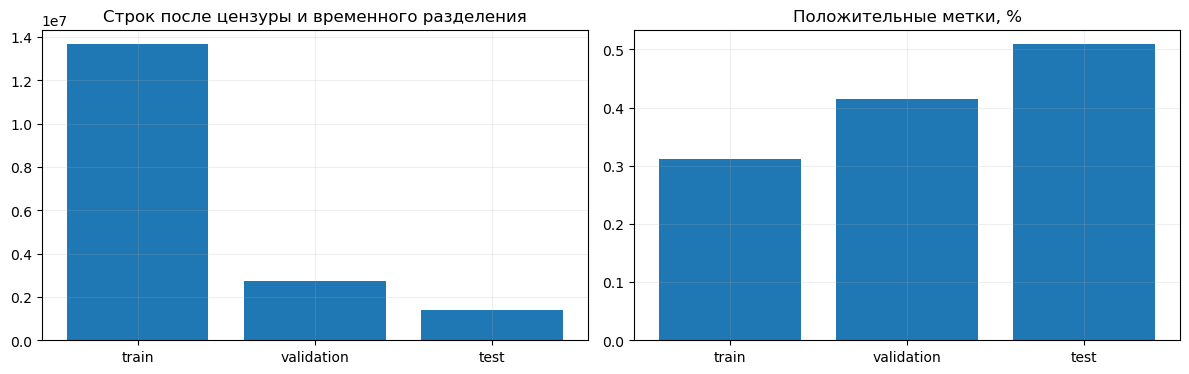

In [66]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
ss=split_summary.to_pandas()
axes[0].bar(ss.split,ss.rows)
axes[0].set_title('Строк после цензуры и временного разделения')
axes[1].bar(ss.split,100*ss.prevalence)
axes[1].set_title('Положительные метки, %')
fig.tight_layout()
fig.savefig(OUT/'figures'/'ml_splits.png',dpi=140)
plt.show()

In [67]:
hypotheses=[]
for f in ['fault_messages_30d','undefined_messages_7d','power_messages_7d','alarms_7d']:
    hypotheses.append(sql(f"""SELECT '{f}' AS feature,CASE WHEN {f}>0 THEN 'были' ELSE 'не было' END AS history_group,
      count(*) AS rows,count(DISTINCT channel_id) AS channels,sum({main_target}) AS positives,
      avg({main_target}) AS target_rate FROM read_parquet({qpath(train_path)}) GROUP BY history_group"""))
show(save_table(pl.concat(hypotheses),'train_hypotheses'),20)
concentration=sql(f"""SELECT channel_id,count(*) AS examples,sum({main_target}) AS positives
    FROM read_parquet({qpath(train_path)}) GROUP BY channel_id ORDER BY positives DESC""")
save_table(concentration,'positive_concentration_train')
print('Доля положительных train-строк у 10 каналов:',round(concentration['positives'].head(10).sum()/max(concentration['positives'].sum(),1),4))
ep_closed=episodes.filter(pl.col('duration_hours').is_not_null())

,feature,history_group,rows,channels,positives,target_rate
0,fault_messages_30d,были,859019,3797,30447,0.035444
1,fault_messages_30d,не было,12802911,11467,12098,0.000945
2,undefined_messages_7d,были,3212421,11400,9210,0.002867
3,undefined_messages_7d,не было,10449509,11467,33335,0.003190
4,power_messages_7d,были,1063921,1402,16300,0.015321
5,power_messages_7d,не было,12598009,11464,26245,0.002083
6,alarms_7d,были,751400,7445,16149,0.021492
7,alarms_7d,не было,12910530,11468,26396,0.002045


Доля положительных train-строк у 10 каналов: 0.0425


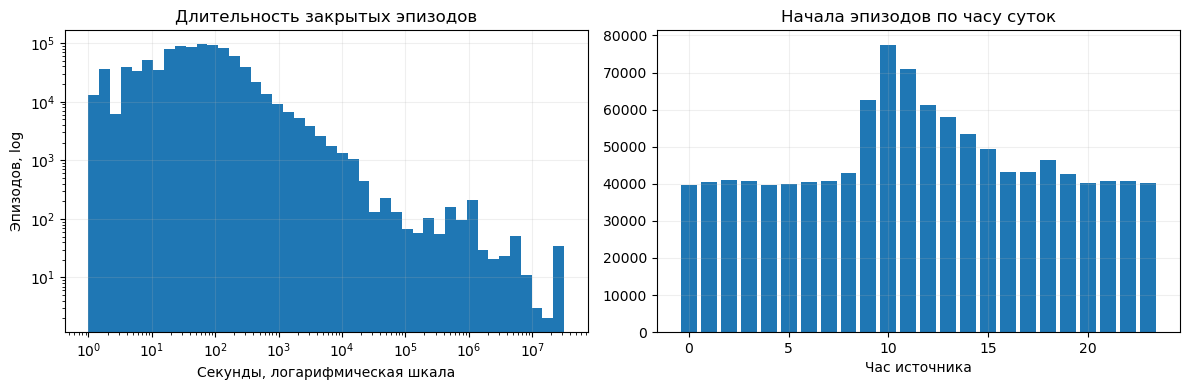

In [68]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
if ep_closed.height:
    durations=np.maximum(ep_closed['duration_hours'].to_numpy()*3600,1)
    axes[0].hist(durations,bins=np.geomspace(1,durations.max()+1,45))
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('Длительность закрытых эпизодов')
axes[0].set_xlabel('Секунды, логарифмическая шкала')
axes[0].set_ylabel('Эпизодов, log')
hour_counts=episodes.filter(pl.col('observed_start')).group_by(pl.col('start_ts').dt.hour().alias('hour')).len().sort('hour')
axes[1].bar(hour_counts['hour'],hour_counts['len'])
axes[1].set_title('Начала эпизодов по часу суток')
axes[1].set_xlabel('Час источника')
fig.tight_layout()
fig.savefig(OUT/'figures'/'episode_patterns.png',dpi=140)
plt.show()

In [69]:
feature_payload={'target':main_target,'features':recommended_features,'all_candidate_features':FEATURES,
 'excluded_constant_or_empty_train':feature_profile.filter(pl.col('constant_or_empty_train'))['feature'].to_list(),
 'categorical_features':[], 'optional_current_metadata_features':['sensor_type_current','system_type_current'],
 'optional_metadata_caveat':'Историчность не подтверждена; сравнивать отдельным ablation на временной validation',
 'prediction_grain':'channel × midnight',
 'feature_window':'[t-w days,t)', 'target_window':'[t+24h,t+48h)',
 'timezone':'source local time, timezone not encoded', 'pipeline_version':PIPELINE_VERSION}
(OUT/'feature_list.json').write_text(json.dumps(feature_payload,ensure_ascii=False,indent=2),encoding='utf-8')
descriptions={
 'events':'Количество зарегистрированных сообщений','alarms':'Сообщения с исходным флагом тревоги',
 'text_n':'Нечисловые сообщения','fault_messages':'Сообщения Неисправен',
 'power_messages':'Сообщения Обесточен','undefined_messages':'Неопределен / Не определено',
 'disabled_messages':'Отключено устройство','smoke_messages':'Обнаружен дым','gas_messages':'Обнаружен газ','flood_messages':'Затоплен',
 'night_events':'Сообщения в 00:00-05:59 по времени источника','unknown_alarm':'Сообщения с неизвестным флагом тревоги',
 'nonfinite_n':'Сообщения с NaN/Inf','numeric_n':'Количество конечных числовых показаний',
 'numeric_mean':'Взвешенное среднее числовых показаний','numeric_std':'Стандартное отклонение, ddof=0',
 'numeric_min':'Минимум числовых показаний','numeric_max':'Максимум числовых показаний'}

In [70]:
extra_desc={'active_days_7d':'Дни с сообщениями за 7 суток','active_days_30d':'Дни с сообщениями за 30 суток',
 'hours_since_last_event':'Часы после последнего известного сообщения','history_days':'Дни от первого известного сообщения, не возраст оборудования',
 'alarm_rate_7d':'alarms_7d / events_7d','event_ratio_1d_7d':'events_1d / (events_7d / 7)',
 'event_ratio_7d_30d':'(events_7d / 7) / (events_30d / 30)','dow':'ISO день недели 1..7','month':'Месяц 1..12',
 'dow_sin':'Циклическое кодирование дня недели, sin','dow_cos':'Циклическое кодирование дня недели, cos',
 'history_complete_days':'Дни с глобальным потоком во всех 24 часах за предыдущие 30 дней',
 'global_complete_days_1d':'Полнота глобального потока предыдущих суток, 0/1',
 'global_complete_days_7d':'Дни с глобальным потоком во всех 24 часах за предыдущие 7 дней'}
feature_dict=[]
schema=pl.scan_parquet(OUT / 'ml_ready' / 'train.parquet').collect_schema()
for f in FEATURES:
    if f in extra_desc: desc=extra_desc[f]
    else:
        stem,window=f.rsplit('_',1); desc=descriptions[stem]+f' за предыдущие {window[:-1]} суток'
    feature_dict.append({'column':f,'role':'feature','dtype':str(schema[f]),'definition':desc,
        'available_at':'prediction_time; события строго раньше t','use_default':f in recommended_features})

In [71]:
other_defs={
 'channel_id':'Строковый идентификатор канала; ключ, не признак',
 'prediction_time':'Момент расчёта, полночь','target_start':'t + 24 часа','target_end':'t + 48 часов, не включается',
 'sensor_type_current':'Тип из текущего справочника, историчность не подтверждена',
 'object_id_current':'Объект из текущего справочника','system_type_current':'Система из текущего справочника',
 'feature_max_ts':'Последнее использованное событие, < t','last_explicit_state':'Последнее Норма/Неисправен/ambiguous до t',
 'last_state_ts':'Время последнего явного изменения до t','history_complete_days':'Число предыдущих дней с глобальным потоком во всех часах',
 'at_risk_with_history':'Норма до t, возраст наблюдения >=30 дней и полные предыдущие сутки',
 'channel_followup_48h':'Будущая наблюдаемость канала; запрещено в X',
 'global_complete_24_48h':'Поток во всех часах целевых суток; запрещено в X',
 'first_seen':'Первое сообщение канала','last_seen':'Последнее сообщение во всей выгрузке; запрещено в X',
 main_target:'Новый эпизод Неисправен в [t+24h,t+48h); null = цензура',
 'target_fault_0_24h':'Новый эпизод в [t,t+24h); вспомогательная метка, запрещено в X'}
for f in export_cols:
    if f not in FEATURES:
        feature_dict.append({'column':f,'role':'label' if f.startswith('target_fault') else 'metadata_or_diagnostic','dtype':str(schema[f]),'definition':other_defs[f],
        'available_at':'не входит в X; возможна информация будущего','use_default':False})
pl.DataFrame(feature_dict).write_csv(OUT/'feature_dictionary.csv')

In [72]:
decisions=[
 ('scope','Все годы; sample не добавляется','sample отдельной даты не смешиваем с непрерывной историей'),
 ('2025 repair','При несовпадении CSV/Parquet восстанавливаем canonical_2025 из CSV','Исходный Parquet неполон; внутренний заголовок уходит в bad_ts'),
 ('IDs','ID строкой; не дедуплицировать по event_id','Обнаружено повторное использование ID'),
 ('duplicates','Только точные копии 6 исходных полей','Повторы состояния во времени сохраняются'),
 ('states','Справочник только для аудита','Нет ключа набора состояний у канала; есть противоречия'),
 ('target','Неисправен после Норма, proxy','Нет реестра подтверждённых отказов и ремонтов'),
 ('lead','Основной горизонт [24h,48h)','Минимум сутки предупреждения'),
 ('recovery','Только Норма','Тишина не означает восстановление'),
 ('negative','Нужны полнота глобального горизонта и future followup канала','Отсутствие события не всегда наблюдаемый ноль'),
 ('eligibility','Известная Норма, 30 дней истории, полные последние сутки','Разрывы прошлых окон передаются признаками полноты, не скрываются'),
 ('missing','Ноль только для счётчиков; числовые null остаются','Imputer учится на train'),
 ('outliers','Не обрезаем по глобальному IQR','Нет единиц; экстремумы могут быть сигналом'),
 ('metadata','Современный справочник исключён из базовых X','Неизвестна историческая принадлежность'),
 ('split','Временной, purge 48h у границ','Исключение утечки target через split'),
 ('scale','Не выполняется в data-layer','Scalers/encoders обучаются внутри ML pipeline только на train')]
pl.DataFrame(decisions,schema=['topic','decision','reason'],orient='row').write_csv(OUT/'decision_log.csv')
requirements={m:__import__(m).__version__ for m in ['polars','pyarrow','duckdb','numpy','pandas','matplotlib']}
(OUT/'requirements.txt').write_text('\n'.join(f'{m}=={v}' for m,v in requirements.items())+'\nipython\n',encoding='utf-8')

99

Посмотрим, какие типы дают положительные примеры. Это помогает понять, что именно будет учить модель.

In [73]:
eda_by_type = report('target_by_type_and_split')
eda_train_types = eda_by_type.loc[eda_by_type['split'].eq('train')].copy()
eda_train_types['positive_share_percent'] = 100 * eda_train_types['positives'] / eda_train_types['positives'].sum()
eda_train_types.sort_values('positives', ascending=False)[['sensor_type_current', 'rows', 'positives', 'positive_share_percent']].head(10)

,sensor_type_current,rows,positives,positive_share_percent
9,Состояние насоса,264269,14217,33.416383
8,Состояние вентилятора,532373,13652,32.088377
13,Датчик дыма,3460417,6005,14.114467
16,Состояние фазы,1230911,5714,13.430485
5,NaN,809528,1768,4.155600
4,Газовый датчик,636247,493,1.158773
11,ИБП,95881,256,0.601716
15,Датчик движения,1201527,126,0.296157
3,КД АВ,544812,101,0.237396
0,КД Дверь,1306825,90,0.211541


In [74]:
eda_pump_fan = eda_train_types['sensor_type_current'].isin(['Состояние насоса', 'Состояние вентилятора'])
eda_share = eda_train_types.loc[eda_pump_fan, 'positives'].sum() / eda_train_types['positives'].sum()
print(f'Насосы и вентиляторы дают {eda_share:.1%} положительных train-строк.')

Насосы и вентиляторы дают 65.5% положительных train-строк.


**либо честно оставляем общий прогноз сигнала неисправности оборудования,
либо выбираем конкретные типы и проверяем для них смысл «Неисправен». Текущий общий датасет не доказывает решение узкой задачи отказа самого датчика**

### Как выглядит готовая строка для модели?
Загружаем только нужные колонки компактного train. Он содержит все positives и 5% negatives.
Частоту классов всего train по нему без весов считать нельзя.

In [75]:
eda_spec = json.loads((OUT / 'feature_list.json').read_text(encoding='utf-8'))
eda_target = eda_spec['target']
eda_features = eda_spec['features']
eda_plot_features = ['events_1d', 'events_7d', 'alarms_7d', 'fault_messages_30d',
                 'undefined_messages_7d', 'hours_since_last_event']
eda_columns = ['channel_id', 'prediction_time', 'sensor_type_current', eda_target, 'sample_weight'] + eda_plot_features
eda_compact = pd.read_parquet(OUT / 'ml_ready/train_compact.parquet', columns=eda_columns)
eda_compact.head(10)

,channel_id,prediction_time,sensor_type_current,target_fault_24_48h,sample_weight,events_1d,events_7d,alarms_7d,fault_messages_30d,undefined_messages_7d,hours_since_last_event
0,50729,2019-10-02,None,0,20.0,4,38,0,0,0,15.303333
1,50729,2019-10-08,None,0,20.0,8,36,0,0,0,12.608333
2,50729,2019-11-07,None,0,20.0,2,10,0,0,1,12.782500
3,50729,2019-12-28,None,0,20.0,6,48,0,0,0,10.530278
4,50810,2019-02-24,None,0,20.0,0,46,0,0,0,38.621389
5,50810,2019-03-18,None,0,20.0,0,120,0,0,0,36.574722
6,50810,2019-04-06,None,0,20.0,10,20,0,0,0,12.889722
7,50810,2019-04-12,None,0,20.0,0,104,0,0,0,36.990833
8,50810,2019-04-27,None,0,20.0,8,18,0,0,0,13.191111
9,50810,2019-06-02,None,0,20.0,0,72,0,0,0,34.626944


In [76]:
eda_compact.shape

(724619, 11)

In [77]:
eda_compact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724619 entries, 0 to 724618
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   channel_id              724619 non-null  object        
 1   prediction_time         724619 non-null  datetime64[us]
 2   sensor_type_current     682367 non-null  object        
 3   target_fault_24_48h     724619 non-null  int8          
 4   sample_weight           724619 non-null  object        
 5   events_1d               724619 non-null  int64         
 6   events_7d               724619 non-null  int64         
 7   alarms_7d               724619 non-null  int64         
 8   fault_messages_30d      724619 non-null  int64         
 9   undefined_messages_7d   724619 non-null  int64         
 10  hours_since_last_event  724619 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(5), int8(1), object(3)
memory usage: 56.0+ MB


In [78]:
eda_compact[eda_plot_features].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,95%,99%,max
events_1d,724619.0,17.059275,172.360841,0.000000,0.000000,0.000000,0.000000,12.000000,437.820000,23100.000000
events_7d,724619.0,119.479422,1138.227447,0.000000,0.000000,2.000000,9.000000,118.000000,2861.820000,145029.000000
alarms_7d,724619.0,4.185110,95.466117,0.000000,0.000000,0.000000,0.000000,2.000000,12.000000,3282.000000
fault_messages_30d,724619.0,14.237900,357.808819,0.000000,0.000000,0.000000,0.000000,3.000000,20.000000,11029.000000
undefined_messages_7d,724619.0,3.021738,83.939554,0.000000,0.000000,0.000000,0.000000,3.000000,15.000000,33518.000000
hours_since_last_event,724619.0,184.601195,194.936169,0.000278,27.501389,107.328889,299.057639,610.703944,693.076233,719.918889


**Вывод:** это признаки прошлой активности.
Например, `fault_messages_30d` - сообщения за прошедший месяц; target - новое начало в будущем.
Исторические сообщения неисправности можно использовать, если они действительно произошли до прогноза.

Проследим один реальный положительный пример: строка train → интервал будущего → эпизод из журнала.
Это иллюстрация правила, не случайная оценочная выборка.

In [79]:
eda_positive_example = eda_compact.loc[eda_compact[eda_target].eq(1)].iloc[0]
eda_channel = str(eda_positive_example['channel_id'])
eda_prediction_time = pd.Timestamp(eda_positive_example['prediction_time'])
display(eda_positive_example[['channel_id', 'prediction_time', 'sensor_type_current', eda_target]].to_frame('Значение'))
print('Целевой интервал:', eda_prediction_time + pd.Timedelta(hours=24), '-', eda_prediction_time + pd.Timedelta(hours=48))

,Значение
channel_id,51674
prediction_time,2019-07-03 00:00:00
sensor_type_current,None
target_fault_24_48h,1


Целевой интервал: 2019-07-04 00:00:00 - 2019-07-05 00:00:00


In [80]:
eda_matching_episodes = pd.read_parquet(OUT / 'episodes/fault_episodes.parquet', filters=[
    ('channel_id', '==', eda_channel),
    ('start_ts', '>=', eda_prediction_time + pd.Timedelta(hours=24)),
    ('start_ts', '<', eda_prediction_time + pd.Timedelta(hours=48)),
    ('observed_start', '==', True),
])
assert len(eda_matching_episodes) > 0
eda_matching_episodes[['channel_id', 'start_ts', 'end_ts', 'observed_start', 'duration_hours']].head(10)

,channel_id,start_ts,end_ts,observed_start,duration_hours
0,51674,2019-07-04 09:40:43,2019-07-04 09:41:11,True,0.007778
1,51674,2019-07-04 09:45:59,2019-07-04 09:46:34,True,0.009722
2,51674,2019-07-04 09:52:10,2019-07-04 09:52:47,True,0.010278
3,51674,2019-07-04 09:55:35,2019-07-04 09:57:22,True,0.029722
4,51674,2019-07-04 10:14:35,2019-07-04 10:15:47,True,0.020000
5,51674,2019-07-04 10:16:48,2019-07-04 10:17:27,True,0.010833
6,51674,2019-07-04 10:34:40,2019-07-04 10:35:06,True,0.007222
7,51674,2019-07-04 10:39:42,2019-07-04 10:40:08,True,0.007222
8,51674,2019-07-04 10:42:59,2019-07-04 10:43:25,True,0.007222
9,51674,2019-07-04 10:46:05,2019-07-04 10:46:41,True,0.010000


**Вывод:** единица target получена из будущего зарегистрированного начала. `end_ts` и длительность видны нам при анализе всей истории,
но не добавляются к признакам этого прогноза. Для обучения используются только колонки из `feature_list.json`.

In [81]:
eda_dictionary = pd.read_csv(OUT / 'feature_dictionary.csv')
eda_dictionary.loc[eda_dictionary['column'].isin(eda_plot_features), ['column', 'definition', 'dtype']]

,column,definition,dtype
0,events_1d,Количество зарегистрированных сообщений за предыдущие 1 суток,Int64
13,events_7d,Количество зарегистрированных сообщений за предыдущие 7 суток,Int64
14,alarms_7d,Сообщения с исходным флагом тревоги за предыдущие 7 суток,Int64
18,undefined_messages_7d,Неопределен / Не определено за предыдущие 7 суток,Int64
29,fault_messages_30d,Сообщения Неисправен за предыдущие 30 суток,Int64
56,hours_since_last_event,Часы после последнего известного сообщения,Float64


Теперь проверяем пропуски на **полном train** по сохранённому профилю. Это не оценка по компактной выборке.

In [82]:
eda_profile = report('train_feature_profile')
eda_profile.sort_values('missing_rate', ascending=False)[['feature', 'missing_rate', 'min', 'max', 'constant_or_empty_train']].head(15)

,feature,missing_rate,min,max,constant_or_empty_train
43,numeric_max_1d,0.951447,-127.0,996.000000,False
40,numeric_mean_1d,0.951447,-1638.0,540.000000,False
41,numeric_std_1d,0.951447,0.0,1646.000000,False
42,numeric_min_1d,0.951447,-3276.0,131.000000,False
47,numeric_min_7d,0.913244,-3276.0,995.000000,False
46,numeric_std_7d,0.913244,0.0,1643.500000,False
48,numeric_max_7d,0.913244,-127.0,996.000000,False
45,numeric_mean_7d,0.913244,-1624.0,995.000000,False
51,numeric_std_30d,0.881844,0.0,1604.905679,False
52,numeric_min_30d,0.881844,-3276.0,995.000000,False


**Решение:** отсутствие числовых измерений оставляем NaN; отсутствие зарегистрированных сообщений в счётчике - ноль,
с учётом отдельных признаков полноты потока. Числовой imputer и scaler обучаются только на train внутри модели.
Константные/пустые на train признаки исключены из рекомендуемого списка. Ни target, ни `last_seen` не должны попасть в X.

## 13. Распределения и зависимости признаков

### Гистограммы, ящики с усами, зависимости

Для графиков берём воспроизводимую **равномерную выборку строк полного train** (до 120 тысяч).
Так не переносим искусственное соотношение классов компактного train в описание общей формы распределений.
При фиксированном составе файла и версии DuckDB seed воспроизводит выборку. Все решения о порогах по этим графикам ещё нужно проверять.

In [83]:
eda_selection = ', '.join(eda_plot_features + [eda_target])
eda_plot_sample = read_small(
    f'SELECT {eda_selection} FROM read_parquet(?) USING SAMPLE reservoir(120000 ROWS) REPEATABLE(42)',
    OUT / 'ml_ready/train.parquet',
)
eda_plot_sample.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(120000, 7)

Гистограммы в исходном масштабе. Если почти всё собрано слева, не заключаем, что данных нет: возможно, несколько больших значений растянули ось.

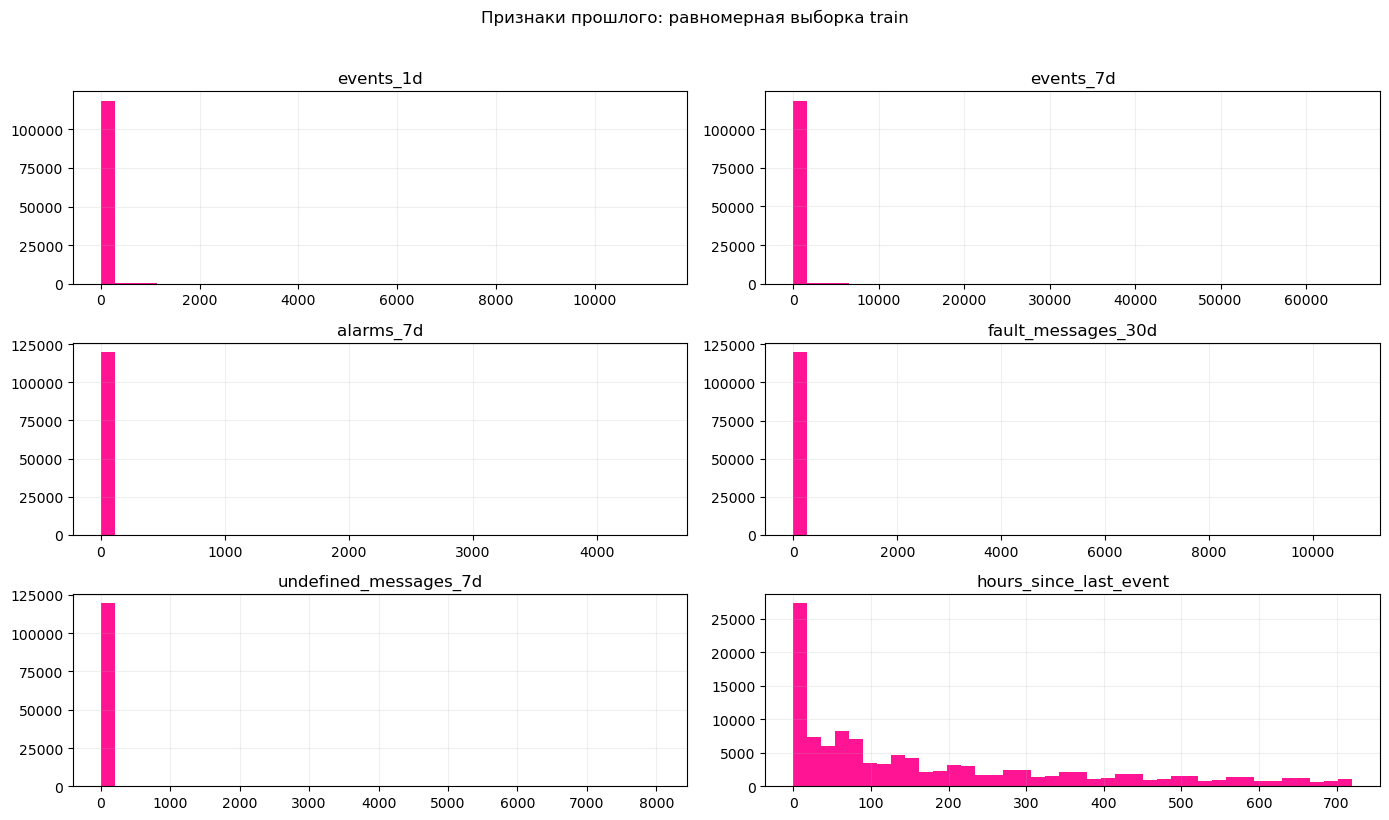

In [84]:
eda_plot_sample[eda_plot_features].hist(figsize=(14, 8), bins=40, color='deeppink')
plt.suptitle('Признаки прошлого: равномерная выборка train', y=1.02)
plt.tight_layout(); plt.show()

Покажем те же признаки в масштабе `log(1+x)`. Это преобразование только для рисунка - обучающие файлы не изменяются.

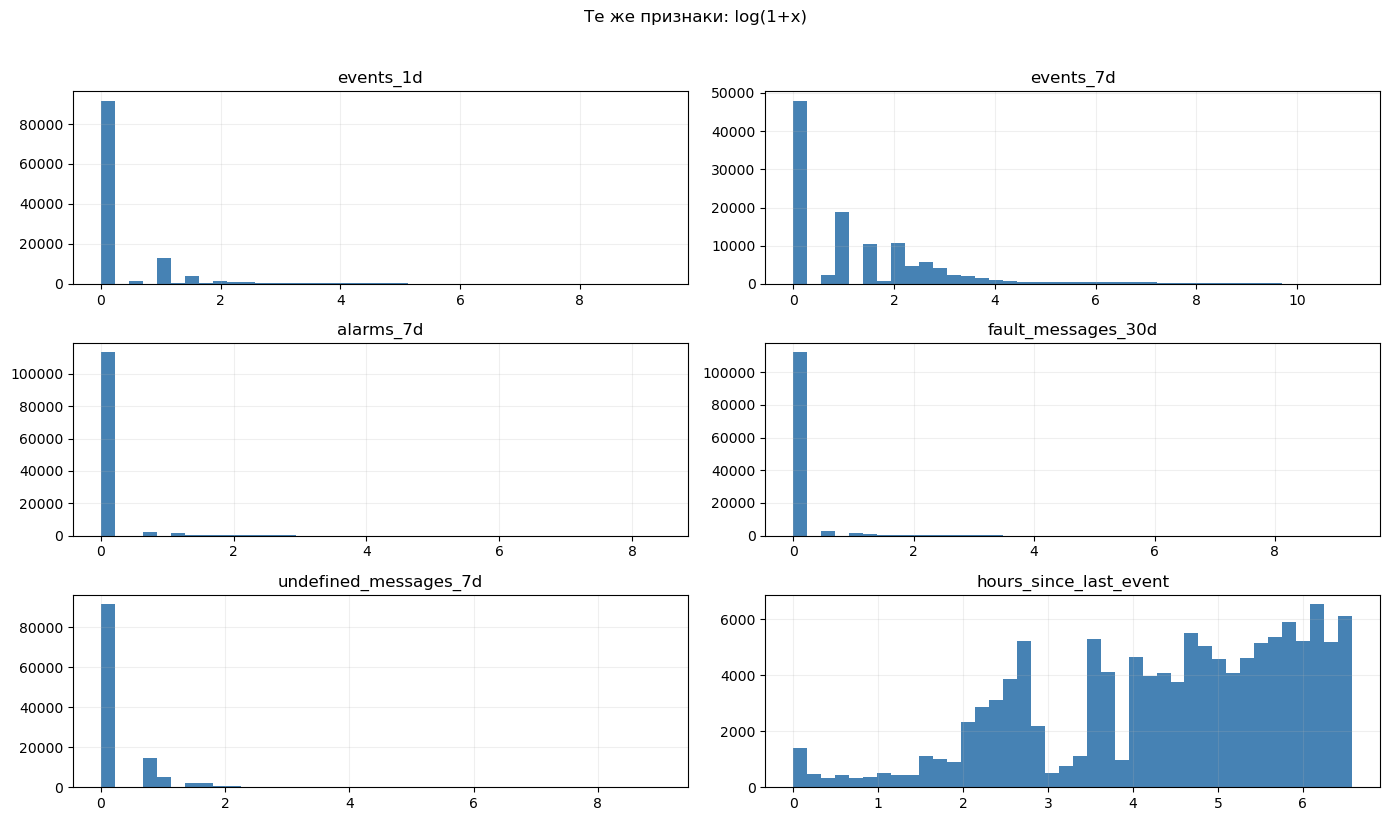

In [85]:
np.log1p(eda_plot_sample[eda_plot_features]).hist(figsize=(14, 8), bins=40, color='steelblue')
plt.suptitle('Те же признаки: log(1+x)', y=1.02)
plt.tight_layout(); plt.show()

Ящики с усами показывают медиану, квартильный диапазон и точки за правилом 1,5 IQR.
Если большинство значений равно нулю, ящик может схлопнуться. Это свойство редких событий, а не ошибка графика.
Каждый признак рисуем отдельно, чтобы большой счётчик не скрывал остальные.

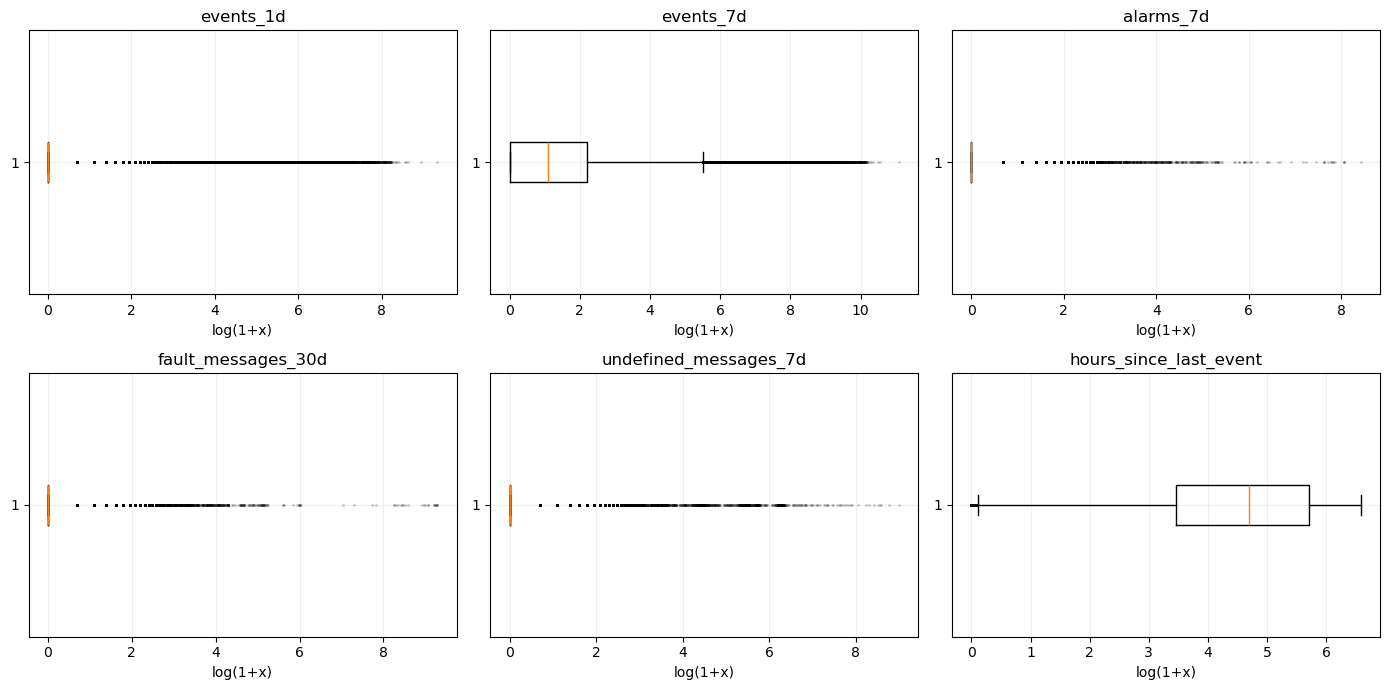

In [86]:
eda_fig, eda_axes = plt.subplots(2, 3, figsize=(14, 7))
for eda_feature, eda_ax in zip(eda_plot_features, eda_axes.flat):
    eda_values = np.log1p(eda_plot_sample[eda_feature].dropna())
    eda_ax.boxplot(eda_values, vert=False, flierprops={'markersize': 1, 'alpha': 0.2})
    eda_ax.set_title(eda_feature)
    eda_ax.set_xlabel('log(1+x)')
plt.tight_layout(); plt.show()

Посчитаем, сколько точек формально выходит за границы IQR в этой выборке. Это кандидаты для изучения, не список для удаления.

In [87]:
eda_quartiles = eda_plot_sample[eda_plot_features].quantile([0.25, 0.75])
eda_iqr = eda_quartiles.loc[0.75] - eda_quartiles.loc[0.25]
eda_lower = eda_quartiles.loc[0.25] - 1.5 * eda_iqr
eda_upper = eda_quartiles.loc[0.75] + 1.5 * eda_iqr
eda_outside = (eda_plot_sample[eda_plot_features] < eda_lower) | (eda_plot_sample[eda_plot_features] > eda_upper)
pd.DataFrame({'Q1': eda_quartiles.loc[0.25], 'Q3': eda_quartiles.loc[0.75], 'IQR': eda_iqr,
              'Вне границ, %': 100 * eda_outside.sum() / eda_plot_sample[eda_plot_features].notna().sum()})

,Q1,Q3,IQR,"Вне границ, %"
events_1d,0.000000,0.000000,0.000000,23.536667
events_7d,0.000000,8.000000,8.000000,11.846667
alarms_7d,0.000000,0.000000,0.000000,5.507500
fault_messages_30d,0.000000,0.000000,0.000000,6.401667
undefined_messages_7d,0.000000,0.000000,0.000000,23.517500
hours_since_last_event,31.075347,301.059931,269.984583,0.766667


**Решение:** автоматического удаления по IQR не делаем. При Q1=Q3=0 любое ненулевое событие окажется «выбросом»;
удаление таких строк уничтожило бы сигнал о тревогах. Следующий шаг - смотреть конкретный канал во времени и проверять значение по предметной области.

Посмотрим конкретные строки с наибольшей прошлой активностью из компактного train. Это реальные примеры, но не гарантированно максимумы полного train.

In [88]:
eda_compact.nlargest(10, 'events_1d')[['channel_id', 'prediction_time', 'sensor_type_current', 'events_1d', 'events_7d', eda_target]]

,channel_id,prediction_time,sensor_type_current,events_1d,events_7d,target_fault_24_48h
471179,267383,2023-02-22,Газовый датчик,23100,145029,0
471177,267383,2023-02-12,Газовый датчик,20946,133626,0
471178,267383,2023-02-16,Газовый датчик,19570,138211,0
471175,267383,2023-02-02,Газовый датчик,19059,133337,0
471176,267383,2023-02-06,Газовый датчик,18893,132814,0
471174,267383,2023-01-16,Газовый датчик,17571,122063,0
471173,267383,2023-01-14,Газовый датчик,17488,120995,0
318969,267383,2022-12-30,Газовый датчик,17045,104072,0
161901,3114,2020-07-29,Состояние УИР-Р,16316,40408,0
317058,196772,2021-03-15,Газовый датчик,16027,47784,1


Сравним распределения при двух значениях target. Для читаемости возьмём до 5 тысяч строк каждого класса.
Эти рисунки показывают условные распределения, не реальную долю положительного класса.

C:\Users\Redmi\AppData\Local\Temp\ipykernel_15640\1207982646.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eda_ax.boxplot([np.log1p(eda_class_samples[eda_k][eda_feature].dropna()) for eda_k in [0, 1]], labels=['target=0', 'target=1'])
C:\Users\Redmi\AppData\Local\Temp\ipykernel_15640\1207982646.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eda_ax.boxplot([np.log1p(eda_class_samples[eda_k][eda_feature].dropna()) for eda_k in [0, 1]], labels=['target=0', 'target=1'])
C:\Users\Redmi\AppData\Local\Temp\ipykernel_15640\1207982646.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eda_ax.boxplot([np.log1p(eda_c

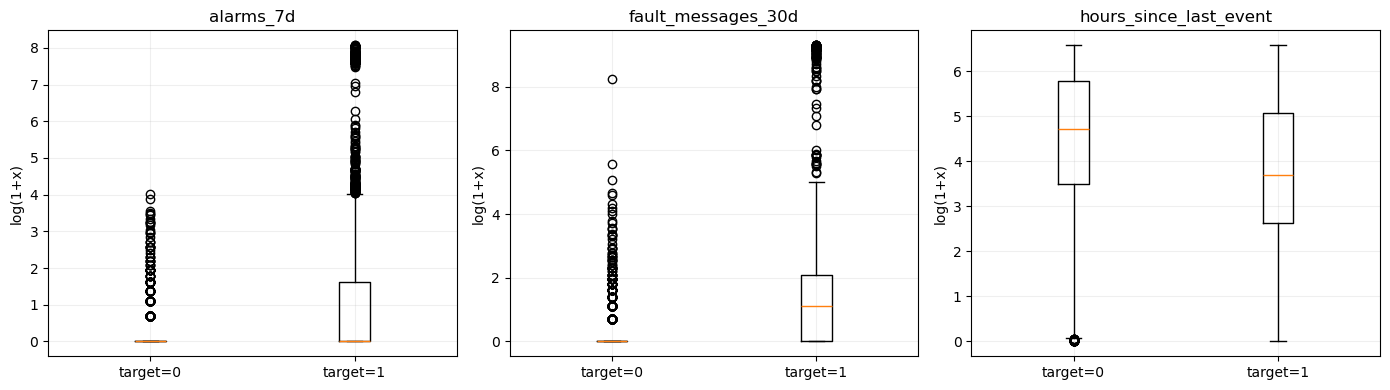

In [89]:
eda_class_samples = {eda_label: eda_compact.loc[eda_compact[eda_target].eq(eda_label)].sample(
    n=min(5000, eda_compact[eda_target].eq(eda_label).sum()), random_state=42
) for eda_label in [0, 1]}
eda_fig, eda_axes = plt.subplots(1, 3, figsize=(14, 4))
for eda_feature, eda_ax in zip(['alarms_7d', 'fault_messages_30d', 'hours_since_last_event'], eda_axes):
    eda_ax.boxplot([np.log1p(eda_class_samples[eda_k][eda_feature].dropna()) for eda_k in [0, 1]], labels=['target=0', 'target=1'])
    eda_ax.set_title(eda_feature); eda_ax.set_ylabel('log(1+x)')
plt.tight_layout(); plt.show()

Подкрепим график численной таблицей по всему train. Это описательная связь: одинаковые каналы и соседние дни зависимы.

In [90]:
eda_hypotheses = report('train_hypotheses')
eda_hypotheses['target_rate_percent'] = eda_hypotheses['target_rate'] * 100
eda_hypotheses[['feature', 'history_group', 'rows', 'channels', 'target_rate_percent']]

,feature,history_group,rows,channels,target_rate_percent
0,fault_messages_30d,были,859019,3797,3.544392
1,fault_messages_30d,не было,12802911,11467,0.094494
2,undefined_messages_7d,были,3212421,11400,0.286700
3,undefined_messages_7d,не было,10449509,11467,0.319010
4,power_messages_7d,были,1063921,1402,1.532069
5,power_messages_7d,не было,12598009,11464,0.208327
6,alarms_7d,были,751400,7445,2.149188
7,alarms_7d,не было,12910530,11468,0.204453


**Вывод:** в текущей разметке прошлые сообщения «Неисправен» связаны с более высокой частотой будущих эпизодов.
Это основание проверить простой baseline на повторяемости, а не доказательство причинности или качества модели.
Для оценки переносимости нужны временная validation, сравнение типов и отдельная проверка влияния 2021 года.

Корреляция Спирмена для выбранных признаков на равномерной train-выборке. Близкие значения могут указывать на дублирующую информацию.

In [91]:
eda_correlation = eda_plot_sample[eda_plot_features].corr(method='spearman')
eda_correlation

,events_1d,events_7d,alarms_7d,fault_messages_30d,undefined_messages_7d,hours_since_last_event
events_1d,1.000000,0.608176,0.073380,0.026265,0.163168,-0.735131
events_7d,0.608176,1.000000,0.209448,0.048488,0.387013,-0.862408
alarms_7d,0.073380,0.209448,1.000000,0.266042,0.045474,-0.154036
fault_messages_30d,0.026265,0.048488,0.266042,1.000000,-0.005917,-0.019317
undefined_messages_7d,0.163168,0.387013,0.045474,-0.005917,1.000000,-0.369449
hours_since_last_event,-0.735131,-0.862408,-0.154036,-0.019317,-0.369449,1.000000


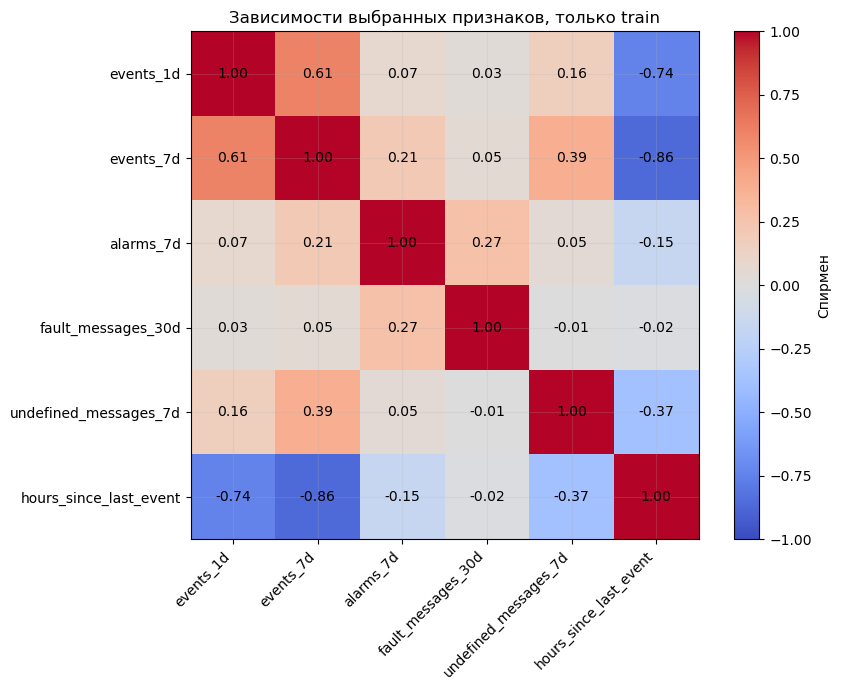

In [92]:
eda_fig, eda_ax = plt.subplots(figsize=(9, 7))
eda_image = eda_ax.imshow(eda_correlation, vmin=-1, vmax=1, cmap='coolwarm')
eda_ax.set_xticks(range(len(eda_plot_features)), eda_plot_features, rotation=45, ha='right')
eda_ax.set_yticks(range(len(eda_plot_features)), eda_plot_features)
for eda_i in range(len(eda_plot_features)):
    for eda_j in range(len(eda_plot_features)):
        eda_ax.text(eda_j, eda_i, f'{eda_correlation.iloc[eda_i, eda_j]:.2f}', ha='center', va='center')
eda_fig.colorbar(eda_image, ax=eda_ax, label='Спирмен')
eda_ax.set_title('Зависимости выбранных признаков, только train')
plt.tight_layout(); plt.show()

**Решение:** сильно связанные признаки не удаляем автоматически. Для линейной модели это может быть важно;
для бустинга полезнее проверить ablation. Ни корреляция, ни boxplot не заменяют честную временную оценку.

## 14. Что передаём ML-команде

Мы подготовили воспроизводимые таблицы и рабочую разметку для первых моделей.

Для baseline сравниваем простое правило по прошлым неисправностям и модель на исторических признаках.
Из-за редкого класса смотрим PR-AUC, precision/recall и число ложных предупреждений, а не одну accuracy.
Дополнительно оцениваем результат по типам оборудования, годам и объектам; проверяем влияние 2021 года и повторных коротких эпизодов.
Числовые каналы имеют разные единицы, поэтому полезно отдельно сравнить модель только на счётчиках и модель со всеми рекомендуемыми признаками.

Новые признаки и решения по модели выбираем на train/validation. После просмотра ошибок test и изменения модели он перестаёт быть независимой финальной оценкой.

Пример загрузки данных для модели. В память читаем компактный train, а validation и test команда может читать пакетами. Код не обучает модель.

In [98]:
# spec = json.loads((OUT/'feature_list.json').read_text(encoding='utf-8'))
# training = pd.read_parquet(OUT/'ml_ready/train_compact.parquet', columns=spec['features'] + [spec['target'], 'sample_weight'])
# X_train = training[spec['features']]
# y_train = training[spec['target']]
# sample_weight = training['sample_weight']
# assert set(X_train.columns) == set(spec['features'])
# print('X:', X_train.shape, 'y:', y_train.shape)
# del training, X_train, y_train, sample_weight
# gc.collect()

## 15. Отдельный ML-сценарий: раннее предупреждение нового дымового сигнала

Прогнозирует новый зарегистрированный эпизод «Обнаружен дым» через 24–48 часов. Это proxy сигнала, а не подтверждённого пожара: в переданных данных нет исходов выездов, реестра пожаров и журнала АРМ-Контроль.

Ячейки ниже используют результаты предыдущих разделов (`episodes/hazard_events_YYYY.parquet`, `ml/panel_YYYY.parquet`) и запускаются после полного EDA. Нули размечаются только при полном наблюдении целевого дня и follow-up канала; train < 2025, validation = 2025, test >= 2026. Порог выбирается только на validation по F2.

In [18]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
)

FIRE_DIR = OUT / 'fire_ml'
FIRE_MODEL_DIR = FIRE_DIR / 'models'
for directory in [FIRE_DIR / 'episodes', FIRE_DIR / 'ml', FIRE_DIR / 'audit', FIRE_MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
(FIRE_DIR / 'requirements_fire_model.txt').write_text('catboost\nscikit-learn\n', encoding='utf-8')

FIRE_TARGET = 'smoke_signal_24_48h'
FIRE_EPISODE_GAP_MINUTES = 10
FIRE_FEATURES = list(FEATURES)
FIRE_METADATA = ['channel_id', 'prediction_time', 'target_start', 'target_end',
                 'sensor_type_current', 'object_id_current', 'system_type_current']
FIRE_DIAGNOSTICS = ['feature_max_ts', 'last_explicit_state', 'last_state_ts',
                    'at_risk_with_history', 'channel_followup_48h',
                    'global_complete_24_48h', 'first_seen', 'last_seen']

hazard_paths = [OUT / 'episodes' / f'hazard_events_{year}.parquet' for year in YEARS]
base_panel_paths = [OUT / 'ml' / f'panel_{year}.parquet' for year in YEARS]
missing_fire_inputs = [path for path in hazard_paths + base_panel_paths if not path.exists()]
if missing_fire_inputs:
    raise FileNotFoundError(
        'Сначала выполните предыдущие разделы EDA. Нет артефактов: '
        + ', '.join(str(path) for path in missing_fire_inputs[:8])
    )

fire_con = duckdb.connect()
fire_con.execute("SET memory_limit='2GB'")
fire_con.execute('SET threads=4')
fire_con.execute(f'SET temp_directory={qpath(OUT / "tmp")}')
hazard_glob = '[' + ','.join(qpath(path) for path in hazard_paths) + ']'
panel_glob = '[' + ','.join(qpath(path) for path in base_panel_paths) + ']'
fire_con.execute(f"""
CREATE OR REPLACE VIEW fire_hazards AS
SELECT channel_id, ts, state FROM read_parquet({hazard_glob})
WHERE state IN ('обнаружен дым', 'обнаружен газ')
""")

smoke_episode_query = f"""
WITH smoke AS (
    SELECT channel_id, ts FROM fire_hazards WHERE state='обнаружен дым'
), ordered AS (
    SELECT channel_id, ts,
        lag(ts) OVER (PARTITION BY channel_id ORDER BY ts) AS previous_ts
    FROM smoke
), marked AS (
    SELECT channel_id, ts,
        CASE WHEN previous_ts IS NULL
               OR CAST(ts AS DATE) <> CAST(previous_ts AS DATE)
               OR ts-previous_ts > INTERVAL {FIRE_EPISODE_GAP_MINUTES} MINUTE
             THEN 1 ELSE 0 END AS starts_episode
    FROM ordered
), grouped AS (
    SELECT channel_id, ts,
        sum(starts_episode) OVER (
            PARTITION BY channel_id ORDER BY ts ROWS UNBOUNDED PRECEDING
        ) AS episode_id
    FROM marked
)
SELECT channel_id, episode_id, min(ts) AS start_ts, max(ts) AS end_ts,
       count(*) AS messages, epoch(max(ts)-min(ts))/60.0 AS duration_minutes
FROM grouped GROUP BY channel_id, episode_id
"""
smoke_episode_path = FIRE_DIR / 'episodes' / 'smoke_episodes.parquet'
fire_con.execute(
    f"COPY ({smoke_episode_query}) TO {qpath(smoke_episode_path)} "
    "(FORMAT PARQUET, COMPRESSION ZSTD)"
)
fire_con.execute(f"""
CREATE OR REPLACE VIEW smoke_starts AS
SELECT channel_id, CAST(start_ts AS DATE) AS day, count(*) AS starts
FROM read_parquet({qpath(smoke_episode_path)})
GROUP BY channel_id, CAST(start_ts AS DATE)
""")

fire_panel_path = FIRE_DIR / 'ml' / 'panel.parquet'
fire_panel_query = f"""
SELECT p.*,
       CASE WHEN coalesce(s.starts, 0)>0 THEN 1
            WHEN p.global_complete_24_48h AND p.channel_followup_48h THEN 0
       END::TINYINT AS {FIRE_TARGET}
FROM read_parquet({panel_glob}) p
LEFT JOIN smoke_starts s
  ON p.channel_id=s.channel_id
 AND CAST(p.prediction_time + INTERVAL 1 DAY AS DATE)=s.day
"""
fire_con.execute(
    f"COPY ({fire_panel_query}) TO {qpath(fire_panel_path)} "
    "(FORMAT PARQUET, COMPRESSION ZSTD)"
)

fire_export_columns = list(dict.fromkeys(FIRE_METADATA + FIRE_FEATURES + [FIRE_TARGET] + FIRE_DIAGNOSTICS))
fire_split_conditions = {
    'train': f"prediction_time<TIMESTAMP '{VAL_START}' AND target_end<=TIMESTAMP '{VAL_START}'",
    'validation': f"prediction_time>=TIMESTAMP '{VAL_START}' AND prediction_time<TIMESTAMP '{TEST_START}' AND target_end<=TIMESTAMP '{TEST_START}'",
    'test': f"prediction_time>=TIMESTAMP '{TEST_START}'",
}
fire_split_paths = {}
for split_name, time_condition in fire_split_conditions.items():
    split_path = FIRE_DIR / 'ml' / f'{split_name}.parquet'
    fire_split_paths[split_name] = split_path
    fire_con.execute(f"""
    COPY (
        SELECT {','.join(fire_export_columns)} FROM read_parquet({qpath(fire_panel_path)})
        WHERE at_risk_with_history AND {FIRE_TARGET} IS NOT NULL AND ({time_condition})
    ) TO {qpath(split_path)} (FORMAT PARQUET, COMPRESSION ZSTD)
    """)

fire_latest_path = FIRE_DIR / 'ml' / 'scoring_latest.parquet'
fire_con.execute(f"""
COPY (
    SELECT {','.join(FIRE_METADATA + FIRE_FEATURES + FIRE_DIAGNOSTICS)}
    FROM read_parquet({qpath(OUT / 'ml_ready' / 'scoring_latest.parquet')})
    WHERE at_risk_with_history
) TO {qpath(fire_latest_path)} (FORMAT PARQUET, COMPRESSION ZSTD)
""")

FIRE_NEGATIVE_RATE = 0.05
fire_train_compact_path = FIRE_DIR / 'ml' / 'train_compact.parquet'
fire_con.execute(f"""
COPY (
    SELECT *,
        CASE WHEN {FIRE_TARGET}=1 THEN 1.0 ELSE {1.0/FIRE_NEGATIVE_RATE} END::DOUBLE AS sample_weight
    FROM read_parquet({qpath(fire_split_paths['train'])})
    WHERE {FIRE_TARGET}=1 OR hash(channel_id, prediction_time, 2026)%20=0
) TO {qpath(fire_train_compact_path)} (FORMAT PARQUET, COMPRESSION ZSTD)
""")

fire_split_summary = pl.concat([
    pl.from_arrow(fire_con.execute(f"""
        SELECT '{split_name}' AS split, count(*) AS rows,
               count(DISTINCT channel_id) AS channels,
               min(prediction_time) AS min_prediction, max(prediction_time) AS max_prediction,
               sum({FIRE_TARGET}) AS positives, avg({FIRE_TARGET}) AS prevalence
        FROM read_parquet({qpath(split_path)})
    """).to_arrow_table())
    for split_name, split_path in fire_split_paths.items()
])
fire_split_summary.write_csv(FIRE_DIR / 'audit' / 'split_summary.csv')
show(fire_split_summary, 10)

fire_train = pl.read_parquet(fire_train_compact_path)
fire_validation = pl.read_parquet(fire_split_paths['validation'])
fire_test = pl.read_parquet(fire_split_paths['test'])
for split_name, split_data in [('train', fire_train), ('validation', fire_validation), ('test', fire_test)]:
    class_count = split_data[FIRE_TARGET].n_unique()
    if class_count != 2:
        raise ValueError(f'{split_name} has {class_count} target class(es); both are required.')

X_fire_train = fire_train.select(FIRE_FEATURES).to_pandas()
y_fire_train = fire_train[FIRE_TARGET].to_numpy().astype('int8')
w_fire_train = fire_train['sample_weight'].cast(pl.Float64).to_numpy()
X_fire_validation = fire_validation.select(FIRE_FEATURES).to_pandas()
y_fire_validation = fire_validation[FIRE_TARGET].to_numpy().astype('int8')
X_fire_test = fire_test.select(FIRE_FEATURES).to_pandas()
y_fire_test = fire_test[FIRE_TARGET].to_numpy().astype('int8')

fire_model = CatBoostClassifier(
    loss_function='Logloss', eval_metric='PRAUC', iterations=1200,
    depth=7, learning_rate=0.04, l2_leaf_reg=8,
    random_seed=42, thread_count=4, allow_writing_files=False, verbose=100,
)
fire_model.fit(
    X_fire_train, y_fire_train, sample_weight=w_fire_train,
    eval_set=(X_fire_validation, y_fire_validation),
    early_stopping_rounds=100, verbose=100,
)

fire_validation_probability = fire_model.predict_proba(X_fire_validation)[:, 1]
fire_test_probability = fire_model.predict_proba(X_fire_test)[:, 1]
precision_curve, recall_curve, candidate_thresholds = precision_recall_curve(
    y_fire_validation, fire_validation_probability
)
f2_curve = (5 * precision_curve[:-1] * recall_curve[:-1]) / (
    4 * precision_curve[:-1] + recall_curve[:-1] + 1e-12
)
fire_threshold = float(candidate_thresholds[int(np.nanargmax(f2_curve))])


def fire_metrics(split_name, labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    precision_value, recall_value, f2_value, _ = precision_recall_fscore_support(
        labels, predictions, beta=2, average='binary', zero_division=0
    )
    return {
        'split': split_name, 'rows': int(len(labels)), 'positives': int(labels.sum()),
        'prevalence': float(labels.mean()),
        'average_precision': float(average_precision_score(labels, probabilities)),
        'roc_auc': float(roc_auc_score(labels, probabilities)),
        'threshold': threshold, 'precision': float(precision_value),
        'recall': float(recall_value), 'f2': float(f2_value),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
        'alerts_per_1000_rows': float(predictions.mean() * 1000),
    }


fire_metrics_table = pl.DataFrame([
    fire_metrics('validation_2025', y_fire_validation, fire_validation_probability, fire_threshold),
    fire_metrics('test_2026+', y_fire_test, fire_test_probability, fire_threshold),
])
fire_metrics_table.write_csv(FIRE_DIR / 'audit' / 'model_metrics.csv')

fire_model_version = f"smoke_catboost_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
fire_model_path = FIRE_MODEL_DIR / f'{fire_model_version}.cbm'
fire_model.save_model(fire_model_path)
fire_feature_spec = {
    'target': FIRE_TARGET, 'features': FIRE_FEATURES,
    'feature_window': '[t-30d,t); all features come from existing past-only panel',
    'target_window': '[t+24h,t+48h)', 'episode_gap_minutes': FIRE_EPISODE_GAP_MINUTES,
    'train_negative_sampling_rate': FIRE_NEGATIVE_RATE,
    'negative_sample_weight': 1.0 / FIRE_NEGATIVE_RATE,
    'threshold_objective': 'F2 selected on 2025 validation only',
    'threshold': fire_threshold, 'model_version': fire_model_version,
    'target_caveat': 'Registered smoke-signal proxy; not a confirmed fire outcome.',
    'best_iteration': int(fire_model.get_best_iteration()),
}
(FIRE_DIR / 'feature_list.json').write_text(
    json.dumps(fire_feature_spec, ensure_ascii=False, indent=2), encoding='utf-8'
)
(FIRE_MODEL_DIR / f'{fire_model_version}.json').write_text(
    json.dumps({**fire_feature_spec, 'validation_metrics': fire_metrics_table.row(0, named=True),
                'test_metrics': fire_metrics_table.row(1, named=True)},
               ensure_ascii=False, indent=2, default=str), encoding='utf-8'
)

latest_fire = pl.read_parquet(fire_latest_path)
X_latest_fire = latest_fire.select(FIRE_FEATURES).to_pandas()
latest_fire_probability = fire_model.predict_proba(X_latest_fire)[:, 1]
latest_fire_scored = latest_fire.select(FIRE_METADATA + FIRE_DIAGNOSTICS).with_columns(
    pl.Series('risk_probability', latest_fire_probability),
    pl.Series('risk_at_validation_threshold', (latest_fire_probability >= fire_threshold).astype('int8')),
    pl.lit(fire_threshold).alias('decision_threshold'),
    pl.lit(fire_model_version).alias('model_version'),
)
latest_fire_scored.write_parquet(FIRE_DIR / 'ml' / 'scoring_latest_scored.parquet', compression='zstd')
latest_fire_scored.write_csv(FIRE_DIR / 'ml' / 'scoring_latest_scored.csv')
show(fire_metrics_table, 10)
print('Best threshold (validation F2):', fire_threshold)
print('Model:', fire_model_path)
print('Target caveat: smoke-signal proxy, not confirmed-fire prediction.')

,split,rows,channels,min_prediction,max_prediction,positives,prevalence
0,train,13661940,11468,2019-02-01,2024-12-30,38272,0.002801
1,validation,2735091,10564,2025-01-01,2025-12-30,8141,0.002977
2,test,1415514,11400,2026-01-01,2026-06-29,6290,0.004444


0:	learn: 0.0042612	test: 0.0039414	best: 0.0039414 (0)	total: 575ms	remaining: 11m 28s
100:	learn: 0.1529187	test: 0.0162396	best: 0.0176236 (89)	total: 39.9s	remaining: 7m 14s
200:	learn: 0.2624418	test: 0.0189452	best: 0.0203068 (127)	total: 1m 23s	remaining: 6m 54s
300:	learn: 0.3690054	test: 0.0219992	best: 0.0220522 (297)	total: 2m 7s	remaining: 6m 20s
400:	learn: 0.4516606	test: 0.0203814	best: 0.0229858 (342)	total: 2m 51s	remaining: 5m 42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.02298581888
bestIteration = 342

Shrink model to first 343 iterations.


,split,rows,positives,prevalence,average_precision,roc_auc,threshold,precision,recall,f2,tp,fp,fn,tn,alerts_per_1000_rows
0,validation_2025,2735091,8141,0.002977,0.028576,0.845418,0.016893,0.034911,0.146911,0.089490,1196,33063,6945,2693887,12.525726
1,test_2026+,1415514,6290,0.004444,0.012740,0.796133,0.016893,0.009339,0.028140,0.020063,177,18775,6113,1390449,13.388776


Best threshold (validation F2): 0.01689302798100971
Model: C:\Users\Admin\Desktop\itmo ml\hakaton\data_handoff\fire_ml\models\smoke_catboost_20260928T222421Z.cbm
Target caveat: smoke-signal proxy, not confirmed-fire prediction.


In [21]:
# Freeze validation-selected settings, then refit on all labeled data through 2025.
fire_baseline_metrics_path = FIRE_DIR / 'audit' / 'model_metrics.csv'
fire_baseline_metrics = pl.read_csv(fire_baseline_metrics_path)
fire_baseline_metrics.write_csv(FIRE_DIR / 'audit' / 'model_metrics_baseline.csv')

fire_refit_train_path = FIRE_DIR / 'ml' / 'train_through_2025.parquet'
fire_con.execute(f"""
COPY (
    SELECT * FROM read_parquet({qpath(fire_train_compact_path)})
    UNION ALL
    SELECT *,
        CASE WHEN {FIRE_TARGET}=1 THEN 1.0 ELSE {1.0/FIRE_NEGATIVE_RATE} END::DOUBLE AS sample_weight
    FROM read_parquet({qpath(fire_split_paths['validation'])})
    WHERE {FIRE_TARGET}=1 OR hash(channel_id, prediction_time, 2026)%20=0
) TO {qpath(fire_refit_train_path)} (FORMAT PARQUET, COMPRESSION ZSTD)
""")

fire_refit_train = pl.read_parquet(fire_refit_train_path)
X_fire_refit = fire_refit_train.select(FIRE_FEATURES).to_pandas()
y_fire_refit = fire_refit_train[FIRE_TARGET].to_numpy().astype('int8')
w_fire_refit = fire_refit_train['sample_weight'].cast(pl.Float64).to_numpy()
fire_refit_iteration_count = int(fire_feature_spec['best_iteration']) + 1

fire_refit_model = CatBoostClassifier(
    loss_function='Logloss', eval_metric='PRAUC',
    iterations=fire_refit_iteration_count,
    depth=7, learning_rate=0.04, l2_leaf_reg=8,
    random_seed=42, thread_count=4, allow_writing_files=False, verbose=100,
)
fire_refit_model.fit(X_fire_refit, y_fire_refit, sample_weight=w_fire_refit)
fire_refit_test_probability = fire_refit_model.predict_proba(X_fire_test)[:, 1]

fire_refit_metrics = pl.DataFrame([
    fire_metrics('validation_2025_baseline', y_fire_validation, fire_validation_probability, fire_threshold),
    fire_metrics('test_2026_baseline', y_fire_test, fire_test_probability, fire_threshold),
    fire_metrics('test_2026_refit_through_2025', y_fire_test, fire_refit_test_probability, fire_threshold),
])
fire_refit_metrics.write_csv(FIRE_DIR / 'audit' / 'model_metrics.csv')

fire_model_version = f"smoke_catboost_refit_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
fire_model_path = FIRE_MODEL_DIR / f'{fire_model_version}.cbm'
fire_refit_model.save_model(fire_model_path)
fire_model = fire_refit_model
fire_feature_spec.update({
    'model_version': fire_model_version,
    'training_period': '2019-02 through 2025-12; validation-selected iteration count and threshold frozen before refit',
    'best_iteration': int(fire_refit_iteration_count - 1),
    'refit_rows': int(fire_refit_train.height),
})
(FIRE_DIR / 'feature_list.json').write_text(
    json.dumps(fire_feature_spec, ensure_ascii=False, indent=2), encoding='utf-8'
)
(FIRE_MODEL_DIR / f'{fire_model_version}.json').write_text(
    json.dumps({**fire_feature_spec, 'metrics': fire_refit_metrics.to_dicts()},
               ensure_ascii=False, indent=2, default=str), encoding='utf-8'
)

latest_fire_probability = fire_model.predict_proba(X_latest_fire)[:, 1]
latest_fire_scored = latest_fire.select(FIRE_METADATA + FIRE_DIAGNOSTICS).with_columns(
    pl.Series('risk_probability', latest_fire_probability),
    pl.Series('risk_at_validation_threshold', (latest_fire_probability >= fire_threshold).astype('int8')),
    pl.lit(fire_threshold).alias('decision_threshold'),
    pl.lit(fire_model_version).alias('model_version'),
)
latest_fire_scored.write_parquet(FIRE_DIR / 'ml' / 'scoring_latest_scored.parquet', compression='zstd')
latest_fire_scored.write_csv(FIRE_DIR / 'ml' / 'scoring_latest_scored.csv')

print('Refit training rows:', fire_refit_train.height)
print('Validation-selected iteration count:', fire_refit_iteration_count)
print('Validation-selected threshold:', fire_threshold)
show(fire_refit_metrics, 10)
print('Refit model:', fire_model_path)
print('Test remains a registered smoke-signal proxy, not confirmed-fire prediction.')

0:	learn: 0.0870761	total: 169ms	remaining: 57.7s
100:	learn: 0.1396387	total: 22.5s	remaining: 53.9s
200:	learn: 0.2248978	total: 46.9s	remaining: 33.1s
300:	learn: 0.3232714	total: 1m 11s	remaining: 9.93s
342:	learn: 0.3586334	total: 1m 21s	remaining: 0us
Refit training rows: 864843
Validation-selected iteration count: 343
Validation-selected threshold: 0.01689302798100971


,split,rows,positives,prevalence,average_precision,roc_auc,threshold,precision,recall,f2,tp,fp,fn,tn,alerts_per_1000_rows
0,validation_2025_baseline,2735091,8141,0.002977,0.028576,0.845418,0.016893,0.034911,0.146911,0.089490,1196,33063,6945,2693887,12.525726
1,test_2026_baseline,1415514,6290,0.004444,0.012740,0.796133,0.016893,0.009339,0.028140,0.020063,177,18775,6113,1390449,13.388776
2,test_2026_refit_through_2025,1415514,6290,0.004444,0.013642,0.809364,0.016893,0.010796,0.029253,0.021799,184,16859,6106,1392365,12.040149


Refit model: C:\Users\Admin\Desktop\itmo ml\hakaton\data_handoff\fire_ml\models\smoke_catboost_refit_20260928T223645Z.cbm
Test remains a registered smoke-signal proxy, not confirmed-fire prediction.
